# Robustness and Temporal Stability of 6D Head Pose Estimation under Fisheye Distortion

**Authors:** Hugo García Souto and Adrián Martínez Balea  
**Course:** Computer Vision II — Master's Degree in Artificial Intelligence, Universidade de Santiago de Compostela

This project studies video-based head pose estimation within the context of gaze and pose-based interaction. The goal is to estimate the 3D orientation of the head, represented by **yaw**, **roll** and **pitch**, on video sequences affected by strong fisheye distortion.

We use **BIWI-360**, the fisheye-distorted version of the BIWI head pose benchmark included in HPE-360. This dataset is challenging because the ground-truth head pose remains the original one, but the face appearance is geometrically warped according to the fisheye location parameters `rho` and `theta`. Therefore, the model may confuse image distortion with actual head rotation.

Our main research question is:

**Can a frame-by-frame 6D head pose estimator remain accurate and temporally stable on BIWI-360 video sequences, and can temporal post-processing or fisheye-aware adaptation reduce the errors caused by fisheye distortion?**

To answer this question, the notebook follows a complete experimental pipeline. First, we load and explore BIWI-360, analyze the pose distribution, and study frame-to-frame changes in both head pose and fisheye distortion. Then, we evaluate **6DRepNet360** in a zero-shot setting, applying the pretrained model frame by frame without training it on BIWI-360. We measure both frame-level accuracy using MAE, RMSE and geodesic error, and temporal stability using prediction jitter and temporal motion error.

The initial zero-shot results show that 6DRepNet360 does not generalize well to BIWI-360: the test mean MAE is around **22.6°**, with very high temporal jitter. Temporal smoothing with EMA reduces jitter substantially and improves the balanced Euler MAE, but it does not fully solve the underlying geometric problem. Additional sanity checks on non-fisheye AFLW2000-3D confirm that the inference pipeline and angle convention are correct, suggesting that the main failure source is the fisheye domain shift.

The notebook then performs a failure analysis using visual examples, error outliers, `rho`-based sensitivity analysis, simple baselines and robust temporal filters. These experiments show that the error increases with stronger radial fisheye distortion, that many failures are caused by extreme roll and pitch outliers, and that the model still provides useful information mainly for yaw.

Finally, we test a fisheye-aware fine-tuning strategy using 300W-LP-360. This adaptation uses fisheye-distorted training images and includes the location metadata `rho` and `theta` as additional information. This produces the strongest improvement, reducing the BIWI-360 test mean MAE to roughly **8°**, far below the zero-shot and post-processing-only results.

Overall, the project shows that temporal post-processing can reduce unstable predictions, but the main issue is not only temporal jitter. The core problem is a strong fisheye-induced domain shift. The most effective direction is therefore not just smoothing the predictions, but adapting the model to the fisheye domain and explicitly using the distortion metadata available in HPE-360.

## Declaration of AI assistance

In line with the course's academic-integrity policy, we declare the use of AI assistants, including ChatGPT and Claude, during the development of this project. They were used to support code refactoring and debugging, to help implement and review auxiliary components such as the geodesic SO(3) metric, temporal filtering utilities and the location-guided fine-tuning pipeline, and to assist with the drafting and wording of explanatory text in the notebook.

The research problem, architecture selection, experimental design, interpretation of the results, failure analysis and final conclusions were reviewed and validated by the authors and reflect our own reasoning.

In [ ]:
import sys
import platform

from pathlib import Path

# The utils dataset is attached to the notebook.
# In Adrián's saved execution it was mounted under adrianmbalea.
# In the current shared notebook it may be mounted under hugogarcasouto.
UTILS_DIR = "/kaggle/input/datasets/hugogarcasouto/cvii-utils-py"

if not (Path(UTILS_DIR) / "cvii_utils.py").exists():
    UTILS_DIR = "/kaggle/input/datasets/adrianmbalea/cvii-utils-py"

if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

import cvii_utils

print("utils imported from:", cvii_utils.__file__)

from cvii_utils import (
    add_frame_errors_for_prefix,
    add_geodesic_frame_error,
    add_geodesic_temporal_columns,
    add_temporal_deltas,
    align_angle_series_to_reference,
    angular_diff_array_deg,
    angular_error_deg,
    apply_axis_specific_filter,
    apply_single_axis_filter,
    apply_temporal_filter_by_sequence,
    assign_level,
    attach_pair_outlier_flags,
    axis_config_name,
    axis_mae_table,
    build_candidate_prediction_df,
    check_url_available,
    circular_angle_diff_deg,
    circular_mean_deg,
    compare_temporal_by_group,
    compute_smoothed_frame_errors,
    compute_temporal_metrics_for_prediction_columns,
    compute_temporal_metrics_for_prefix,
    ema_1d,
    ema_with_jump_clipping_1d,
    evaluate_prediction_columns,
    geodesic_error_deg,
    geodesic_errors_from_euler_deg,
    get_candidate_config_by_name,
    location_features_deg,
    mean_mae_for_signs,
    rolling_mean_1d,
    rolling_median_1d,
    rotation_matrices_from_euler_deg,
    shrink_angles_towards_mean_deg,
    signed_circular_diff_deg,
    smooth_predictions_by_sequence,
    summarize_aflw_subset,
    summarize_candidate,
    summarize_frame_metrics,
    summarize_frame_outlier_subset,
    summarize_raw_vs_smooth_frame,
    summarize_raw_vs_smooth_temporal,
    summarize_smoothed_metrics,
    summarize_temporal_metrics,
    summarize_temporal_outlier_subset,
    unwrap_angle_sequence_deg,
    wrap_angle_deg,
)


utils imported from: /kaggle/input/datasets/adrianmbalea/cvii-utils-py/cvii_utils.py


In [2]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")
DATASETS_ROOT = INPUT_ROOT / "datasets"

HPE360_ROOT = DATASETS_ROOT / "nn1966" / "hpe-360" / "HPE-360" / "HPE-360"
BIWI_ROOT = HPE360_ROOT / "BIWI-360"

print("Available Kaggle inputs:")
for p in sorted(INPUT_ROOT.iterdir()):
    print(" -", p)

print("\nExpected HPE-360 root:", HPE360_ROOT)
print("HPE-360 root exists:", HPE360_ROOT.exists())

print("\nExpected BIWI-360 root:", BIWI_ROOT)
print("BIWI-360 root exists:", BIWI_ROOT.exists())

if not BIWI_ROOT.exists():
    raise FileNotFoundError("BIWI-360 was not found at the expected path. Please check the Kaggle input structure.")


Available Kaggle inputs:
 - /kaggle/input/datasets

Expected HPE-360 root: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360
HPE-360 root exists: True

Expected BIWI-360 root: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/BIWI-360
BIWI-360 root exists: True


## 1. Dataset inspection

Before running any model, we first inspect the structure of **BIWI-360**, the fisheye-distorted version of the BIWI head pose dataset included in HPE-360. This step verifies that the dataset has the expected video-sequence organization and that every sequence has a corresponding label file.

Each sequence folder contains RGB frames, while each `labelXX_planB.mat` file stores the ground-truth head pose and fisheye metadata for that sequence. The relevant variables for this project are the head pose angles, **yaw**, **roll** and **pitch**, and the fisheye location parameters, **rho** and **theta**.

In this section, we check:

- the number of available sequence folders;
- the number of label files;
- the number of RGB frames per sequence;
- whether the naming convention is consistent across sequences and labels.

This inspection confirms that BIWI-360 contains **24 video sequences** and **24 label files**, with a total of **15,678 RGB frames**. This sequence-based structure is important because later we split validation and test by sequence, not by individual frame, to avoid temporal leakage.

In [3]:
print("BIWI-360 root:", BIWI_ROOT)

sequence_dirs = sorted([p for p in BIWI_ROOT.iterdir() if p.is_dir() and p.name.isdigit()])
label_files = sorted(BIWI_ROOT.glob("label*_planB.mat"))

print(f"\nNumber of sequence folders: {len(sequence_dirs)}")
print(f"Number of label files: {len(label_files)}")

print("\nFrames per sequence:")
for seq_dir in sequence_dirs:
    rgb_frames = sorted(seq_dir.glob("*_rgb.png"))
    print(f"Sequence {seq_dir.name}: {len(rgb_frames)} RGB frames")

print("\nFirst label files:")
for label_file in label_files[:10]:
    print(" -", label_file.name)


BIWI-360 root: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/BIWI-360

Number of sequence folders: 24
Number of label files: 24

Frames per sequence:
Sequence 01: 499 RGB frames
Sequence 02: 511 RGB frames
Sequence 03: 730 RGB frames
Sequence 04: 744 RGB frames
Sequence 05: 946 RGB frames
Sequence 06: 542 RGB frames
Sequence 07: 745 RGB frames
Sequence 08: 772 RGB frames
Sequence 09: 882 RGB frames
Sequence 10: 726 RGB frames
Sequence 11: 572 RGB frames
Sequence 12: 732 RGB frames
Sequence 13: 485 RGB frames
Sequence 14: 797 RGB frames
Sequence 15: 654 RGB frames
Sequence 16: 914 RGB frames
Sequence 17: 395 RGB frames
Sequence 18: 614 RGB frames
Sequence 19: 502 RGB frames
Sequence 20: 556 RGB frames
Sequence 21: 634 RGB frames
Sequence 22: 665 RGB frames
Sequence 23: 569 RGB frames
Sequence 24: 492 RGB frames

First label files:
 - label01_planB.mat
 - label02_planB.mat
 - label03_planB.mat
 - label04_planB.mat
 - label05_planB.mat
 - label06_planB.mat
 - label07_planB.mat
 - 

## 2. Label file inspection

BIWI-360 provides one `.mat` label file per video sequence. Before building the full frame-level dataframe, we inspect one label file to understand its internal structure and verify that the number of labels matches the number of RGB frames in the corresponding sequence.

The inspected file contains a single relevant array, `label_360`, with shape `(499, 7)` for sequence 01. This means that the sequence has 499 annotated frames and that each row contains seven values. In this notebook, these values are used to recover the frame identifier, the ground-truth head pose angles and the fisheye metadata.

The pose annotations are later mapped to **yaw**, **roll** and **pitch**, while the fisheye parameters **rho** and **theta** describe the synthetic location used to generate the fisheye distortion. Inspecting this structure before parsing all sequences helps avoid silent mistakes when matching labels to image files.

In [4]:
import scipy.io as sio

sample_label_file = label_files[0]
mat = sio.loadmat(sample_label_file)

print("Loaded label file:", sample_label_file.name)
print("\nAvailable keys:")

for key, value in mat.items():
    if not key.startswith("__"):
        print(f"{key}: type={type(value)}, shape={getattr(value, 'shape', None)}, dtype={getattr(value, 'dtype', None)}")


Loaded label file: label01_planB.mat

Available keys:
label_360: type=<class 'numpy.ndarray'>, shape=(499, 7), dtype=float64


### 2.1 Inspecting the label values

The first label file contains a single array named `label_360`, with one row per RGB frame. We inspect the first and last rows, the numerical range of each column, and the corresponding RGB filenames to infer the meaning of the seven columns before parsing the full dataset.

From this inspection, the columns can be interpreted as:

| Column | Meaning |
|---|---|
| 0 | Sequence ID |
| 1 | Frame ID |
| 2 | Yaw ground truth |
| 3 | Roll ground truth |
| 4 | Pitch ground truth |
| 5 | `rho`, the normalized radial fisheye position |
| 6 | `theta`, the angular fisheye position in degrees |

For sequence 01, the first label row corresponds to frame ID `3`, matching the first RGB file `frame_00003_rgb.png`. The last label row corresponds to frame ID `501`, matching `frame_00501_rgb.png`. The number of label rows and RGB frames is the same: **499**.

This confirms that the labels can be matched to images using the frame ID stored in column 1. It also confirms that the dataset provides both the original head pose annotations and the fisheye metadata needed for later analysis.

In [5]:
import numpy as np
import pandas as pd

labels = mat["label_360"]

print("Label array shape:", labels.shape)

print("\nFirst 10 rows:")
display(pd.DataFrame(labels[:10]))

print("\nLast 10 rows:")
display(pd.DataFrame(labels[-10:]))

summary = pd.DataFrame({
    "min": labels.min(axis=0),
    "max": labels.max(axis=0),
    "mean": labels.mean(axis=0),
    "std": labels.std(axis=0)
})

print("\nColumn-wise summary:")
display(summary)

seq01_dir = BIWI_ROOT / "01"
seq01_frames = sorted(seq01_dir.glob("*_rgb.png"))

print("\nFirst 10 RGB frame filenames:")
for frame_path in seq01_frames[:10]:
    print(frame_path.name)

print("\nLast 10 RGB frame filenames:")
for frame_path in seq01_frames[-10:]:
    print(frame_path.name)

print("\nNumber of labels:", len(labels))
print("Number of RGB frames:", len(seq01_frames))


Label array shape: (499, 7)

First 10 rows:


,0,1,2,3,4,5,6
0,1.0,3.0,3.290994,-1.566632,7.607223,0.250498,-74.249642
1,1.0,4.0,3.889411,-1.930131,7.650885,0.465149,139.762830
2,1.0,5.0,3.664672,-1.946089,7.445381,0.670615,11.398345
3,1.0,6.0,3.795917,-1.896884,7.455991,0.756483,-98.073602
4,1.0,7.0,3.433040,-2.123386,7.729789,0.255294,101.986555
5,1.0,8.0,4.065578,-2.239335,7.529910,0.434607,-55.281263
6,1.0,9.0,3.619380,-1.837812,7.553633,0.322843,85.592478
7,1.0,10.0,3.785949,-2.175483,7.680194,0.279801,38.692073
8,1.0,11.0,3.594780,-2.192630,7.481102,0.503373,20.933092
9,1.0,12.0,3.791450,-1.956757,7.585290,0.290940,43.844597



Last 10 rows:


,0,1,2,3,4,5,6
0,1.0,492.0,-50.809113,41.742519,-56.415729,0.307111,-164.292400
1,1.0,493.0,-51.674920,40.173139,-55.161984,0.617853,77.969602
2,1.0,494.0,-52.374968,39.304608,-54.305304,0.116012,-30.242918
3,1.0,495.0,-51.567869,42.315288,-56.303669,0.072047,157.130696
4,1.0,496.0,-51.469255,41.025681,-54.961993,0.253545,52.833340
5,1.0,497.0,-51.680464,41.945054,-54.828453,0.410843,163.372422
6,1.0,498.0,-51.819007,41.816200,-56.548215,0.682507,-126.461582
7,1.0,499.0,-52.005886,41.772323,-55.555400,0.002198,-49.182329
8,1.0,500.0,-51.951749,41.825209,-55.759139,0.168659,-23.776903
9,1.0,501.0,-52.375719,41.554203,-54.919936,0.526956,-140.135868



Column-wise summary:


,min,max,mean,std
0,1.000000,1.000000,1.000000,0.000000
1,3.000000,501.000000,252.000000,144.048603
2,-64.346146,59.152489,2.292873,34.587135
3,-39.685246,44.679199,3.442469,17.215347
4,-57.487375,40.418107,-7.782420,30.723731
5,0.002198,0.799191,0.413519,0.222907
6,-178.484923,179.695795,1.381277,104.835364



First 10 RGB frame filenames:
frame_00003_rgb.png
frame_00004_rgb.png
frame_00005_rgb.png
frame_00006_rgb.png
frame_00007_rgb.png
frame_00008_rgb.png
frame_00009_rgb.png
frame_00010_rgb.png
frame_00011_rgb.png
frame_00012_rgb.png

Last 10 RGB frame filenames:
frame_00492_rgb.png
frame_00493_rgb.png
frame_00494_rgb.png
frame_00495_rgb.png
frame_00496_rgb.png
frame_00497_rgb.png
frame_00498_rgb.png
frame_00499_rgb.png
frame_00500_rgb.png
frame_00501_rgb.png

Number of labels: 499
Number of RGB frames: 499


### 2.2 Dataset documentation files

The previous inspection suggests that each label row contains a frame reference, three head pose angles and two fisheye-related metadata values. To avoid relying only on inference from numerical ranges, we inspect the dataset documentation files before assigning the final column names.

The HPE-360 README confirms that the dataset contains fisheye-distorted versions of three common head pose benchmarks: **BIWI**, **300W-LP** and **AFLW2000**. It also explains that the fisheye versions keep the original head pose ground truth, while the face images are synthetically distorted using a common mapping function.

According to the documentation, each annotation row follows this format:

| Field | Meaning |
|---|---|
| Image path | Relative path to the distorted face image |
| `yaw` | Ground-truth yaw angle |
| `roll` | Ground-truth roll angle |
| `pitch` | Ground-truth pitch angle |
| `rho` | Normalized radial position used for fisheye generation |
| `theta` | Angular position used for fisheye generation, in degrees |

The README also specifies that `rho` is sampled in the range **0 to 0.8**, while `theta` is sampled between **-180° and 180°**. This confirms the interpretation from the `.mat` file inspection: columns 2, 3 and 4 correspond to yaw, roll and pitch, and columns 5 and 6 correspond to the fisheye metadata `rho` and `theta`.

This documentation is important for the rest of the notebook because `rho` and `theta` are not target pose angles. They describe how the fisheye distortion was generated. Therefore, they will be used later for sensitivity analysis and for the location-guided fine-tuning experiment, but not as ground-truth head pose values.

In [6]:
readme_files = [
    DATASETS_ROOT / "nn1966" / "hpe-360" / "README.txt",
    HPE360_ROOT / "README.txt",
    BIWI_ROOT / "label_biwi.txt",
]

for path in readme_files:
    print("=" * 100)
    print(path)
    print("=" * 100)
    
    if path.exists():
        text = path.read_text(errors="ignore")
        print(text[:4000])
    else:
        print("File not found.")
    
    print()


/kaggle/input/datasets/nn1966/hpe-360/README.txt
数据集名称 
HPE-360
The fisheye-distorted version of three popular public benchmark datasets.

数据集描述
我们在三个开源且流行的头部姿态估计数据集，BIWI，300W-LP，AFLW2000，上创建了对应的鱼眼失真版本。我们将新的鱼眼失真数据集命名为BIWI-360，300W-LP-360，AFLW2000-360，并将三个鱼眼失真数据集打包命名为HPE-360。我们使用相同的映射函数去执行原始图片到鱼眼失真图像的转换，同时对于鱼眼失真版本的头部姿态仍使用原始的头部姿态groundtruth。

数据来源
（说明数据的来源，包括数据收集的时间、地点和方法。）
由于鱼眼畸变数据集是已有的公开数据集的合成版本，因此只对鱼眼畸变的生成方式进行说明。对于原数据集中的直线图像，首先将人脸区域裁剪出来，然后创建一个五倍于人脸区域高和宽的画布，将人脸区域的中心点随机放置在画布的某个位置P处，P由极坐标rho和theta来表示。rho和theta分别从（0，0.8）以及（-180，180）的均匀分布中采样。接着使用特定的映射函数生成鱼眼畸变效果。最后将畸变后的人脸区域从画布上裁剪出来。

数据集结构
HPE-360
	AFLW2000-360
		image00002.jpg
		....
		label_aflw2000.txt
	BIWI-360
		01
		....
		label_biwi.txt
	300W-LP-360
		AFW
		AFW_Flip
		HELEN
		...
		label_300wlp.txt
	README

数据字段说明
（如果数据集包含表格数据，列出每个字段的名称和含义。）
AFLW2000-360 的标注文件为 label_aflw2000.txt 
BIWI-360 的标注文件为 label_biwi.txt
300W-LP-360 的标注文件为 label_300wlp.txt
txt文件中每行的内容为：图片路径   yaw   roll   pitch   rho   theta(°)
（注：rho为归一化径向位置，其范围为0-0.8）

数据集规模

### 2.3 Building the frame-level annotation table

After inspecting both the `.mat` files and the dataset documentation, we now build a single frame-level annotation table for all BIWI-360 sequences.

Each annotation row contains:

| Field | Meaning |
|---|---|
| `sequence_id` | BIWI-360 video sequence identifier |
| `frame_id` | Frame identifier used to match the RGB filename |
| `image_path` | Full path to the distorted RGB image |
| `yaw` | Ground-truth yaw angle |
| `roll` | Ground-truth roll angle |
| `pitch` | Ground-truth pitch angle |
| `rho` | Normalized radial position used during fisheye generation |
| `theta` | Angular position used during fisheye generation, in degrees |

The pose angles are the original head pose ground truth from BIWI, while `rho` and `theta` describe how the fisheye distortion was generated. We keep these two metadata fields because they are central to the project: they allow us to analyze whether the model fails more often under stronger or different fisheye distortions, and they are later used in the location-guided fine-tuning experiment.

The resulting dataframe will be the main data structure used throughout the notebook for dataset exploration, inference, validation/test splitting, metric computation, failure analysis and fine-tuning evaluation.

## 3. Frame-level dataset construction and sanity check

After identifying the structure of the BIWI-360 annotations, we build the full frame-level dataframe used in the rest of the notebook. Each row corresponds to one RGB frame and contains its sequence ID, frame ID, image path, ground-truth head pose angles and fisheye metadata.

This step also acts as a sanity check before any temporal analysis or model inference. In particular, we verify that:

- the dataframe contains all BIWI-360 frames;
- each image path points to an existing RGB file;
- the number of frames per sequence matches the dataset inspection;
- the pose and fisheye metadata have plausible numerical ranges.

The resulting table contains **15,678 frames** and **8 columns**:

`sequence_id`, `frame_id`, `image_path`, `yaw`, `roll`, `pitch`, `rho`, `theta`.

The check reports **0 missing image files**, confirming that the labels and RGB frames are correctly matched. The summary statistics also show that `rho` lies in the expected range `[0, 0.8]`, while `theta` spans approximately `[-180°, 180°]`, as described in the dataset documentation.

This dataframe is the central data structure for the rest of the project. It will be used for dataset exploration, sequence-based validation/test splitting, zero-shot inference, temporal stability analysis, failure analysis, robust filtering and fine-tuning evaluation.

In [7]:
import scipy.io as sio
import pandas as pd
from pathlib import Path

records = []

for label_file in sorted(BIWI_ROOT.glob("label*_planB.mat")):
    labels = sio.loadmat(label_file)["label_360"]
    
    for row in labels:
        sequence_id = int(row[0])
        frame_id = int(row[1])
        
        image_path = BIWI_ROOT / f"{sequence_id:02d}" / f"frame_{frame_id:05d}_rgb.png"
        
        records.append({
            "sequence_id": sequence_id,
            "frame_id": frame_id,
            "image_path": str(image_path),
            "yaw": float(row[2]),
            "roll": float(row[3]),
            "pitch": float(row[4]),
            "rho": float(row[5]),
            "theta": float(row[6]),
        })

df = pd.DataFrame(records)

print("Frame-level table shape:", df.shape)
print("\nFirst rows:")
display(df.head())

print("\nLast rows:")
display(df.tail())

print("\nNumber of frames per sequence:")
display(df.groupby("sequence_id").size().rename("num_frames").reset_index())

print("\nMissing image files:", (~df["image_path"].apply(lambda p: Path(p).exists())).sum())

print("\nPose and fisheye metadata summary:")
display(df[["yaw", "roll", "pitch", "rho", "theta"]].describe())


Frame-level table shape: (15678, 8)

First rows:


,sequence_id,frame_id,image_path,yaw,roll,pitch,rho,theta
0,1,3,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.290994,-1.566632,7.607223,0.250498,-74.249642
1,1,4,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.889411,-1.930131,7.650885,0.465149,139.762830
2,1,5,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.664672,-1.946089,7.445381,0.670615,11.398345
3,1,6,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.795917,-1.896884,7.455991,0.756483,-98.073602
4,1,7,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.433040,-2.123386,7.729789,0.255294,101.986555



Last rows:


,sequence_id,frame_id,image_path,yaw,roll,pitch,rho,theta
15673,24,618,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,1.649785,-2.091429,27.829273,0.247761,-87.856909
15674,24,619,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,2.348748,-1.574616,27.642538,0.590965,-34.187572
15675,24,620,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,1.891242,-1.413197,26.657115,0.265551,-77.702273
15676,24,621,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,2.681086,-1.915508,25.749074,0.145223,124.581460
15677,24,622,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.647070,-1.810187,23.973104,0.523816,-170.417969



Number of frames per sequence:


,sequence_id,num_frames
0,1,499
1,2,511
2,3,730
3,4,744
4,5,946
5,6,542
6,7,745
7,8,772
8,9,882
9,10,726



Missing image files: 0

Pose and fisheye metadata summary:


,yaw,roll,pitch,rho,theta
count,15678.000000,15678.000000,15678.000000,15678.000000,15678.000000
mean,7.920360,0.065513,9.257203,0.400516,0.301844
std,29.898830,13.294906,25.788349,0.230891,103.915334
min,-74.889528,-64.699638,-63.826999,0.000047,-179.959768
25%,-8.647094,-5.117293,-4.909459,0.198906,-89.080091
50%,6.094983,-0.318907,13.050165,0.399797,0.629272
75%,29.868050,5.943581,24.647709,0.599690,89.579228
max,77.971758,45.018895,84.369888,0.799940,179.977079


We now visualize a small set of evenly spaced frames from one BIWI-360 sequence, together with their ground-truth pose angles and fisheye metadata. This provides a qualitative check that the image paths, frame identifiers and labels are correctly aligned.

The examples show the main challenge of the dataset: although the ground-truth head pose changes smoothly along the original BIWI sequence, the visual appearance of the face is strongly affected by fisheye distortion. Depending on `rho` and `theta`, the face may appear stretched, shifted, partially cropped, or surrounded by black padding introduced during the synthetic fisheye transformation.

This visualization also helps clarify the role of the metadata:

- `yaw`, `roll` and `pitch` are the head pose targets that the model must predict.
- `rho` and `theta` are not pose labels; they describe where the face was placed before applying the fisheye distortion.

This distinction is important for the rest of the notebook. A model trained mostly on normal face images may confuse fisheye-induced deformation with real head rotation, especially when the face is far from the distortion center or visually warped.

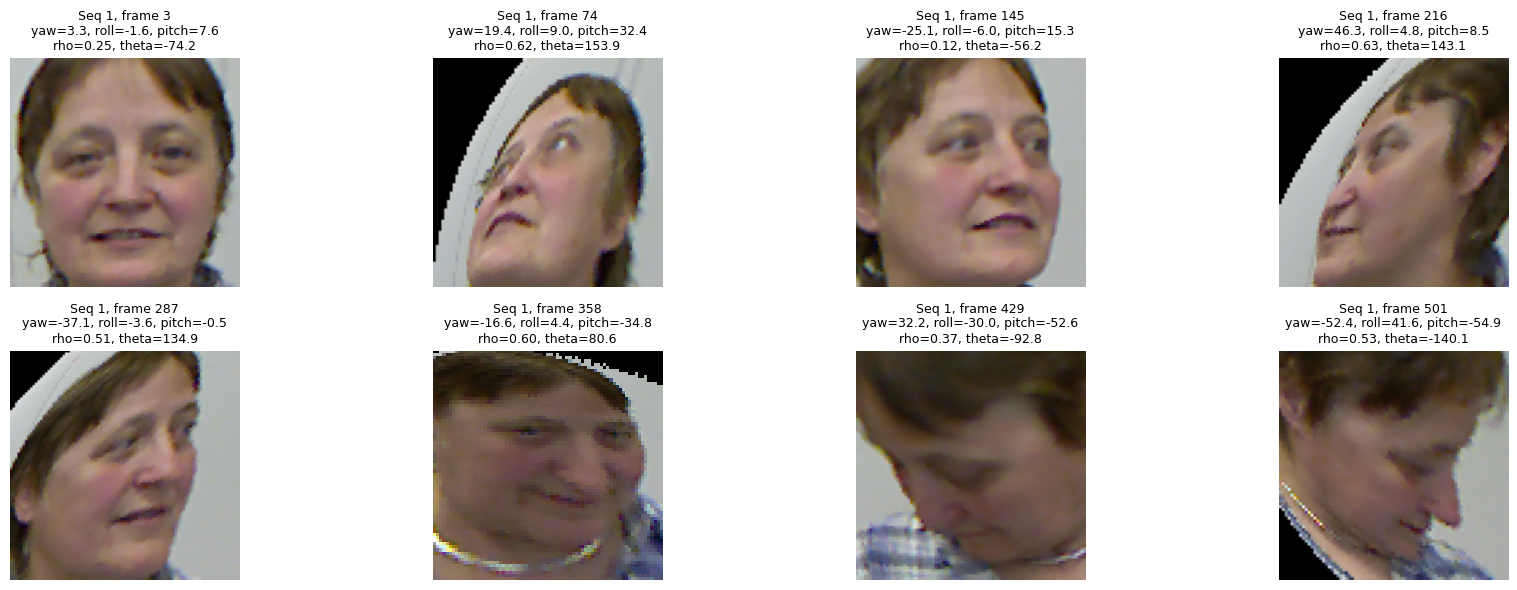

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

sample_sequence_id = 1
sample_df = df[df["sequence_id"] == sample_sequence_id].reset_index(drop=True)

sample_indices = np.linspace(0, len(sample_df) - 1, 8, dtype=int)
sample_rows = sample_df.iloc[sample_indices]

plt.figure(figsize=(18, 6))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Seq {int(row['sequence_id'])}, frame {int(row['frame_id'])}\n"
        f"yaw={row['yaw']:.1f}, roll={row['roll']:.1f}, pitch={row['pitch']:.1f}\n"
        f"rho={row['rho']:.2f}, theta={row['theta']:.1f}",
        fontsize=9
    )

plt.tight_layout()
plt.show()


## 4. Ground-truth temporal dynamics

Since this project works with video sequences, we first analyze how the **ground-truth head pose** evolves over time. This helps us understand the temporal structure of BIWI-360 before evaluating the model predictions.

For each sequence, we compute frame-to-frame changes in **yaw**, **roll** and **pitch**, and combine them into a simple ground-truth motion magnitude. This value estimates how much the real head pose changes from one frame to the next.

The plots for sequence 01 show that the ground-truth pose follows relatively smooth trajectories over time. Yaw, roll and pitch vary continuously, with some faster rotations in specific intervals. The motion magnitude is usually low, although occasional peaks appear when the pose changes more rapidly.

The summary table compares all sequences by their average frame-to-frame motion. Most sequences have a mean motion between roughly **1° and 3.5° per frame**, which indicates that the real head motion is generally much smoother than the prediction jumps observed later in the zero-shot model.

This analysis is important for two reasons:

- It provides a reference for temporal stability: a good video-based estimator should not produce much larger frame-to-frame changes than the ground truth.
- It helps identify fast-motion regions where temporal smoothing may reduce prediction jitter, but can also introduce lag.

At this stage, this is a preliminary temporal diagnostic based on the available frame order. Later temporal evaluation will focus on valid consecutive frame pairs to avoid treating frame gaps as normal temporal transitions.

Sequences sorted by average ground-truth frame-to-frame motion:


,sequence_id,num_frames,mean_abs_d_yaw,mean_abs_d_roll,mean_abs_d_pitch,mean_motion,max_motion
5,6,542,1.604304,1.769256,1.881088,3.525679,89.319183
20,21,634,1.466508,1.832553,1.634285,3.381508,23.939624
17,18,614,1.552501,1.403594,1.482300,3.004947,39.506805
22,23,569,1.509717,1.394925,1.272115,2.834752,49.203724
14,15,654,1.480130,1.502836,1.131363,2.782862,12.895282
18,19,502,1.508842,1.298426,1.083966,2.664223,11.023587
13,14,797,1.524503,1.352240,0.987444,2.616162,9.800047
16,17,395,1.476455,1.186578,1.031588,2.537387,15.323107
15,16,914,1.351605,1.160932,1.205906,2.505490,28.953744
23,24,492,1.499251,0.575445,1.281401,2.421893,21.873022


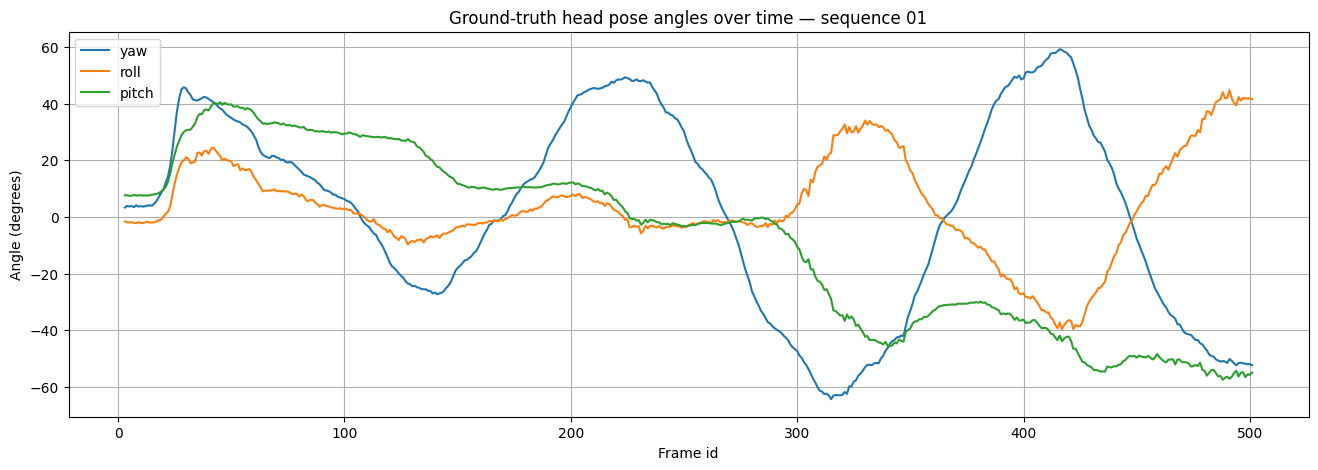

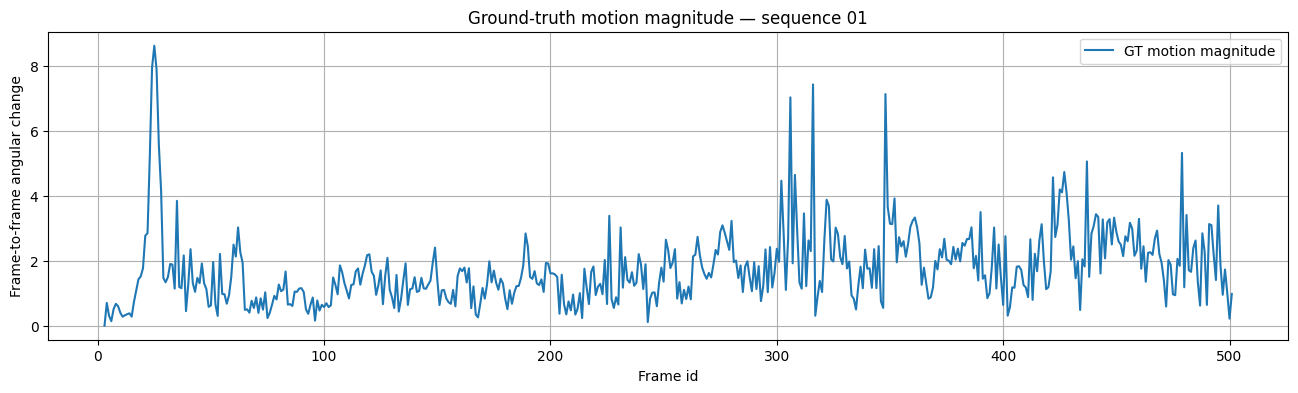

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = add_temporal_deltas(df)

motion_summary = (
    df.groupby("sequence_id")
    .agg(
        num_frames=("frame_id", "count"),
        mean_abs_d_yaw=("abs_d_yaw", "mean"),
        mean_abs_d_roll=("abs_d_roll", "mean"),
        mean_abs_d_pitch=("abs_d_pitch", "mean"),
        mean_motion=("gt_motion_magnitude", "mean"),
        max_motion=("gt_motion_magnitude", "max"),
    )
    .reset_index()
    .sort_values("mean_motion", ascending=False)
)

print("Sequences sorted by average ground-truth frame-to-frame motion:")
display(motion_summary)

# Plot one representative sequence
sample_sequence_id = 1
seq_df = df[df["sequence_id"] == sample_sequence_id].sort_values("frame_id").reset_index(drop=True)

plt.figure(figsize=(16, 5))
plt.plot(seq_df["frame_id"], seq_df["yaw"], label="yaw")
plt.plot(seq_df["frame_id"], seq_df["roll"], label="roll")
plt.plot(seq_df["frame_id"], seq_df["pitch"], label="pitch")
plt.xlabel("Frame id")
plt.ylabel("Angle (degrees)")
plt.title(f"Ground-truth head pose angles over time — sequence {sample_sequence_id:02d}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(seq_df["frame_id"], seq_df["gt_motion_magnitude"], label="GT motion magnitude")
plt.xlabel("Frame id")
plt.ylabel("Frame-to-frame angular change")
plt.title(f"Ground-truth motion magnitude — sequence {sample_sequence_id:02d}")
plt.legend()
plt.grid(True)
plt.show()


### 4.1 Inspecting high-motion events

The previous temporal summary includes all consecutive rows within each sequence, but some BIWI-360 frame IDs are not strictly consecutive. Therefore, a large frame-to-frame change may correspond either to a genuine fast head movement or to a gap in the available frames.

To check this, we inspect the largest ground-truth motion events and include the previous frame ID, current frame ID and `frame_gap`.

The table shows that several of the largest motion values are caused by missing-frame gaps. For example, some transitions jump from frame 364 to 389, or from frame 512 to 579. These should not be interpreted as normal one-frame motion because many intermediate frames are absent.

However, the table also contains some true consecutive-frame events with `frame_gap = 1`, such as transitions in sequences 5, 16, 18 and 21. These correspond to genuine high-motion or abrupt annotation changes between adjacent frames.

This inspection is important for the temporal evaluation. From this point on, temporal metrics should only be computed on valid consecutive pairs, where:

`frame_gap = 1`

This prevents artificial frame gaps from inflating the estimated ground-truth motion or distorting the comparison between real motion and prediction jitter.

In [10]:
# Add previous frame information to inspect temporal continuity
df = df.sort_values(["sequence_id", "frame_id"]).copy()
df["prev_frame_id"] = df.groupby("sequence_id")["frame_id"].shift(1)
df["frame_gap"] = df["frame_id"] - df["prev_frame_id"]

top_motion_events = (
    df.dropna(subset=["prev_frame_id"])
    .sort_values("gt_motion_magnitude", ascending=False)
    .head(15)
    .copy()
)

cols_to_show = [
    "sequence_id", "prev_frame_id", "frame_id", "frame_gap",
    "yaw", "roll", "pitch",
    "d_yaw", "d_roll", "d_pitch",
    "gt_motion_magnitude", "rho", "theta"
]

print("Top frame-to-frame ground-truth motion events:")
display(top_motion_events[cols_to_show])


Top frame-to-frame ground-truth motion events:


,sequence_id,prev_frame_id,frame_id,frame_gap,yaw,roll,pitch,d_yaw,d_roll,d_pitch,gt_motion_magnitude,rho,theta
3795,6,364.0,389,25.0,21.347407,7.994134,66.860206,44.136246,-5.617533,77.449026,89.319183,0.211457,-18.920760
15130,23,512.0,579,67.0,28.157506,3.792424,21.993601,44.477462,-17.601795,11.529899,49.203724,0.481628,-73.632074
1682,3,674.0,683,9.0,12.241342,6.473249,-29.950556,40.091381,-14.879265,-1.948867,42.807819,0.322851,42.022116
12197,18,586.0,657,71.0,14.427515,-14.353755,13.944971,17.299827,-27.786437,-22.122783,39.506805,0.623778,-75.652655
12239,18,698.0,735,37.0,20.089098,33.500744,27.444129,28.645330,25.186956,-7.132467,38.804765,0.503953,-49.958129
11037,16,699.0,700,1.0,-4.531611,-23.328480,62.114505,11.837307,-23.144250,12.749163,28.953744,0.401233,46.038523
3412,5,930.0,931,1.0,-28.822712,7.258646,-1.304977,13.677272,-7.304183,21.672142,26.647713,0.380116,75.336407
11191,16,853.0,884,31.0,38.345789,3.644984,32.114347,25.076622,7.759899,3.638653,26.500807,0.557330,-23.373476
12127,18,480.0,481,1.0,-0.385993,-1.150562,81.481695,-0.771443,-21.339117,15.294205,26.265295,0.423622,-122.498173
15132,23,580.0,773,193.0,1.044262,-0.306037,17.738829,-25.391873,-3.431417,-3.175609,25.818721,0.377761,51.268127


### 4.2 Handling frame gaps

The inspection of high-motion events showed that some large pose changes are not true one-frame movements. In several cases, the `frame_id` jumps by more than one, meaning that the two available annotations are separated by missing intermediate frames.

To avoid overestimating the actual frame-to-frame motion, we explicitly separate three quantities:

| Quantity | Meaning |
|---|---|
| `observed_motion_magnitude` | Angular change between two consecutive rows available in the dataset |
| `motion_per_frame` | Observed angular change divided by the frame ID gap |
| `consecutive_motion_magnitude` | Angular change only for true consecutive pairs, where `frame_gap = 1` |

This distinction is important because temporal stability should be evaluated only on real adjacent-frame transitions. If a transition jumps from frame 364 to frame 389, the change may be large, but it does not represent the motion between two consecutive video frames.

After filtering to valid consecutive pairs, BIWI-360 still contains many true adjacent-frame transitions. The largest genuine one-frame motion events reach around **20–30°**, but the average consecutive motion is much lower, typically around **1–3.5° per frame** depending on the sequence.

From this point onward, temporal metrics such as prediction jitter and temporal motion error will be computed using only pairs with:

`frame_gap = 1`

This makes the later comparison fair: if the ground truth usually changes only a few degrees between adjacent frames, then model predictions should not jump by tens or hundreds of degrees unless the model is temporally unstable.

In [11]:
# Recompute temporal quantities while explicitly handling frame gaps
df = df.sort_values(["sequence_id", "frame_id"]).copy()

df["prev_frame_id"] = df.groupby("sequence_id")["frame_id"].shift(1)
df["frame_gap"] = df["frame_id"] - df["prev_frame_id"]

for angle in ["yaw", "roll", "pitch"]:
    df[f"d_{angle}"] = df.groupby("sequence_id")[angle].diff()
    df[f"abs_d_{angle}"] = df[f"d_{angle}"].abs()

df["observed_motion_magnitude"] = np.sqrt(
    df["d_yaw"].fillna(0) ** 2 +
    df["d_roll"].fillna(0) ** 2 +
    df["d_pitch"].fillna(0) ** 2
)

df["motion_per_frame"] = df["observed_motion_magnitude"] / df["frame_gap"]

df["is_consecutive_pair"] = df["frame_gap"] == 1

df["consecutive_motion_magnitude"] = np.where(
    df["is_consecutive_pair"],
    df["observed_motion_magnitude"],
    np.nan
)

gap_summary = (
    df.dropna(subset=["frame_gap"])
    .groupby("sequence_id")
    .agg(
        num_pairs=("frame_gap", "count"),
        consecutive_pairs=("is_consecutive_pair", "sum"),
        non_consecutive_pairs=("is_consecutive_pair", lambda x: (~x).sum()),
        max_frame_gap=("frame_gap", "max"),
        mean_consecutive_motion=("consecutive_motion_magnitude", "mean"),
        max_consecutive_motion=("consecutive_motion_magnitude", "max"),
        mean_motion_per_frame=("motion_per_frame", "mean"),
        max_motion_per_frame=("motion_per_frame", "max"),
    )
    .reset_index()
    .sort_values("mean_consecutive_motion", ascending=False)
)

print("Frame gap and corrected motion summary:")
display(gap_summary)

print("\nLargest true consecutive-frame motion events:")
display(
    df[df["is_consecutive_pair"]]
    .sort_values("consecutive_motion_magnitude", ascending=False)
    .head(15)[
        [
            "sequence_id", "prev_frame_id", "frame_id", "frame_gap",
            "yaw", "roll", "pitch",
            "d_yaw", "d_roll", "d_pitch",
            "consecutive_motion_magnitude",
            "rho", "theta"
        ]
    ]
)


Frame gap and corrected motion summary:


,sequence_id,num_pairs,consecutive_pairs,non_consecutive_pairs,max_frame_gap,mean_consecutive_motion,max_consecutive_motion,mean_motion_per_frame,max_motion_per_frame
5,6,541,539,2,34.0,3.361788,18.854102,3.356486,18.854102
20,21,633,628,5,56.0,3.297967,23.939624,3.281727,23.939624
17,18,613,609,4,71.0,2.849727,26.265295,2.836422,26.265295
14,15,653,651,2,30.0,2.783583,12.895282,2.775543,12.895282
22,23,568,566,2,193.0,2.717228,11.919311,2.709189,11.919311
18,19,501,500,1,22.0,2.669663,11.023587,2.664571,11.023587
13,14,796,796,0,1.0,2.619449,9.800047,2.619449,9.800047
16,17,394,392,2,45.0,2.492552,15.323107,2.481408,15.323107
15,16,913,911,2,31.0,2.471317,28.953744,2.467505,28.953744
23,24,491,489,2,84.0,2.362625,10.669820,2.354259,10.669820



Largest true consecutive-frame motion events:


,sequence_id,prev_frame_id,frame_id,frame_gap,yaw,roll,pitch,d_yaw,d_roll,d_pitch,consecutive_motion_magnitude,rho,theta
11037,16,699.0,700,1.0,-4.531611,-23.328480,62.114505,11.837307,-23.144250,12.749163,28.953744,0.401233,46.038523
3412,5,930.0,931,1.0,-28.822712,7.258646,-1.304977,13.677272,-7.304183,21.672142,26.647713,0.380116,75.336407
12127,18,480.0,481,1.0,-0.385993,-1.150562,81.481695,-0.771443,-21.339117,15.294205,26.265295,0.423622,-122.498173
11048,16,710.0,711,1.0,1.993040,23.932825,-11.547316,-15.563452,15.706857,10.507836,24.481443,0.126256,-56.713146
13457,21,138.0,139,1.0,-69.553207,2.718918,18.317681,-0.374926,-18.473249,15.221829,23.939624,0.090083,-18.011050
13670,21,358.0,359,1.0,3.818794,3.343178,62.249247,15.104764,-15.872656,0.661997,21.921071,0.714871,-38.537136
3293,5,811.0,812,1.0,-9.168125,6.079890,-43.387302,18.768912,-10.637561,0.148096,21.574329,0.687212,-143.537217
3411,5,929.0,930,1.0,-42.499984,14.562829,-22.977119,-2.304236,-9.910234,18.007334,20.682996,0.114303,-71.034853
11043,16,705.0,706,1.0,16.849036,-28.826517,-1.851251,4.627685,2.113813,-18.192720,18.890705,0.423010,-39.128496
3547,6,116.0,117,1.0,-74.670407,17.289399,6.903782,0.219121,14.224531,-12.373029,18.854102,0.223681,49.871457


### 4.3 Visual inspection of a true high-motion event

After correcting for frame gaps, we inspect the strongest **true consecutive-frame motion event**, which occurs in **sequence 16 between frames 699 and 700**. This event has a ground-truth motion magnitude of about **29°**, making it a useful example for understanding what a genuinely difficult temporal transition looks like.

The local angle trajectories show that this is not an isolated annotation glitch. Instead, the event appears inside a short temporal segment where the pose evolves rapidly, especially in **roll** and **pitch**. Around frame 700, the subject is looking strongly upward, and the head orientation changes substantially over only a few adjacent frames.

The corresponding image sequence confirms this interpretation visually. The face undergoes a clear change in orientation across the window, while the fisheye appearance also varies noticeably from frame to frame. This is a good example of a genuinely challenging case for temporal prediction:

- the head pose changes quickly;
- the face is already strongly distorted by the fisheye transformation;
- the model must distinguish real motion from distortion-induced appearance changes.

This kind of event helps motivate the later temporal analysis. A temporally stable model should be able to follow such fast but real pose transitions without introducing artificial jumps, while temporal smoothing should ideally reduce jitter without suppressing true motion.

Selected high-motion event:


sequence_id                            16
prev_frame_id                       699.0
frame_id                              700
frame_gap                             1.0
yaw                             -4.531611
roll                            -23.32848
pitch                           62.114505
d_yaw                           11.837307
d_roll                          -23.14425
d_pitch                         12.749163
consecutive_motion_magnitude    28.953744
rho                              0.401233
theta                           46.038523
Name: 11037, dtype: object


Temporal window around the event:


,sequence_id,frame_id,yaw,roll,pitch,consecutive_motion_magnitude,rho,theta
0,16,695,-3.849287,31.068011,17.068826,13.329200,0.043766,28.512174
1,16,696,-9.902146,28.386931,26.230939,11.303522,0.338310,154.639296
2,16,697,-13.112218,19.612712,35.943585,13.476905,0.029792,-35.893442
3,16,698,-11.159914,10.880800,45.226339,12.892916,0.007660,-13.499510
4,16,699,-16.368918,-0.184230,49.365342,12.911234,0.473448,-61.062751
5,16,700,-4.531611,-23.328480,62.114505,28.953744,0.401233,46.038523
6,16,701,-10.522929,-23.648027,62.986291,6.062839,0.500654,3.090260
7,16,702,1.660177,-28.409034,53.114007,16.387717,0.566981,77.256481
8,16,703,0.707695,-27.548295,45.644887,7.578644,0.607540,45.629462
9,16,704,5.593080,-28.812741,32.310065,14.257745,0.122861,-157.322498


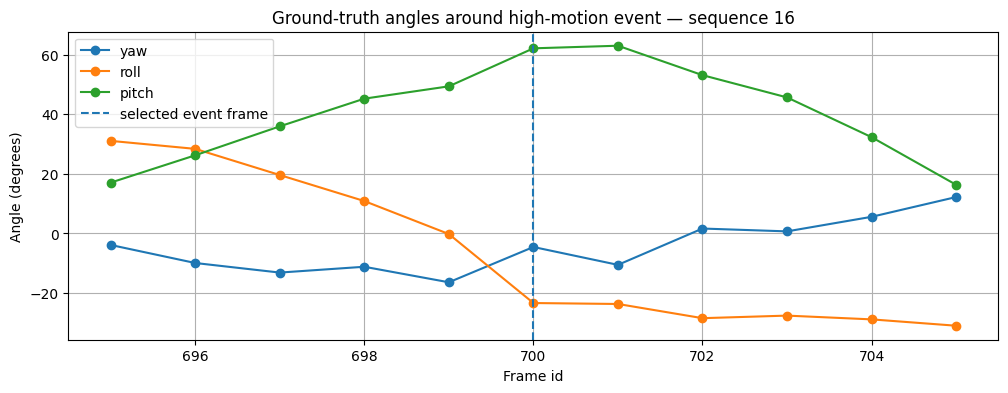

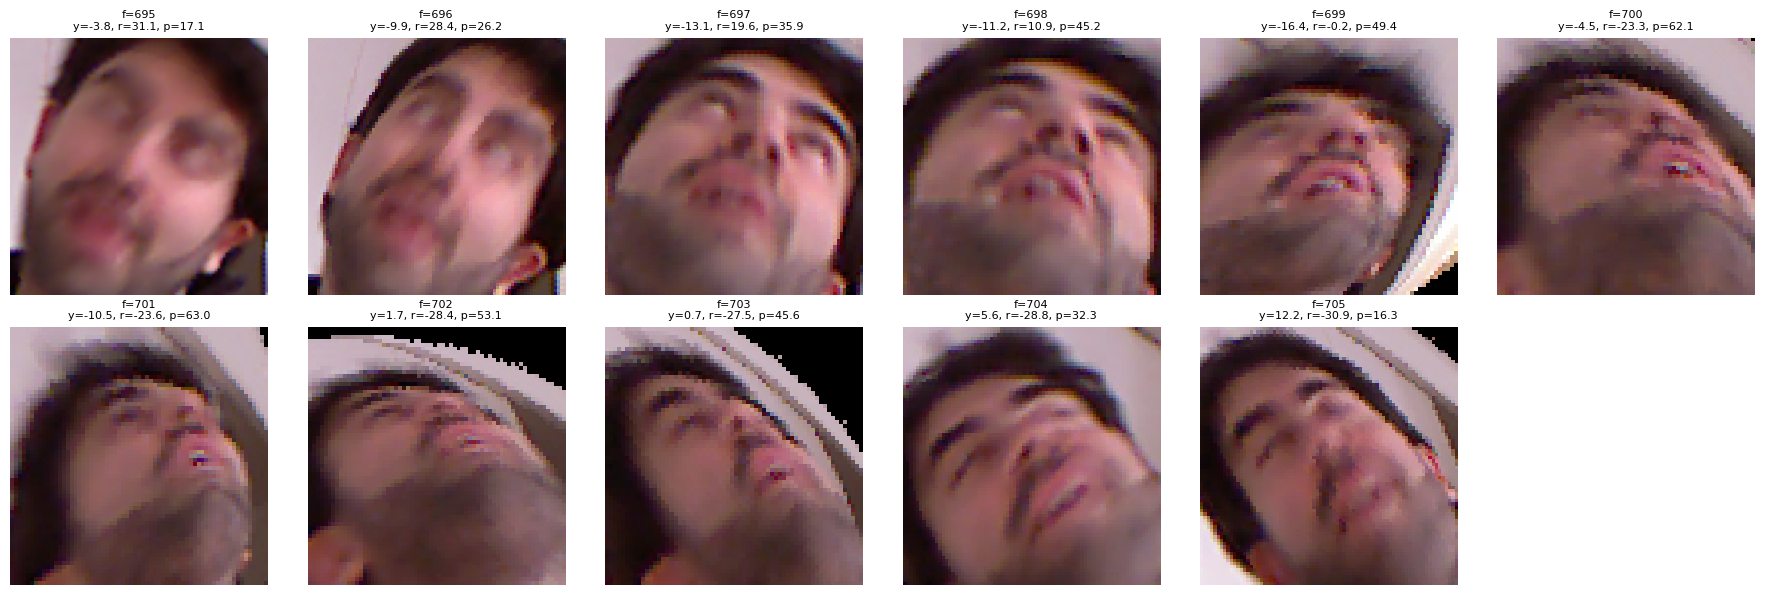

In [12]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Select the largest true consecutive-frame motion event
event = (
    df[df["is_consecutive_pair"]]
    .sort_values("consecutive_motion_magnitude", ascending=False)
    .iloc[0]
)

event_sequence = int(event["sequence_id"])
event_frame = int(event["frame_id"])
window = 5

event_window = (
    df[
        (df["sequence_id"] == event_sequence) &
        (df["frame_id"].between(event_frame - window, event_frame + window))
    ]
    .sort_values("frame_id")
    .reset_index(drop=True)
)

print("Selected high-motion event:")
display(event[[
    "sequence_id", "prev_frame_id", "frame_id", "frame_gap",
    "yaw", "roll", "pitch",
    "d_yaw", "d_roll", "d_pitch",
    "consecutive_motion_magnitude",
    "rho", "theta"
]])

print("\nTemporal window around the event:")
display(event_window[[
    "sequence_id", "frame_id",
    "yaw", "roll", "pitch",
    "consecutive_motion_magnitude",
    "rho", "theta"
]])

# Plot angle trajectories in the local window
plt.figure(figsize=(12, 4))
plt.plot(event_window["frame_id"], event_window["yaw"], marker="o", label="yaw")
plt.plot(event_window["frame_id"], event_window["roll"], marker="o", label="roll")
plt.plot(event_window["frame_id"], event_window["pitch"], marker="o", label="pitch")
plt.axvline(event_frame, linestyle="--", label="selected event frame")
plt.xlabel("Frame id")
plt.ylabel("Angle (degrees)")
plt.title(f"Ground-truth angles around high-motion event — sequence {event_sequence:02d}")
plt.legend()
plt.grid(True)
plt.show()

# Visualize frames around the event
num_frames_to_show = min(len(event_window), 12)
plt.figure(figsize=(18, 6))

for i, (_, row) in enumerate(event_window.iloc[:num_frames_to_show].iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 6, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"f={int(row['frame_id'])}\n"
        f"y={row['yaw']:.1f}, r={row['roll']:.1f}, p={row['pitch']:.1f}",
        fontsize=8
    )

plt.tight_layout()
plt.show()


### 4.4 Temporal behavior of fisheye distortion metadata

The visual inspection shows that temporal changes in BIWI-360 are not only caused by head motion. The fisheye distortion parameters can also change substantially from one frame to the next, modifying the visual appearance of the face even when the underlying pose changes smoothly.

In BIWI-360, `rho` is the normalized radial position used to generate the fisheye effect, and `theta` is the angular position in degrees. These parameters determine where the face was placed before applying the synthetic fisheye transformation.

The summary table shows that, even for valid consecutive-frame pairs, the fisheye metadata varies strongly across all sequences. The average absolute change in `rho` is around **0.25–0.29** per frame, while the average circular change in `theta` is close to **90°** per frame. This suggests that the fisheye location is not temporally smooth, even though the original BIWI head pose trajectory is a video sequence.

The local plots around the selected high-motion event confirm this behavior. Around sequence 16, frame 700, both `rho` and `theta` fluctuate strongly from frame to frame. As a result, two adjacent frames may contain both real head motion and a large change in fisheye-induced appearance.

This is a key difficulty of BIWI-360:

- the ground-truth pose follows a video sequence;
- the fisheye distortion metadata can change abruptly between adjacent frames;
- the model receives visually inconsistent inputs even when the real head motion is relatively smooth.

This observation is central to the project. It means that prediction jitter may not only come from temporal instability in the model, but also from frame-level domain shift caused by changing fisheye distortion. Later, this motivates both the `rho`-based failure analysis and the location-guided fine-tuning experiment.

Temporal variation of fisheye distortion metadata in consecutive frame pairs:


,sequence_id,mean_abs_d_rho,max_abs_d_rho,mean_abs_d_theta,max_abs_d_theta,mean_consecutive_motion
1,2,0.293180,0.778485,92.099688,179.999919,1.465451
21,22,0.281305,0.773895,90.469284,179.771440,1.659451
22,23,0.277830,0.786281,89.114111,178.481651,2.717228
15,16,0.276735,0.780543,89.506495,179.801341,2.471317
23,24,0.276229,0.784355,90.746203,179.897569,2.362625
7,8,0.274179,0.784896,89.205556,179.978416,1.718165
20,21,0.274110,0.773897,86.763201,179.761454,3.297967
14,15,0.272847,0.784782,90.904430,179.945849,2.783583
11,12,0.270826,0.775445,91.189305,179.492981,1.085571
16,17,0.270562,0.759482,86.085297,179.631652,2.492552


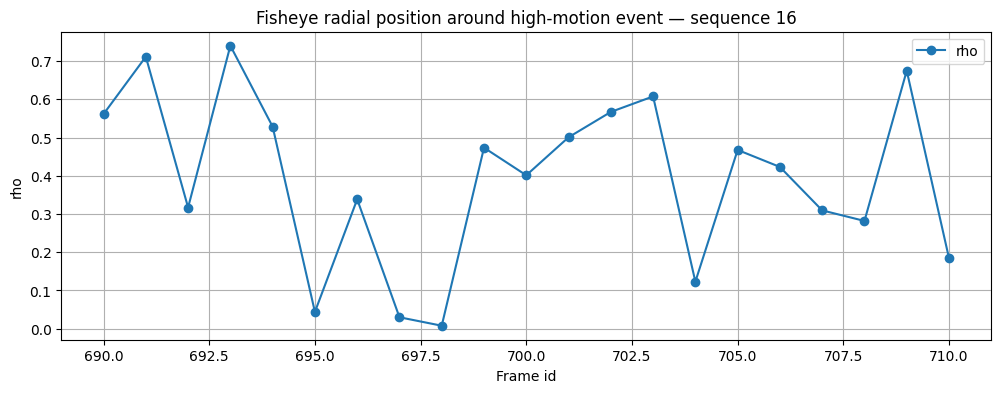

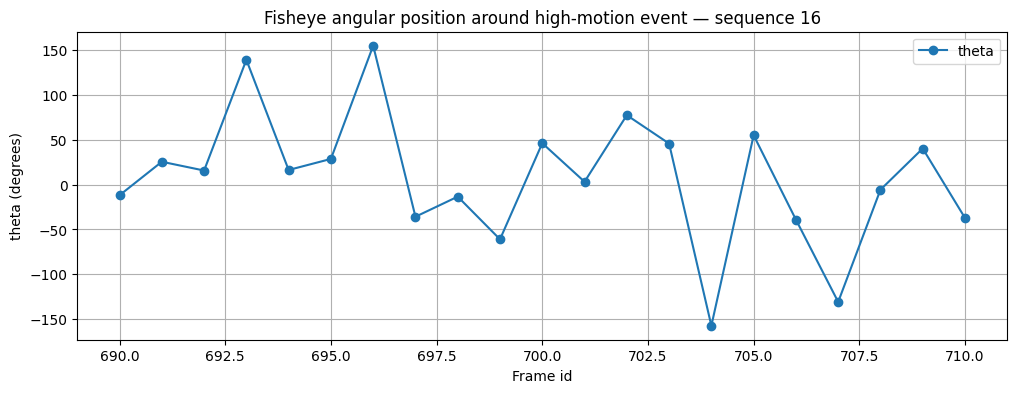

Fisheye metadata around the selected event:


,sequence_id,frame_id,yaw,roll,pitch,rho,theta,abs_d_rho,abs_d_theta_circular,consecutive_motion_magnitude
0,16,690,20.358862,-9.042987,-16.822059,0.561373,-11.948805,0.215088,30.080060,10.257547
1,16,691,16.694705,2.476415,-14.645219,0.711456,25.365397,0.150083,37.314202,12.282562
2,16,692,14.164224,12.970270,-9.381875,0.316937,15.582250,0.394519,9.783147,12.009459
3,16,693,10.273026,24.010633,-1.459435,0.740184,138.952373,0.423248,123.370123,14.134924
4,16,694,4.095913,29.027902,6.562670,0.528453,16.194854,0.211731,122.757519,11.299729
5,16,695,-3.849287,31.068011,17.068826,0.043766,28.512174,0.484687,12.317321,13.329200
6,16,696,-9.902146,28.386931,26.230939,0.338310,154.639296,0.294544,126.127122,11.303522
7,16,697,-13.112218,19.612712,35.943585,0.029792,-35.893442,0.308517,169.467262,13.476905
8,16,698,-11.159914,10.880800,45.226339,0.007660,-13.499510,0.022132,22.393931,12.892916
9,16,699,-16.368918,-0.184230,49.365342,0.473448,-61.062751,0.465788,47.563240,12.911234


In [13]:
# Compute temporal changes in fisheye metadata
df = df.sort_values(["sequence_id", "frame_id"]).copy()

df["d_rho"] = df.groupby("sequence_id")["rho"].diff()
df["abs_d_rho"] = df["d_rho"].abs()

# Circular difference for theta in degrees

df["prev_theta"] = df.groupby("sequence_id")["theta"].shift(1)
df["d_theta_circular"] = circular_angle_diff_deg(df["theta"], df["prev_theta"])
df["abs_d_theta_circular"] = df["d_theta_circular"].abs()

fisheye_summary = (
    df[df["is_consecutive_pair"]]
    .groupby("sequence_id")
    .agg(
        mean_abs_d_rho=("abs_d_rho", "mean"),
        max_abs_d_rho=("abs_d_rho", "max"),
        mean_abs_d_theta=("abs_d_theta_circular", "mean"),
        max_abs_d_theta=("abs_d_theta_circular", "max"),
        mean_consecutive_motion=("consecutive_motion_magnitude", "mean"),
    )
    .reset_index()
    .sort_values("mean_abs_d_rho", ascending=False)
)

print("Temporal variation of fisheye distortion metadata in consecutive frame pairs:")
display(fisheye_summary)

# Plot fisheye metadata around the high-motion event already selected
event_sequence = int(event["sequence_id"])
event_frame = int(event["frame_id"])
window = 10

fisheye_window = (
    df[
        (df["sequence_id"] == event_sequence) &
        (df["frame_id"].between(event_frame - window, event_frame + window))
    ]
    .sort_values("frame_id")
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 4))
plt.plot(fisheye_window["frame_id"], fisheye_window["rho"], marker="o", label="rho")
plt.xlabel("Frame id")
plt.ylabel("rho")
plt.title(f"Fisheye radial position around high-motion event — sequence {event_sequence:02d}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(fisheye_window["frame_id"], fisheye_window["theta"], marker="o", label="theta")
plt.xlabel("Frame id")
plt.ylabel("theta (degrees)")
plt.title(f"Fisheye angular position around high-motion event — sequence {event_sequence:02d}")
plt.legend()
plt.grid(True)
plt.show()

print("Fisheye metadata around the selected event:")
display(fisheye_window[[
    "sequence_id", "frame_id",
    "yaw", "roll", "pitch",
    "rho", "theta",
    "abs_d_rho", "abs_d_theta_circular",
    "consecutive_motion_magnitude"
]])


### 4.5 Defining temporal analysis regimes

The previous analysis shows that BIWI-360 combines two different sources of temporal variation. The original head pose still follows a video sequence, but the fisheye distortion metadata can change abruptly from one frame to the next. Therefore, prediction instability may be caused by:

1. real head pose motion;
2. frame-level changes in fisheye distortion;
3. the interaction between both factors.

To make the later temporal evaluation more interpretable, we define temporal regimes using only valid consecutive-frame pairs. Each pair is classified according to:

- its ground-truth pose motion;
- its normalized fisheye distortion change.

The fisheye-change score combines the change in `rho` and the circular change in `theta`. We normalize `rho` by its maximum range, `0.8`, and `theta` by its maximum circular difference, `180°`.

Rather than using arbitrary fixed thresholds, we define the regimes from the empirical distribution:

| Level | Definition |
|---|---|
| `low` | Below the 75th percentile |
| `medium` | Between the 75th and 90th percentiles |
| `high` | Above the 90th percentile |

This gives **15,628 valid consecutive-frame pairs**. The resulting thresholds are:

- motion: `q75 ≈ 2.535°`, `q90 ≈ 3.914°`;
- fisheye change: `q75 ≈ 0.867`, `q90 ≈ 0.996`.

The joint regime table shows that high motion and high fisheye change do not always occur together. For example, there are many low-motion pairs with high fisheye change, meaning that the head pose changes little while the visual distortion changes strongly. These cases are especially important for this project, because a robust model should avoid producing large prediction jumps when the true pose is stable but the fisheye appearance changes.

These temporal regimes will be used later to analyze whether prediction jitter is mainly associated with real head motion, with fisheye variation, or with both.

In [14]:
# Build a clean table of true consecutive frame pairs for temporal analysis
temporal_pairs = df[df["is_consecutive_pair"]].copy().reset_index(drop=True)

# Normalized fisheye change:
# - rho is in [0, 0.8], so we normalize by 0.8
# - theta circular difference is in [0, 180], so we normalize by 180
temporal_pairs["fisheye_change"] = np.sqrt(
    (temporal_pairs["abs_d_rho"] / 0.8) ** 2 +
    (temporal_pairs["abs_d_theta_circular"] / 180.0) ** 2
)

# Define thresholds using quantiles rather than fixed arbitrary values
motion_q75 = temporal_pairs["consecutive_motion_magnitude"].quantile(0.75)
motion_q90 = temporal_pairs["consecutive_motion_magnitude"].quantile(0.90)

fisheye_q75 = temporal_pairs["fisheye_change"].quantile(0.75)
fisheye_q90 = temporal_pairs["fisheye_change"].quantile(0.90)

temporal_pairs["motion_level"] = temporal_pairs["consecutive_motion_magnitude"].apply(
    lambda x: assign_level(x, motion_q75, motion_q90)
)

temporal_pairs["fisheye_change_level"] = temporal_pairs["fisheye_change"].apply(
    lambda x: assign_level(x, fisheye_q75, fisheye_q90)
)

print("Number of consecutive frame pairs:", len(temporal_pairs))

print("\nMotion thresholds:")
print(f"75th percentile: {motion_q75:.3f}")
print(f"90th percentile: {motion_q90:.3f}")

print("\nFisheye-change thresholds:")
print(f"75th percentile: {fisheye_q75:.3f}")
print(f"90th percentile: {fisheye_q90:.3f}")

print("\nMotion level counts:")
display(temporal_pairs["motion_level"].value_counts().rename_axis("motion_level").reset_index(name="count"))

print("\nFisheye-change level counts:")
display(temporal_pairs["fisheye_change_level"].value_counts().rename_axis("fisheye_change_level").reset_index(name="count"))

print("\nJoint regime counts:")
display(
    temporal_pairs
    .groupby(["motion_level", "fisheye_change_level"])
    .size()
    .reset_index(name="count")
    .sort_values(["motion_level", "fisheye_change_level"])
)

print("\nExample high-motion and high-distortion-change pairs:")
display(
    temporal_pairs[
        (temporal_pairs["motion_level"] == "high") &
        (temporal_pairs["fisheye_change_level"] == "high")
    ][[
        "sequence_id", "prev_frame_id", "frame_id",
        "yaw", "roll", "pitch",
        "consecutive_motion_magnitude",
        "rho", "theta",
        "abs_d_rho", "abs_d_theta_circular",
        "fisheye_change",
        "motion_level", "fisheye_change_level"
    ]].head(10)
)


Number of consecutive frame pairs: 15628

Motion thresholds:
75th percentile: 2.535
90th percentile: 3.914

Fisheye-change thresholds:
75th percentile: 0.867
90th percentile: 0.996

Motion level counts:


,motion_level,count
0,low,11721
1,medium,2344
2,high,1563



Fisheye-change level counts:


,fisheye_change_level,count
0,low,11721
1,medium,2344
2,high,1563



Joint regime counts:


,motion_level,fisheye_change_level,count
0,high,high,140
1,high,low,1159
2,high,medium,264
3,low,high,1187
4,low,low,8785
5,low,medium,1749
6,medium,high,236
7,medium,low,1777
8,medium,medium,331



Example high-motion and high-distortion-change pairs:


,sequence_id,prev_frame_id,frame_id,yaw,roll,pitch,consecutive_motion_magnitude,rho,theta,abs_d_rho,abs_d_theta_circular,fisheye_change,motion_level,fisheye_change_level
19,1,22.0,23,17.959581,3.643839,15.247137,5.190434,0.103492,-152.658969,0.382351,158.168564,1.000282,high,high
304,1,307.0,308,-58.462280,15.803192,-21.067019,4.645668,0.258720,38.310167,0.540472,170.311493,1.162613,high,high
423,1,426.0,427,37.767735,-34.432472,-51.356571,4.733204,0.583560,10.015673,0.477031,161.111619,1.075500,high,high
833,2,338.0,339,-12.293116,21.179186,-53.616307,3.928912,0.158102,132.488993,0.528819,168.016834,1.143782,high,high
841,2,346.0,347,-5.046678,9.913918,-53.507912,4.050873,0.269263,-52.965853,0.308319,171.233517,1.026401,high,high
853,2,358.0,359,4.965018,-12.767263,-52.496013,5.210252,0.013459,-149.857898,0.718725,135.420136,1.171810,high,high
976,2,481.0,482,27.644811,-15.283466,-25.475475,4.471715,0.747373,166.805707,0.624250,134.182182,1.079163,high,high
1301,3,296.0,297,41.108193,25.703239,34.478895,4.106855,0.017811,-9.005829,0.398731,157.882408,1.008843,high,high
1411,3,406.0,407,-22.565788,-2.168420,12.432658,11.369611,0.072981,-158.419832,0.715091,128.635670,1.144424,high,high
1862,4,129.0,130,50.774036,33.549748,42.305406,5.000673,0.210213,25.409452,0.516394,160.001848,1.098546,high,high


## 5. Dataset analysis summary

The dataset inspection confirms that **BIWI-360** contains **15,678 RGB frames** organized into **24 video sequences**, with one annotation row per available frame. All image paths referenced by the annotation table were found successfully, so the labels and RGB frames are correctly matched.

Each annotation provides the ground-truth head pose angles, **yaw**, **roll** and **pitch**, together with two fisheye metadata values: `rho`, the normalized radial position, and `theta`, the angular position in degrees. These metadata values describe how the synthetic fisheye distortion was generated; they are not head pose labels.

The temporal analysis reveals an important property of BIWI-360. The original head pose follows a video trajectory and is generally smooth between adjacent frames, with most true frame-to-frame pose changes being only a few degrees. However, the fisheye metadata can change strongly between consecutive frames. In practice, this means that the real pose may be temporally smooth while the image geometry is not.

For this reason, all later temporal metrics are computed only on true consecutive frame pairs, where `frame_gap = 1`. We also define quantile-based temporal regimes according to ground-truth motion and fisheye-change magnitude. This allows us to separate cases with low or high real head motion from cases with low or high distortion change.

This analysis establishes the main difficulty of the dataset: prediction instability can be caused by both real head movement and artificial frame-level changes in fisheye distortion. Therefore, a robust model should not only estimate head pose accurately in individual frames, but also remain stable when the visual appearance changes because of the fisheye transformation rather than actual head rotation.

### 5.1 Is BIWI-360 temporally coherent?

BIWI-360 inherits the temporal head-pose trajectory of the original BIWI dataset, but the fisheye distortion is generated independently for each image. In other words, consecutive frames can have smoothly varying **yaw**, **roll** and **pitch**, while their fisheye location parameters, `rho` and `theta`, may change almost randomly from one frame to the next.

We verify this by comparing the observed frame-to-frame changes in `rho` and `theta` with the values expected if they were sampled independently from uniform distributions:

- for two independent circular samples of `theta` in `[-180°, 180°]`, the expected mean absolute circular difference is **90°**;
- for two independent samples of `rho` in `[0, 0.8]`, the expected mean absolute difference is **0.8 / 3 ≈ 0.267**.

The observed values are almost identical to these expectations:

| Quantity | Observed | Expected under independent sampling |
|---|---:|---:|
| mean \|delta theta\| | ≈ 89.75° | 90.00° |
| mean \|delta rho\| | ≈ 0.267 | ≈ 0.267 |

This confirms an important property of BIWI-360: the **pose signal is temporal**, but the **fisheye distortion is not temporally coherent**.

This has two consequences for the rest of the notebook. First, the fisheye-change regimes should be interpreted as frame-level distortion-change bins, not as meaningful physical motion patterns. Second, temporal post-processing such as EMA can help because it denoises predictions affected by independently changing fisheye distortion, while the underlying pose remains comparatively smoother.

Therefore, prediction jitter in BIWI-360 should not be understood only as a video-tracking problem. It is also a domain-shift problem caused by strong, frame-wise changes in image geometry.

In [15]:
# Quantify the temporal (in)coherence of the fisheye distortion in BIWI-360.
obs_d_theta = temporal_pairs["abs_d_theta_circular"].mean()
obs_d_rho = temporal_pairs["abs_d_rho"].mean()

# Expected values if rho, theta are sampled i.i.d. per frame:
#   E|theta_t - theta_{t-1}| for two i.i.d. circular Uniform(-180,180) = 90 deg
#   E|rho_t   - rho_{t-1}|   for two i.i.d. Uniform(0, 0.8)            = 0.8/3
fisheye_coherence = pd.DataFrame([
    {"quantity": "mean |delta theta| (deg)", "observed": obs_d_theta, "iid_uniform_expected": 90.0},
    {"quantity": "mean |delta rho|",         "observed": obs_d_rho,   "iid_uniform_expected": 0.8/3.0},
])
print("Temporal coherence of the fisheye distortion (observed vs i.i.d.-uniform expectation):")
display(fisheye_coherence)


Temporal coherence of the fisheye distortion (observed vs i.i.d.-uniform expectation):


,quantity,observed,iid_uniform_expected
0,mean |delta theta| (deg),89.754014,90.000000
1,mean |delta rho|,0.267391,0.266667


## 6. Model setup strategy

After preparing and analyzing BIWI-360, we now set up the head pose estimation model. The first model used in this notebook is a pretrained **6DRepNet360** estimator, applied frame by frame as a zero-shot baseline.

This step is important because the goal is to evaluate whether a strong modern head pose estimator can generalize directly to fisheye-distorted BIWI-360 images, before applying any temporal post-processing or domain adaptation.

Before cloning the external repository or downloading pretrained weights, we check two practical conditions in the Kaggle environment:

- whether GitHub is reachable, so the 6DRepNet360 repository can be cloned;
- whether the official pretrained weights URL is reachable.

Both checks return status `200`, confirming that the current runtime has access to the required external resources.

This makes the setup explicit and reproducible. If internet access were unavailable, the notebook would need the repository and model weights to be attached as Kaggle inputs instead of downloaded during execution.

In [17]:
import urllib.request

github_ok, github_status = check_url_available("https://github.com", timeout=10)
weights_ok, weights_status = check_url_available(
    "https://cloud.ovgu.de/s/TewGC9TDLGgKkmS/download/6DRepNet360_Full-Rotation_300W_LP+Panoptic.pth",
    timeout=10
)

print("Internet check:")
print("GitHub reachable:", github_ok)
print("GitHub status / error:", github_status)

print("\nOfficial weights URL reachable:", weights_ok)
print("Weights status / error:", weights_status)


Internet check:
GitHub reachable: True
GitHub status / error: 200

Official weights URL reachable: True
Weights status / error: 200


### 6.1 Cloning the 6DRepNet360 repository

Since GitHub is reachable from the Kaggle environment, we clone the official **6DRepNet360** repository and inspect its contents before loading the model. This makes the dependency on external code explicit and ensures that the notebook is reproducible.

6DRepNet360 is used as our initial frame-by-frame baseline because it is a recent full-range head pose estimator based on a 6D rotation representation. This representation is more geometrically stable than directly regressing Euler angles, and the model can be loaded from a public implementation with pretrained weights.

The repository is cloned into:

`/kaggle/working/external/6DRepNet360`

We also record the exact Git commit:

`b06e4fed77f802fbf05319b85bb65215087d5c7a`

Recording the commit is important because it fixes the version of the external code used in this experiment. Later results should therefore be traceable to the same model implementation.

In [18]:
import subprocess
from pathlib import Path

EXTERNAL_DIR = Path("/kaggle/working/external")
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

REPO_DIR = EXTERNAL_DIR / "6DRepNet360"
REPO_URL = "https://github.com/thohemp/6DRepNet360.git"

if REPO_DIR.exists():
    print("Repository already exists:", REPO_DIR)
else:
    print("Cloning repository...")
    result = subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        capture_output=True,
        text=True
    )
    print("Return code:", result.returncode)
    if result.stdout:
        print("\nSTDOUT:")
        print(result.stdout)
    if result.stderr:
        print("\nSTDERR:")
        print(result.stderr)

print("\nRepository directory:")
print(REPO_DIR)

print("\nTop-level repository files:")
for path in sorted(REPO_DIR.iterdir()):
    print(" -", path.name)

print("\nCurrent repository commit:")
commit_result = subprocess.run(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"],
    capture_output=True,
    text=True
)
print(commit_result.stdout.strip())


Cloning repository...
Return code: 0

STDERR:
Cloning into '/kaggle/working/external/6DRepNet360'...


Repository directory:
/kaggle/working/external/6DRepNet360

Top-level repository files:
 - .git
 - LICENSE.MD
 - README.MD
 - sixdrepnet360

Current repository commit:
b06e4fed77f802fbf05319b85bb65215087d5c7a


### 6.2 Inspecting the repository structure

After cloning the official **6DRepNet360** repository, we inspect its README and source files before importing the package. This avoids treating the external repository as a black box and helps verify which model implementation and pretrained weights are being used.

The README confirms that this repository is the PyTorch implementation of **6DRepNet360**, associated with the paper *Toward Robust and Unconstrained Full Range of Rotation Head Pose Estimation* published in IEEE Transactions on Image Processing in 2024. It also lists two available pretrained checkpoints. In this notebook, we use the **Full Rotation** model fine-tuned on **300W-LP + Panoptic**, which is the most appropriate public checkpoint for wide-range head pose estimation.

The repository structure is compact. The relevant source files are located inside the `sixdrepnet360` package:

| File | Role in this notebook |
|---|---|
| `test.py` | Contains the model architecture definition used for inference |
| `utils.py` | Contains rotation and Euler-angle conversion utilities |
| `datasets.py` | Dataset-related utilities from the original repository |

This inspection justifies the next setup steps: adding the cloned repository to Python's import path, importing the model architecture and helper functions, and loading the pretrained checkpoint explicitly.

In [19]:
from pathlib import Path

readme_path = REPO_DIR / "README.MD"

print("README exists:", readme_path.exists())

if readme_path.exists():
    readme_text = readme_path.read_text(errors="ignore")
    print("\nREADME preview:")
    print("=" * 100)
    print(readme_text[:6000])
    print("=" * 100)

print("\nRepository tree preview:")
for path in sorted(REPO_DIR.rglob("*")):
    relative = path.relative_to(REPO_DIR)
    depth = len(relative.parts)
    if depth <= 3:
        prefix = "  " * (depth - 1)
        print(f"{prefix}- {relative}")


README exists: True

README preview:
[![PWC](https://img.shields.io/endpoint.svg?url=https://paperswithcode.com/badge/towards-robust-and-unconstrained-full-range/head-pose-estimation-on-biwi)](https://paperswithcode.com/sota/head-pose-estimation-on-biwi?p=towards-robust-and-unconstrained-full-range)
[![PWC](https://img.shields.io/endpoint.svg?url=https://paperswithcode.com/badge/towards-robust-and-unconstrained-full-range/head-pose-estimation-on-cmu-panoptic-300w-lp)](https://paperswithcode.com/sota/head-pose-estimation-on-cmu-panoptic-300w-lp?p=towards-robust-and-unconstrained-full-range)
[![PWC](https://img.shields.io/endpoint.svg?url=https://paperswithcode.com/badge/towards-robust-and-unconstrained-full-range/head-pose-estimation-on-aflw2000)](https://paperswithcode.com/sota/head-pose-estimation-on-aflw2000?p=towards-robust-and-unconstrained-full-range)
# <div align="center"> **6DRepNet360** </div>

<p align="center">
  <img src="https://github.com/thohemp/archive/blob/main/6drepnet

### 6.3 Inspecting the 6DRepNet360 source code

The official README gives the model checkpoint links but does not provide a complete usage example. Therefore, we inspect the repository source files before importing the model. This allows us to identify the model class, preprocessing pipeline and rotation utilities needed for inference.

The most important file for this notebook is `sixdrepnet360/test.py`. It defines the `SixDRepNet360` architecture, which uses a ResNet-style backbone with Bottleneck blocks and a final linear regression layer that outputs **6 values**. These 6 values are then converted into a valid 3D rotation matrix using the repository function:

`compute_rotation_matrix_from_ortho6d`

This confirms that the model does not directly regress yaw, roll and pitch. Instead, it predicts a 6D rotation representation, which is then mapped to a rotation matrix. This is one of the main reasons for choosing 6DRepNet360: the representation is more geometrically consistent than directly predicting Euler angles.

The source code also shows the standard preprocessing used by the repository:

- resize image to 256;
- center crop to 224;
- convert to tensor;
- normalize with ImageNet mean and standard deviation.

The file `sixdrepnet360/utils.py` contains the key rotation utilities used later in the notebook, especially:

- conversion from 6D representation to rotation matrix;
- conversion from rotation matrix to Euler angles;
- helper functions for rotation matrices and visualization.

Finally, the code confirms the Euler angle order returned by the repository:

`euler[:, 0] = pitch`, `euler[:, 1] = yaw`, `euler[:, 2] = roll`

This convention is important because the BIWI-360 labels are stored as:

`yaw`, `roll`, `pitch`

Therefore, later inference code must explicitly remap the model output to match the dataset label order.

In [20]:
source_files = [
    REPO_DIR / "sixdrepnet360" / "test.py",
    REPO_DIR / "sixdrepnet360" / "utils.py",
    REPO_DIR / "sixdrepnet360" / "datasets.py",
]

for file_path in source_files:
    print("=" * 120)
    print(file_path)
    print("=" * 120)
    
    if file_path.exists():
        text = file_path.read_text(errors="ignore")
        print(text[:8000])
    else:
        print("File not found.")
    
    print("\n")


/kaggle/working/external/6DRepNet360/sixdrepnet360/test.py
import math
from matplotlib import pyplot as plt
import sys
import os
import argparse

import numpy as np
import cv2
from torchvision.utils import make_grid

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.backends.cudnn as cudnn
import torchvision
import torch.nn.functional as F
import datasets
import utils
from torch.hub import load_state_dict_from_url

#matplotlib.use("gtk")


class SixDRepNet360(nn.Module):
    def __init__(self, block, layers, fc_layers=1):
        self.inplanes = 64
        super(SixDRepNet360, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[

### 6.4 Importing the model definition

We now import the `SixDRepNet360` architecture from the cloned repository and instantiate it on the available device. At this point, the network is created with its architecture only; the pretrained checkpoint will be loaded in the next step.

The model uses a ResNet-style backbone with Bottleneck blocks and a final regression layer that outputs a 6D rotation representation. This output is converted internally into a valid 3D rotation matrix by the repository utilities.

The model is created successfully on the GPU, with approximately **23.5 million parameters**. All parameters are marked as trainable by default, although in the initial zero-shot evaluation we only use the model in inference mode and do not update its weights.

This step confirms that the external model code can be imported correctly and that the architecture matches the expected 6DRepNet360 configuration.

In [21]:
import sys
import importlib
from pathlib import Path

import torch
import torchvision

SIXD_SRC_DIR = REPO_DIR / "sixdrepnet360"

# Add the source directory to Python path so that test.py can import utils.py and datasets.py
if str(SIXD_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SIXD_SRC_DIR))

# Import repository modules
sixd_test = importlib.import_module("test")
sixd_utils = importlib.import_module("utils")

# Create model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = sixd_test.SixDRepNet360(
    torchvision.models.resnet.Bottleneck,
    [3, 4, 6, 3],
    6
).to(device)

model.eval()

num_params = sum(p.numel() for p in model.parameters())
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Device:", device)
print("Model created successfully.")
print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable_params:,}")


Device: cuda
Model created successfully.
Total parameters: 23,520,326
Trainable parameters: 23,520,326


### 6.5 Loading pretrained 6DRepNet360 weights

We load the official **6DRepNet360 Full Rotation** checkpoint from the repository authors. This checkpoint was fine-tuned on **300W-LP + CMU Panoptic**, making it more appropriate for wide-range head pose estimation than a model trained only on 300W-LP.

This model is used as the main **zero-shot frame-by-frame baseline**. In this stage, we do not train or adapt it on BIWI-360. Instead, we evaluate how well the pretrained 6D rotation-based estimator transfers directly to fisheye-distorted frames.

The checkpoint is downloaded to:

`/kaggle/working/model_weights`

The weights are loaded successfully with:

- `Missing keys: []`
- `Unexpected keys: []`

This confirms that the checkpoint matches the architecture instantiated in the previous step. The model is then moved to the selected device and set to evaluation mode before inference.

In [22]:
from torch.hub import load_state_dict_from_url

WEIGHTS_URL = "https://cloud.ovgu.de/s/TewGC9TDLGgKkmS/download/6DRepNet360_Full-Rotation_300W_LP+Panoptic.pth"

print("Downloading/loading pretrained weights...")
saved_state_dict = load_state_dict_from_url(
    WEIGHTS_URL,
    model_dir="/kaggle/working/model_weights",
    map_location=device,
    progress=True
)

if "model_state_dict" in saved_state_dict:
    state_dict = saved_state_dict["model_state_dict"]
else:
    state_dict = saved_state_dict

missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)

model.to(device)
model.eval()

print("Pretrained weights loaded.")
print("Missing keys:", missing_keys)
print("Unexpected keys:", unexpected_keys)


Downloading/loading pretrained weights...
Downloading: "https://cloud.ovgu.de/s/TewGC9TDLGgKkmS/download/6DRepNet360_Full-Rotation_300W_LP+Panoptic.pth" to /kaggle/working/model_weights/6DRepNet360_Full-Rotation_300W_LP+Panoptic.pth


100%|██████████| 90.0M/90.0M [00:03<00:00, 27.6MB/s]


Pretrained weights loaded.
Missing keys: []
Unexpected keys: []


### 6.6 Single-frame inference test

Before running inference on the full BIWI-360 dataset, we test the complete prediction pipeline on a single frame. This verifies that the preprocessing, model forward pass, rotation-to-Euler conversion and label comparison work correctly.

The model outputs a **rotation matrix**, not yaw, roll and pitch directly. We convert this rotation matrix to Euler angles using the repository utility function and then remap the output to the dataset convention:

`pred_pitch = euler[0]`, `pred_yaw = euler[1]`, `pred_roll = euler[2]`

The example frame is a relatively frontal face from sequence 01. The predicted yaw and roll are reasonably close to the ground truth, while pitch has a larger error. This single example is not intended to evaluate the model quantitatively, but it confirms that the inference pipeline runs end to end and produces plausible angle values.

The important quantitative evaluation is performed later on the validation and test splits, using all frames and sequence-level separation.

Single-frame inference test
Image: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/BIWI-360/01/frame_00003_rgb.png

Ground truth:
yaw   = 3.29
roll  = -1.57
pitch = 7.61

Prediction:
yaw   = -3.89
roll  = -3.66
pitch = -9.67

Absolute angular error:
yaw   = 7.18
roll  = 2.10
pitch = 17.27


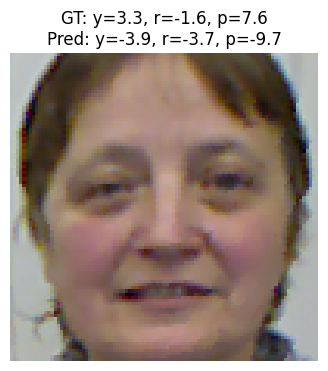

In [23]:
from torchvision import transforms
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

# Same preprocessing used in the official test script
inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def predict_single_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = inference_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        rotation_matrix = model(input_tensor)
        euler = sixd_utils.compute_euler_angles_from_rotation_matrices(rotation_matrix)
        euler_deg = euler[0].detach().cpu().numpy() * 180.0 / np.pi
    
    # Repository convention:
    # euler[:, 0] = pitch, euler[:, 1] = yaw, euler[:, 2] = roll
    pred_pitch = float(euler_deg[0])
    pred_yaw = float(euler_deg[1])
    pred_roll = float(euler_deg[2])
    
    return {
        "pred_yaw": pred_yaw,
        "pred_roll": pred_roll,
        "pred_pitch": pred_pitch,
    }

# Select one example frame
sample_row = df.iloc[0]
prediction = predict_single_image(sample_row["image_path"])

print("Single-frame inference test")
print("Image:", sample_row["image_path"])
print()

print("Ground truth:")
print(f"yaw   = {sample_row['yaw']:.2f}")
print(f"roll  = {sample_row['roll']:.2f}")
print(f"pitch = {sample_row['pitch']:.2f}")
print()

print("Prediction:")
print(f"yaw   = {prediction['pred_yaw']:.2f}")
print(f"roll  = {prediction['pred_roll']:.2f}")
print(f"pitch = {prediction['pred_pitch']:.2f}")
print()

print("Absolute angular error:")
print(f"yaw   = {angular_error_deg(prediction['pred_yaw'], sample_row['yaw']):.2f}")
print(f"roll  = {angular_error_deg(prediction['pred_roll'], sample_row['roll']):.2f}")
print(f"pitch = {angular_error_deg(prediction['pred_pitch'], sample_row['pitch']):.2f}")

# Visualize the tested frame
img = Image.open(sample_row["image_path"]).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"GT: y={sample_row['yaw']:.1f}, r={sample_row['roll']:.1f}, p={sample_row['pitch']:.1f}\n"
    f"Pred: y={prediction['pred_yaw']:.1f}, r={prediction['pred_roll']:.1f}, p={prediction['pred_pitch']:.1f}"
)
plt.show()


### 6.7 Checking angle convention alignment

Before running inference on the full BIWI-360 dataset, we verify that the model output is aligned with the BIWI-360 angle convention. This is necessary because head pose datasets and repositories may use different Euler angle orders or sign conventions.

The repository returns Euler angles in the following order:

`euler[:, 0] = pitch`, `euler[:, 1] = yaw`, `euler[:, 2] = roll`

After applying this mapping, we test whether any additional sign flip is needed. To do this, we sample **240 frames** across all BIWI-360 sequences and compare all possible sign combinations for yaw, roll and pitch.

The best result is obtained with:

`sign_yaw = +1`, `sign_roll = +1`, `sign_pitch = +1`

This means that no extra sign correction should be applied. The raw output mapping used in the previous section is already the best convention among the tested alternatives.

The sampled predictions still show large errors for some frames, including extreme outliers. However, this is not caused by a simple sign-convention mistake. Instead, these errors are part of the actual zero-shot behavior of the model under fisheye distortion, which will be evaluated more systematically in the following sections.

In [24]:
from tqdm.auto import tqdm
import itertools
import pandas as pd
import numpy as np

# Sample frames across the whole dataset to check convention alignment quickly
sample_eval_parts = []

for _, group in df.groupby("sequence_id"):
    sample_eval_parts.append(group.sample(min(len(group), 10), random_state=42))

sample_eval_df = pd.concat(sample_eval_parts).reset_index(drop=True)

print("Number of sampled frames:", len(sample_eval_df))

pred_rows = []

for _, row in tqdm(sample_eval_df.iterrows(), total=len(sample_eval_df)):
    pred = predict_single_image(row["image_path"])
    
    pred_rows.append({
        "sequence_id": row["sequence_id"],
        "frame_id": row["frame_id"],
        "gt_yaw": row["yaw"],
        "gt_roll": row["roll"],
        "gt_pitch": row["pitch"],
        "pred_yaw_raw": pred["pred_yaw"],
        "pred_roll_raw": pred["pred_roll"],
        "pred_pitch_raw": pred["pred_pitch"],
    })

convention_df = pd.DataFrame(pred_rows)

results = []

for sy, sr, sp in itertools.product([1, -1], repeat=3):
    results.append(mean_mae_for_signs(convention_df, sy=sy, sr=sr, sp=sp))

sign_results = pd.DataFrame(results).sort_values("mean_mae").reset_index(drop=True)

print("Sign convention comparison on sampled frames:")
display(sign_results)

print("\nSample predictions with raw model outputs:")
display(convention_df.head(10))


Number of sampled frames: 240


  0%|          | 0/240 [00:00<?, ?it/s]

Sign convention comparison on sampled frames:


,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,1,1,1,17.913169,22.210959,31.029293,23.717807
1,1,1,-1,17.913169,22.210959,41.967230,27.363786
2,1,-1,1,17.913169,33.793643,31.029293,27.578702
3,1,-1,-1,17.913169,33.793643,41.967230,31.224681
4,-1,1,1,48.381750,22.210959,31.029293,33.874001
5,-1,1,-1,48.381750,22.210959,41.967230,37.519979
6,-1,-1,1,48.381750,33.793643,31.029293,37.734895
7,-1,-1,-1,48.381750,33.793643,41.967230,41.380874



Sample predictions with raw model outputs:


,sequence_id,frame_id,gt_yaw,gt_roll,gt_pitch,pred_yaw_raw,pred_roll_raw,pred_pitch_raw
0,1,463,-31.972218,17.847537,-51.348841,-20.983072,8.452777,-34.629814
1,1,76,19.351829,8.534912,32.376030,-0.398311,-2.028677,-2.104806
2,1,234,47.351681,-4.116045,-1.959559,35.841503,2.887403,1.870802
3,1,178,10.137439,1.819631,10.255109,15.431098,4.674442,17.101084
4,1,240,39.711930,-3.933954,-2.544290,23.998280,4.107418,-13.424181
5,1,428,35.033410,-31.509099,-52.262954,-56.730854,-142.266083,177.015411
6,1,158,-12.308774,-2.795928,10.382256,-2.817593,-3.559524,1.084332
7,1,58,30.959831,16.883230,38.071361,33.708569,21.780138,30.355106
8,1,325,-58.149510,30.130960,-36.217105,-65.393150,-15.313673,31.947279
9,1,12,3.791450,-1.956757,7.585290,-8.933473,0.198416,-2.185977


### 6.8 Full BIWI-360 frame-by-frame inference

After confirming that no additional sign correction is needed, we run **frame-by-frame inference** on the full BIWI-360 dataset. Each image is processed independently by the pretrained 6DRepNet360 model, without using any information from neighboring frames.

This produces a zero-shot prediction table containing:

- the original BIWI-360 annotations: `yaw`, `roll`, `pitch`, `rho`, `theta`;
- the model predictions: `pred_yaw`, `pred_roll`, `pred_pitch`;
- the temporal metadata computed earlier.

The predictions are saved to:

`/kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv`

Saving the predictions avoids recomputing the full inference step every time the notebook is re-run. In this execution, inference over all **15,678 frames** takes about **45 seconds** on GPU, at roughly **345 frames per second**.

The prediction summary already suggests a potential issue: `pred_roll` and `pred_pitch` cover almost the full `[-180°, 180°]` range, even though the ground-truth roll and pitch distributions are much narrower. This indicates that the zero-shot model may produce extreme outliers under fisheye distortion.

The next sections quantify this behavior using frame-level accuracy metrics and temporal stability metrics on validation and test splits.

In [25]:
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import time
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

class BIWI360FrameDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        return image, index

# Keep a clean sorted inference table
inference_df = df.sort_values(["sequence_id", "frame_id"]).reset_index(drop=True).copy()

prediction_csv = Path("/kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv")

if prediction_csv.exists():
    print("Loading existing predictions from:", prediction_csv)
    pred_df = pd.read_csv(prediction_csv)
else:
    batch_size = 128

    inference_dataset = BIWI360FrameDataset(inference_df, inference_transform)
    inference_loader = DataLoader(
        inference_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    pred_yaw = np.zeros(len(inference_df), dtype=np.float32)
    pred_roll = np.zeros(len(inference_df), dtype=np.float32)
    pred_pitch = np.zeros(len(inference_df), dtype=np.float32)

    model.eval()
    start_time = time.time()

    with torch.no_grad():
        for images, indices in tqdm(inference_loader, desc="Running inference"):
            images = images.to(device, non_blocking=True)

            rotation_matrices = model(images)
            euler = sixd_utils.compute_euler_angles_from_rotation_matrices(rotation_matrices)
            euler_deg = euler.detach().cpu().numpy() * 180.0 / np.pi

            # Repository convention:
            # euler[:, 0] = pitch, euler[:, 1] = yaw, euler[:, 2] = roll
            indices_np = indices.numpy()
            pred_pitch[indices_np] = euler_deg[:, 0]
            pred_yaw[indices_np] = euler_deg[:, 1]
            pred_roll[indices_np] = euler_deg[:, 2]

    elapsed = time.time() - start_time

    pred_df = inference_df.copy()
    pred_df["pred_yaw"] = pred_yaw
    pred_df["pred_roll"] = pred_roll
    pred_df["pred_pitch"] = pred_pitch

    pred_df.to_csv(prediction_csv, index=False)

    print(f"Inference completed in {elapsed:.2f} seconds.")
    print(f"Average speed: {len(pred_df) / elapsed:.2f} frames/second.")
    print("Predictions saved to:", prediction_csv)

print("Prediction table shape:", pred_df.shape)

print("\nPrediction table preview:")
display(pred_df[[
    "sequence_id", "frame_id",
    "yaw", "roll", "pitch",
    "pred_yaw", "pred_roll", "pred_pitch",
    "rho", "theta"
]].head())

print("\nPrediction value summary:")
display(pred_df[["pred_yaw", "pred_roll", "pred_pitch"]].describe())


Running inference:   0%|          | 0/123 [00:00<?, ?it/s]

Inference completed in 45.40 seconds.
Average speed: 345.35 frames/second.
Predictions saved to: /kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv
Prediction table shape: (15678, 29)

Prediction table preview:


,sequence_id,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,rho,theta
0,1,3,3.290994,-1.566632,7.607223,-3.889712,-3.664212,-9.666253,0.250498,-74.249642
1,1,4,3.889411,-1.930131,7.650885,9.635563,-4.170786,2.779594,0.465149,139.762830
2,1,5,3.664672,-1.946089,7.445381,-16.904100,1.359496,3.938677,0.670615,11.398345
3,1,6,3.795917,-1.896884,7.455991,-14.823156,-4.605124,-15.515920,0.756483,-98.073602
4,1,7,3.433040,-2.123386,7.729789,0.830185,-6.454150,-8.736897,0.255294,101.986555



Prediction value summary:


,pred_yaw,pred_roll,pred_pitch
count,15678.000000,15678.000000,15678.000000
mean,-3.007759,4.919720,-5.559988
std,37.795002,47.464901,50.883129
min,-89.276627,-179.985123,-179.985504
25%,-28.806689,-6.633220,-17.649768
50%,-2.712913,0.007919,-5.165215
75%,20.828714,10.061333,6.281883
max,89.314651,179.871307,179.939056


### 6.9 Full-inference angle convention diagnostic

The full prediction summary shows very wide predicted roll and pitch values, with some predictions close to `±180°`. Before interpreting these values as model failures, we perform a final angle-convention diagnostic on the complete prediction table.

The previous convention check used a small sampled subset and only tested sign flips. Here, we test all possible assignments of predicted angles to ground-truth angles, together with all sign combinations. This allows us to check whether the poor zero-shot performance could be explained by a wrong Euler order or sign convention.

The best combination on the full BIWI-360 prediction table is the current raw mapping:

| Ground-truth angle | Prediction column | Sign |
|---|---|---|
| `yaw` | `pred_yaw` | `+1` |
| `roll` | `pred_roll` | `+1` |
| `pitch` | `pred_pitch` | `+1` |

This gives a full-dataset mean MAE of about **22.7°**, and every alternative permutation or sign combination performs worse.

Therefore, the large errors and extreme roll/pitch predictions are not caused by a simple convention mismatch. They reflect genuine zero-shot transfer problems when applying the pretrained 6DRepNet360 model to fisheye-distorted BIWI-360 images.

From this point on, we keep the raw convention unchanged and evaluate the model using:

`pred_yaw`, `pred_roll`, `pred_pitch`

In [26]:
import itertools
import numpy as np
import pandas as pd
from pathlib import Path

# Load predictions if needed
prediction_csv = Path("/kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv")
pred_df = pd.read_csv(prediction_csv)

gt_cols = ["yaw", "roll", "pitch"]
pred_cols = ["pred_yaw", "pred_roll", "pred_pitch"]

diagnostic_rows = []

for perm in itertools.permutations(pred_cols):
    for signs in itertools.product([1, -1], repeat=3):
        errors = {}
        
        for gt_col, pred_col, sign in zip(gt_cols, perm, signs):
            errors[gt_col] = angular_diff_array_deg(
                sign * pred_df[pred_col].values,
                pred_df[gt_col].values
            )
        
        mae_yaw = errors["yaw"].mean()
        mae_roll = errors["roll"].mean()
        mae_pitch = errors["pitch"].mean()
        mean_mae = np.mean([mae_yaw, mae_roll, mae_pitch])
        
        diagnostic_rows.append({
            "pred_for_yaw": perm[0],
            "pred_for_roll": perm[1],
            "pred_for_pitch": perm[2],
            "sign_yaw": signs[0],
            "sign_roll": signs[1],
            "sign_pitch": signs[2],
            "mae_yaw": mae_yaw,
            "mae_roll": mae_roll,
            "mae_pitch": mae_pitch,
            "mean_mae": mean_mae,
        })

angle_diagnostic = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("mean_mae")
    .reset_index(drop=True)
)

print("Best angle assignment and sign combinations:")
display(angle_diagnostic.head(15))

print("\nCurrent raw convention result:")
raw_result = angle_diagnostic[
    (angle_diagnostic["pred_for_yaw"] == "pred_yaw") &
    (angle_diagnostic["pred_for_roll"] == "pred_roll") &
    (angle_diagnostic["pred_for_pitch"] == "pred_pitch") &
    (angle_diagnostic["sign_yaw"] == 1) &
    (angle_diagnostic["sign_roll"] == 1) &
    (angle_diagnostic["sign_pitch"] == 1)
]
display(raw_result)


Best angle assignment and sign combinations:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,16.875613,21.278923,30.079197,22.744578
1,pred_yaw,pred_pitch,pred_roll,1,1,1,16.875613,28.999096,30.583661,25.486123
2,pred_yaw,pred_roll,pred_pitch,1,1,-1,16.875613,21.278923,40.668673,26.274403
3,pred_yaw,pred_pitch,pred_roll,1,-1,1,16.875613,31.585857,30.583661,26.348377
4,pred_yaw,pred_roll,pred_pitch,1,-1,1,16.875613,32.099427,30.079197,26.351412
5,pred_yaw,pred_pitch,pred_roll,1,1,-1,16.875613,28.999096,37.043903,27.639537
6,pred_yaw,pred_pitch,pred_roll,1,-1,-1,16.875613,31.585857,37.043903,28.501791
7,pred_yaw,pred_roll,pred_pitch,1,-1,-1,16.875613,32.099427,40.668673,29.881237
8,pred_pitch,pred_roll,pred_yaw,-1,1,-1,36.692905,21.278923,33.205354,30.392394
9,pred_pitch,pred_roll,pred_yaw,1,1,-1,39.801944,21.278923,33.205354,31.428740



Current raw convention result:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,16.875613,21.278923,30.079197,22.744578


## 7. Experimental protocol

We first evaluate the pretrained 6DRepNet360 model as a **zero-shot frame-by-frame baseline** on BIWI-360. At this stage, the model is not fine-tuned on BIWI-360; each frame is processed independently, and the goal is to measure how well a strong pretrained 6D rotation-based estimator transfers to fisheye-distorted video frames.

The previous angle-convention diagnostics showed that the raw model output is the best alignment with the BIWI-360 labels among all tested permutations and sign combinations. Therefore, the high frame-level errors observed later should be interpreted as a transfer limitation under fisheye distortion, not as a simple coordinate-convention mismatch.

Although the model itself is not trained in this zero-shot experiment, some later post-processing methods require hyperparameters. For example, temporal smoothing uses a smoothing strength, and robust filtering methods require filter choices. To avoid selecting these parameters directly on the final evaluation data, we split BIWI-360 by sequence into:

- a **validation split**, used for selecting post-processing parameters;
- a **test split**, used for final reporting.

The split is performed by **video sequence**, not by individual frames. This avoids temporal leakage: frames from the same sequence should not appear in both validation and test.

The selected validation sequences are:

`[4, 10, 16, 22]`

The remaining 20 sequences are used as test data. This gives:

- **3,049 validation frames** and **3,043 validation consecutive pairs**;
- **12,629 test frames** and **12,585 test consecutive pairs**.

This protocol is used for the zero-shot evaluation, EMA smoothing, robust temporal filtering and baseline comparisons. Later, the notebook also explores fisheye-aware adaptation using an external fisheye dataset, but the BIWI-360 test split remains reserved for final evaluation.

In [27]:
# Sequence-level validation/test split.
# We do not train the model, so there is no training split.
# The validation split is only used later to choose the smoothing hyperparameter.

all_sequences = sorted([int(seq) for seq in pred_df["sequence_id"].unique()])

# Evenly spaced validation sequences across the 24 BIWI-360 sequences
validation_sequences = [4, 10, 16, 22]
test_sequences = [seq for seq in all_sequences if seq not in validation_sequences]

pred_df["split"] = np.where(
    pred_df["sequence_id"].isin(validation_sequences),
    "validation",
    "test"
)

# Keep the split also in temporal_pairs for later temporal metrics
temporal_pairs["split"] = np.where(
    temporal_pairs["sequence_id"].isin(validation_sequences),
    "validation",
    "test"
)

print("All sequences:", all_sequences)
print("Validation sequences:", validation_sequences)
print("Test sequences:", test_sequences)

print("\nFrame counts by split:")
display(pred_df.groupby("split").size().rename("num_frames").reset_index())

print("\nConsecutive temporal-pair counts by split:")
display(temporal_pairs.groupby("split").size().rename("num_pairs").reset_index())

print("\nSequence distribution by split:")
display(
    pred_df.groupby(["split", "sequence_id"])
    .size()
    .rename("num_frames")
    .reset_index()
)


All sequences: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Validation sequences: [4, 10, 16, 22]
Test sequences: [1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 23, 24]

Frame counts by split:


,split,num_frames
0,test,12629
1,validation,3049



Consecutive temporal-pair counts by split:


,split,num_pairs
0,test,12585
1,validation,3043



Sequence distribution by split:


,split,sequence_id,num_frames
0,test,1,499
1,test,2,511
2,test,3,730
3,test,5,946
4,test,6,542
5,test,7,745
6,test,8,772
7,test,9,882
8,test,11,572
9,test,12,732


## 8. Frame-level accuracy metrics

We first evaluate the **frame-level accuracy** of the pretrained 6DRepNet360 model. At this stage, each frame is treated independently, because the model does not use temporal context.

We report two standard regression metrics for each head pose angle:

- **MAE**: mean absolute angular error;
- **RMSE**: root mean squared angular error, which penalizes large errors more strongly.

The angular error is computed using the smallest equivalent angular difference, so the periodicity of angles is handled correctly.

On the test split, the zero-shot model obtains:

| Metric | Value |
|---|---:|
| MAE yaw | ≈ 16.99° |
| MAE roll | ≈ 21.13° |
| MAE pitch | ≈ 29.66° |
| Mean MAE | ≈ 22.60° |
| Mean RMSE | ≈ 39.49° |

These results show that the pretrained model does not transfer well to BIWI-360 in a zero-shot setting. The error is especially large for **pitch** and **roll**, while **yaw** is the most reliable axis.

The test error distribution also shows a strong outlier effect. The median mean error is only about **11.77°**, but the maximum mean error reaches about **150°**, and individual roll/pitch errors can approach **180°**. This confirms that the poor average performance is not only due to moderate errors across all frames, but also to severe prediction failures on a subset of fisheye-distorted images.

These frame-level results are the first main indication that fisheye distortion creates a strong domain shift for the zero-shot 6DRepNet360 model.

In [28]:
import numpy as np
import pandas as pd

# Compute frame-level absolute angular errors
pred_df["err_yaw"] = angular_diff_array_deg(pred_df["pred_yaw"], pred_df["yaw"])
pred_df["err_roll"] = angular_diff_array_deg(pred_df["pred_roll"], pred_df["roll"])
pred_df["err_pitch"] = angular_diff_array_deg(pred_df["pred_pitch"], pred_df["pitch"])
pred_df["err_mean"] = pred_df[["err_yaw", "err_roll", "err_pitch"]].mean(axis=1)

frame_metrics = pd.DataFrame([
    summarize_frame_metrics(pred_df, "validation"),
    summarize_frame_metrics(pred_df, "test"),
])

print("Frame-level accuracy metrics:")
display(frame_metrics)

print("\nFrame-level error distribution on the test split:")
display(
    pred_df[pred_df["split"] == "test"][["err_yaw", "err_roll", "err_pitch", "err_mean"]]
    .describe()
)

# Save updated prediction table with error columns and split
updated_prediction_csv = "/kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv"
pred_df.to_csv(updated_prediction_csv, index=False)

print("\nUpdated prediction table saved to:")
print(updated_prediction_csv)


Frame-level accuracy metrics:


,split,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse_yaw,rmse_roll,rmse_pitch,mean_rmse
0,validation,3049,16.389506,21.885331,31.801848,23.358895,24.807456,44.752287,51.961620,40.507121
1,test,12629,16.992973,21.132519,29.663300,22.596264,25.984591,44.367790,48.104056,39.485479



Frame-level error distribution on the test split:


,err_yaw,err_roll,err_pitch,err_mean
count,12629.000000,12629.000000,12629.000000,12629.000000
mean,16.992973,21.132519,29.663300,22.596264
std,19.658801,39.013305,37.870864,28.792786
min,0.004771,0.001313,0.000009,0.338190
25%,4.688813,2.343530,7.874538,6.880685
50%,10.424165,5.541516,16.928966,11.774267
75%,20.669256,15.581273,30.760041,21.847122
max,147.080120,179.985586,179.984514,150.254814



Updated prediction table saved to:
/kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv


## 9. Temporal stability metrics for raw predictions

The previous section evaluated the model independently on each frame. We now evaluate **temporal stability** by comparing predictions across true consecutive frame pairs, where `frame_gap = 1`.

For each consecutive pair, we compute:

| Quantity | Meaning |
|---|---|
| Ground-truth motion | Real angular change between two adjacent frames |
| Predicted motion | Change in the model prediction between the same frames |
| Prediction jitter | Magnitude of the predicted frame-to-frame change |
| Temporal motion error | Difference between predicted motion and ground-truth motion |

This analysis is important because a frame-by-frame model can be accurate on some individual frames but still behave unstably over time. In a video sequence, if the real head pose changes only slightly between adjacent frames, the predictions should also change smoothly.

The raw zero-shot predictions are highly unstable. On the test split, the average real head motion is only about **2.07° per frame**, but the average prediction jitter is about **44.27° per frame**. The temporal motion error is also about **44.27°**, showing that the predicted changes are much larger than the true motion.

This means that the pretrained model is not only inaccurate at frame level under fisheye distortion, but also temporally inconsistent. The model often produces large jumps between adjacent frames even when the actual head pose changes smoothly.

The grouped analysis shows that jitter is larger in high-motion regions, but it remains very high even in low-motion regions:

- low-motion pairs: prediction jitter ≈ **40.10°**;
- medium-motion pairs: prediction jitter ≈ **53.82°**;
- high-motion pairs: prediction jitter ≈ **60.43°**.

The fisheye-change grouping also shows slightly higher jitter when the distortion metadata changes strongly. However, even low fisheye-change pairs still have very large jitter. This suggests that the raw instability is not caused by a single factor, but by the combination of frame-wise inference, fisheye domain shift and extreme prediction outliers.

These results motivate the next step: applying temporal post-processing to reduce prediction jitter.

In [29]:
import numpy as np
import pandas as pd

# Sort predictions temporally
pred_df = pred_df.sort_values(["sequence_id", "frame_id"]).reset_index(drop=True).copy()

# Previous frame information
pred_df["prev_frame_id_eval"] = pred_df.groupby("sequence_id")["frame_id"].shift(1)
pred_df["frame_gap_eval"] = pred_df["frame_id"] - pred_df["prev_frame_id_eval"]
pred_df["is_consecutive_pair_eval"] = pred_df["frame_gap_eval"] == 1

# Previous GT and prediction values
for col in ["yaw", "roll", "pitch", "pred_yaw", "pred_roll", "pred_pitch", "rho", "theta"]:
    pred_df[f"prev_{col}"] = pred_df.groupby("sequence_id")[col].shift(1)

# Keep only true consecutive frame pairs
raw_temporal_df = pred_df[pred_df["is_consecutive_pair_eval"]].copy().reset_index(drop=True)

# Ground-truth and predicted signed angular changes
for angle in ["yaw", "roll", "pitch"]:
    raw_temporal_df[f"gt_delta_{angle}"] = signed_circular_diff_deg(
        raw_temporal_df[angle],
        raw_temporal_df[f"prev_{angle}"]
    )
    
    raw_temporal_df[f"pred_delta_{angle}"] = signed_circular_diff_deg(
        raw_temporal_df[f"pred_{angle}"],
        raw_temporal_df[f"prev_pred_{angle}"]
    )
    
    raw_temporal_df[f"pred_jitter_{angle}"] = np.abs(raw_temporal_df[f"pred_delta_{angle}"])
    raw_temporal_df[f"temporal_error_{angle}"] = np.abs(
        raw_temporal_df[f"pred_delta_{angle}"] - raw_temporal_df[f"gt_delta_{angle}"]
    )

# Magnitudes over yaw, roll, pitch
raw_temporal_df["gt_motion_magnitude_eval"] = np.sqrt(
    raw_temporal_df["gt_delta_yaw"] ** 2 +
    raw_temporal_df["gt_delta_roll"] ** 2 +
    raw_temporal_df["gt_delta_pitch"] ** 2
)

raw_temporal_df["pred_jitter_magnitude"] = np.sqrt(
    raw_temporal_df["pred_delta_yaw"] ** 2 +
    raw_temporal_df["pred_delta_roll"] ** 2 +
    raw_temporal_df["pred_delta_pitch"] ** 2
)

raw_temporal_df["temporal_motion_error_magnitude"] = np.sqrt(
    raw_temporal_df["temporal_error_yaw"] ** 2 +
    raw_temporal_df["temporal_error_roll"] ** 2 +
    raw_temporal_df["temporal_error_pitch"] ** 2
)

# Fisheye metadata change for analysis
raw_temporal_df["delta_rho"] = raw_temporal_df["rho"] - raw_temporal_df["prev_rho"]
raw_temporal_df["abs_delta_rho"] = raw_temporal_df["delta_rho"].abs()

raw_temporal_df["delta_theta_circular"] = signed_circular_diff_deg(
    raw_temporal_df["theta"],
    raw_temporal_df["prev_theta"]
)
raw_temporal_df["abs_delta_theta_circular"] = raw_temporal_df["delta_theta_circular"].abs()

raw_temporal_df["fisheye_change"] = np.sqrt(
    (raw_temporal_df["abs_delta_rho"] / 0.8) ** 2 +
    (raw_temporal_df["abs_delta_theta_circular"] / 180.0) ** 2
)

# Assign motion and fisheye-change levels using the same quantile idea
motion_q75 = raw_temporal_df["gt_motion_magnitude_eval"].quantile(0.75)
motion_q90 = raw_temporal_df["gt_motion_magnitude_eval"].quantile(0.90)

fisheye_q75 = raw_temporal_df["fisheye_change"].quantile(0.75)
fisheye_q90 = raw_temporal_df["fisheye_change"].quantile(0.90)

raw_temporal_df["motion_level"] = raw_temporal_df["gt_motion_magnitude_eval"].apply(
    lambda x: assign_level(x, motion_q75, motion_q90)
)

raw_temporal_df["fisheye_change_level"] = raw_temporal_df["fisheye_change"].apply(
    lambda x: assign_level(x, fisheye_q75, fisheye_q90)
)

print("Number of true consecutive temporal pairs:", len(raw_temporal_df))

print("\nTemporal thresholds:")
print(f"Motion q75: {motion_q75:.3f}")
print(f"Motion q90: {motion_q90:.3f}")
print(f"Fisheye-change q75: {fisheye_q75:.3f}")
print(f"Fisheye-change q90: {fisheye_q90:.3f}")

raw_temporal_metrics = pd.DataFrame([
    summarize_temporal_metrics(raw_temporal_df, "validation"),
    summarize_temporal_metrics(raw_temporal_df, "test"),
])

print("\nRaw temporal stability metrics:")
display(raw_temporal_metrics)

print("\nRaw temporal metrics by motion level on the test split:")
display(
    raw_temporal_df[raw_temporal_df["split"] == "test"]
    .groupby("motion_level")
    .agg(
        num_pairs=("frame_id", "count"),
        mean_gt_motion=("gt_motion_magnitude_eval", "mean"),
        mean_pred_jitter=("pred_jitter_magnitude", "mean"),
        mean_temporal_motion_error=("temporal_motion_error_magnitude", "mean"),
    )
    .reset_index()
)

print("\nRaw temporal metrics by fisheye-change level on the test split:")
display(
    raw_temporal_df[raw_temporal_df["split"] == "test"]
    .groupby("fisheye_change_level")
    .agg(
        num_pairs=("frame_id", "count"),
        mean_fisheye_change=("fisheye_change", "mean"),
        mean_pred_jitter=("pred_jitter_magnitude", "mean"),
        mean_temporal_motion_error=("temporal_motion_error_magnitude", "mean"),
    )
    .reset_index()
)


Number of true consecutive temporal pairs: 15628

Temporal thresholds:
Motion q75: 2.535
Motion q90: 3.914
Fisheye-change q75: 0.867
Fisheye-change q90: 0.996

Raw temporal stability metrics:


,split,num_pairs,mean_gt_motion,mean_pred_jitter,mean_temporal_motion_error,jitter_yaw,jitter_roll,jitter_pitch,temporal_error_yaw,temporal_error_roll,temporal_error_pitch
0,validation,3043,1.970591,46.223222,46.179548,18.166867,23.790126,29.104040,18.121980,23.774832,29.098326
1,test,12585,2.067324,44.273643,44.272610,18.044373,23.178325,26.628358,17.980129,23.214268,26.660763



Raw temporal metrics by motion level on the test split:


,motion_level,num_pairs,mean_gt_motion,mean_pred_jitter,mean_temporal_motion_error
0,high,1293,5.966938,60.432561,60.542117
1,low,9383,1.318549,40.103852,40.099157
2,medium,1909,3.106378,53.824018,53.766078



Raw temporal metrics by fisheye-change level on the test split:


,fisheye_change_level,num_pairs,mean_fisheye_change,mean_pred_jitter,mean_temporal_motion_error
0,high,1269,1.085865,49.564813,49.522650
1,low,9418,0.537099,43.508640,43.503529
2,medium,1898,0.929675,44.531970,44.578669


## 10. Temporal post-processing with exponential moving average

The raw frame-by-frame predictions show severe temporal jitter. We now apply a simple temporal post-processing method: **exponential moving average** (EMA).

EMA updates the prediction at time `t` as:

`smoothed_t = alpha * raw_t + (1 - alpha) * smoothed_{t-1}`

A smaller `alpha` produces stronger smoothing and makes the output change more slowly. A larger `alpha` keeps the result closer to the raw frame-by-frame prediction.

We select `alpha` using only the validation sequences. However, selecting the value that minimizes temporal motion error alone would be misleading. Since the true head motion is usually only a few degrees per frame, very strong smoothing tends to push predicted motion toward zero and can reduce temporal error even when frame-level accuracy becomes worse.

For this reason, we use a balanced validation criterion that combines:

- the smoothed frame-level MAE, normalized by the raw validation MAE;
- the smoothed temporal motion error, normalized by the raw validation temporal error.

This criterion selects a compromise between accuracy and stability.

The alpha sweep shows this trade-off clearly. The strongest smoothing, `alpha = 0.05`, gives the lowest temporal motion error, but it severely worsens frame-level MAE on validation. The balanced criterion instead selects:

`alpha = 0.20`

With this value, EMA substantially reduces temporal jitter while also improving the Euler-angle MAE compared with the raw zero-shot predictions. On the test split, the smoothed predictions reach approximately:

| Metric | Raw | EMA, alpha = 0.20 |
|---|---:|---:|
| Mean MAE | ≈ 22.60° | ≈ 19.94° |
| Mean jitter | ≈ 44.27°/frame | ≈ 9.22°/frame |
| Temporal motion error | ≈ 44.27°/frame | ≈ 9.29°/frame |

This shows that EMA is useful as a temporal denoising step. However, it is still only a post-processing method: it does not change the model or solve the underlying fisheye domain shift. Later sections will test whether more robust filtering and fisheye-aware adaptation can improve further.

In [30]:
import numpy as np
import pandas as pd

candidate_alphas = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]
smoothing_results = []

for alpha in candidate_alphas:
    smoothed_df = smooth_predictions_by_sequence(pred_df, alpha=alpha)
    smoothed_df = compute_smoothed_frame_errors(smoothed_df)

    smoothed_temporal_df = compute_temporal_metrics_for_prediction_columns(
        smoothed_df,
        pred_prefix="smooth_pred"
    )

    smoothing_results.append(
        summarize_smoothed_metrics(smoothed_df, smoothed_temporal_df, alpha, "validation")
    )
    smoothing_results.append(
        summarize_smoothed_metrics(smoothed_df, smoothed_temporal_df, alpha, "test")
    )

smoothing_results_df = pd.DataFrame(smoothing_results)

print("EMA smoothing results (full alpha sweep):")
display(smoothing_results_df)

# --- Alpha selection ---------------------------------------------------------
# Minimising temporal motion error alone is degenerate (it always favours the
# strongest smoothing, because GT motion is only a few degrees per frame). We
# show that choice, then select alpha by a balanced validation criterion:
#   balanced_score = (smooth_mae / raw_val_mae) + (temporal_error / raw_val_temporal_error)
raw_val_mae = float(
    frame_metrics.loc[frame_metrics["split"] == "validation", "mean_mae"].iloc[0]
)
raw_val_temporal_error = float(
    raw_temporal_df.loc[raw_temporal_df["split"] == "validation",
                        "temporal_motion_error_magnitude"].mean()
)

validation_results = smoothing_results_df[smoothing_results_df["split"] == "validation"].copy()
validation_results["balanced_score"] = (
    validation_results["smooth_mean_mae"] / raw_val_mae +
    validation_results["smooth_mean_temporal_motion_error"] / raw_val_temporal_error
)

degenerate_alpha = float(
    validation_results.sort_values("smooth_mean_temporal_motion_error").iloc[0]["alpha"]
)
validation_results = validation_results.sort_values("balanced_score").reset_index(drop=True)
best_alpha = float(validation_results.iloc[0]["alpha"])

print("\nAlpha minimising temporal motion error alone (degenerate choice):", degenerate_alpha)
print("Alpha selected by the balanced validation criterion:", best_alpha)

print("\nValidation results sorted by balanced score:")
display(validation_results)


EMA smoothing results (full alpha sweep):


,alpha,split,num_frames,num_pairs,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,smooth_mean_jitter,smooth_mean_temporal_motion_error
0,0.05,validation,3049,3039,16.440476,31.269845,47.858935,31.856419,5.916312,6.436632
1,0.05,test,12629,12565,17.729794,26.357604,35.652063,26.579820,4.092073,4.594871
2,0.10,validation,3049,3039,13.888574,24.567120,38.179171,25.544955,7.810029,8.104319
3,0.10,test,12629,12565,14.482017,21.003332,30.110014,21.865121,5.866798,6.110942
4,0.20,validation,3049,3039,12.839133,21.014418,33.070133,22.307894,11.104378,11.184436
5,0.20,test,12629,12565,13.414557,18.930861,27.463568,19.936329,9.223032,9.291907
6,0.30,validation,3049,3039,12.830188,20.099677,31.321034,21.416966,14.563846,14.567065
7,0.30,test,12629,12565,13.469331,18.661341,26.945568,19.692080,12.767041,12.783467
8,0.50,validation,3049,3039,13.388551,19.980726,30.545340,21.304872,22.187513,22.139953
9,0.50,test,12629,12565,14.118045,19.008754,27.255049,20.127282,20.447187,20.443005



Alpha minimising temporal motion error alone (degenerate choice): 0.05
Alpha selected by the balanced validation criterion: 0.2

Validation results sorted by balanced score:


,alpha,split,num_frames,num_pairs,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,smooth_mean_jitter,smooth_mean_temporal_motion_error,balanced_score
0,0.20,validation,3049,3039,12.839133,21.014418,33.070133,22.307894,11.104378,11.184436,1.197201
1,0.30,validation,3049,3039,12.830188,20.099677,31.321034,21.416966,14.563846,14.567065,1.232310
2,0.10,validation,3049,3039,13.888574,24.567120,38.179171,25.544955,7.810029,8.104319,1.269082
3,0.50,validation,3049,3039,13.388551,19.980726,30.545340,21.304872,22.187513,22.139953,1.391499
4,0.05,validation,3049,3039,16.440476,31.269845,47.858935,31.856419,5.916312,6.436632,1.503164
5,0.70,validation,3049,3039,14.317052,20.456931,30.809417,21.861133,30.803051,30.741494,1.601575
6,0.90,validation,3049,3039,15.580183,21.269221,31.399881,22.749762,40.667735,40.613975,1.853403


### 10.1 Raw versus smoothed predictions

We now apply the selected EMA parameter, `alpha = 0.20`, to all sequences and compare the raw frame-by-frame predictions with the smoothed predictions on both validation and test splits.

The results confirm that the balanced smoothing strategy improves both frame-level accuracy and temporal stability. On the test split, the mean MAE decreases from approximately **22.60°** to **19.94°**, an improvement of about **2.66°**. The improvement is visible in all three axes, especially in yaw and roll.

The temporal improvement is much larger. The mean prediction jitter decreases from approximately **44.27°/frame** to **9.22°/frame**, which corresponds to a reduction of about **79.2%**. The temporal motion error shows a similar reduction, from approximately **44.27°/frame** to **9.29°/frame**.

| Metric on test | Raw predictions | EMA, alpha = 0.20 |
|---|---:|---:|
| Mean MAE | ≈ 22.60° | ≈ 19.94° |
| Mean jitter | ≈ 44.27°/frame | ≈ 9.22°/frame |
| Temporal motion error | ≈ 44.27°/frame | ≈ 9.29°/frame |

This shows that EMA is useful for reducing the strong frame-to-frame instability produced by the zero-shot model. In this case, moderate smoothing also improves the Euler-angle MAE, probably because it suppresses part of the prediction noise caused by the independently changing fisheye distortion.

However, this result should be interpreted carefully. EMA is only a temporal post-processing step: it does not make the model understand fisheye geometry. It can reduce jitter and average out noisy predictions, but it cannot fully correct systematic pose errors or extreme failures caused by the fisheye domain shift.

In [31]:
# Apply the selected EMA smoothing parameter
final_smoothed_df = smooth_predictions_by_sequence(pred_df, alpha=best_alpha)
final_smoothed_df = compute_smoothed_frame_errors(final_smoothed_df)

final_smoothed_temporal_df = compute_temporal_metrics_for_prediction_columns(
    final_smoothed_df,
    pred_prefix="smooth_pred"
)

frame_raw_vs_smooth = pd.DataFrame([
    summarize_raw_vs_smooth_frame(final_smoothed_df, "validation"),
    summarize_raw_vs_smooth_frame(final_smoothed_df, "test"),
])

temporal_raw_vs_smooth = pd.DataFrame([
    summarize_raw_vs_smooth_temporal(raw_temporal_df, final_smoothed_temporal_df, "validation"),
    summarize_raw_vs_smooth_temporal(raw_temporal_df, final_smoothed_temporal_df, "test"),
])

print("Frame-level raw vs smoothed comparison:")
display(frame_raw_vs_smooth)

print("\nTemporal raw vs smoothed comparison:")
display(temporal_raw_vs_smooth)

# Save final table
final_output_csv = "/kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv"
final_smoothed_df.to_csv(final_output_csv, index=False)

print("\nFinal prediction table saved to:")
print(final_output_csv)


Frame-level raw vs smoothed comparison:


,split,num_frames,raw_mae_yaw,raw_mae_roll,raw_mae_pitch,raw_mean_mae,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,delta_mean_mae
0,validation,3049,16.389506,21.885331,31.801848,23.358895,12.839133,21.014418,33.070133,22.307894,-1.051001
1,test,12629,16.992973,21.132519,29.663300,22.596264,13.414557,18.930861,27.463568,19.936329,-2.659935



Temporal raw vs smoothed comparison:


,split,num_pairs_raw,num_pairs_smooth,raw_mean_jitter,smooth_mean_jitter,delta_jitter,jitter_reduction_percent,raw_temporal_motion_error,smooth_temporal_motion_error,delta_temporal_motion_error,temporal_error_reduction_percent
0,validation,3043,3039,46.223222,11.104378,-35.118844,75.976626,46.179548,11.184436,-34.995112,75.780543
1,test,12585,12565,44.273643,9.223032,-35.050611,79.168120,44.272610,9.291907,-34.980702,79.012063



Final prediction table saved to:
/kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv


### 10.2 Geodesic SO(3) rotation error

6DRepNet360 predicts a **rotation matrix** and is trained with a geodesic loss on SO(3). For this reason, Euler-angle MAE is useful but incomplete: yaw, roll and pitch are easy to interpret, but they are not the most faithful way to measure the error between two 3D rotations.

We therefore also compute the **geodesic rotation error**, defined as the angle of the relative rotation between the predicted orientation and the ground-truth orientation. This metric is bounded between `0°` and `180°` and directly measures the difference between two rotations.

To compute it, we rebuild rotation matrices from both the predicted and ground-truth Euler angles using the same convention as the 6DRepNet360 repository:

`R = Rz(roll) @ Ry(yaw) @ Rx(pitch)`

This avoids re-running inference and gives a rotation-level metric that complements the per-axis Euler errors.

The frame-level results show an important distinction. On the test split, the raw Euler mean MAE is about **22.6°**, while the raw mean geodesic error is about **33.2°**. This means that averaging yaw, roll and pitch errors can understate the full 3D rotation error, because errors on different axes combine into a single orientation mismatch.

EMA smoothing improves the Euler mean MAE, from about **22.6°** to **19.9°**, but the mean geodesic error remains almost unchanged, from about **33.2°** to **33.5°**. This suggests that part of EMA's apparent frame-level improvement comes from per-axis averaging rather than from a clearly better 3D orientation estimate.

For temporal stability, the geodesic metric gives a more bounded interpretation of jitter. On the test split, raw Euler L2 jitter is about **44.3°/frame**, while raw geodesic jitter is about **30.2°/frame**. After EMA, geodesic jitter drops to about **7.8°/frame**. Therefore, EMA genuinely reduces temporal rotation jumps, even if it does not substantially improve the mean frame-level SO(3) error.

Overall, the geodesic analysis confirms that the zero-shot failures are real rotation errors, not just artifacts of Euler-angle reporting. It also clarifies the role of EMA: smoothing is effective for temporal denoising, but it does not fully correct the underlying fisheye-induced pose estimation errors.

In [32]:
# Frame-level geodesic error for raw and EMA-smoothed predictions
final_smoothed_df = add_geodesic_frame_error(final_smoothed_df, pred_prefix="pred", out_col="geo_err_raw")
final_smoothed_df = add_geodesic_frame_error(final_smoothed_df, pred_prefix="smooth_pred", out_col="geo_err_smooth")

def geodesic_frame_summary(df, split):
    s = df[df["split"] == split]
    return {
        "split": split,
        "num_frames": len(s),
        "euler_mean_mae": s["err_mean"].mean(),
        "geo_mean_raw": s["geo_err_raw"].mean(),
        "geo_median_raw": s["geo_err_raw"].median(),
        "geo_mean_smooth": s["geo_err_smooth"].mean(),
        "geo_median_smooth": s["geo_err_smooth"].median(),
    }

geo_frame = pd.DataFrame([
    geodesic_frame_summary(final_smoothed_df, "validation"),
    geodesic_frame_summary(final_smoothed_df, "test"),
])
print("Frame-level geodesic error vs Euler MAE (degrees):")
display(geo_frame)

# Temporal geodesic jitter (bounded to <=180, unlike the Euler L2 jitter)
raw_temporal_geo = add_geodesic_temporal_columns(raw_temporal_df, pred_prefix="pred")
smooth_temporal_geo = add_geodesic_temporal_columns(final_smoothed_temporal_df, pred_prefix="smooth_pred")

def geodesic_temporal_summary(raw_t, smooth_t, split):
    r = raw_t[raw_t["split"] == split]
    s = smooth_t[smooth_t["split"] == split]
    return {
        "split": split,
        "geo_gt_motion": r["geo_gt_motion"].mean(),
        "euler_raw_jitter": r["pred_jitter_magnitude"].mean(),
        "geo_raw_jitter": r["geo_jitter"].mean(),
        "euler_smooth_jitter": s["smooth_pred_jitter_magnitude"].mean(),
        "geo_smooth_jitter": s["geo_jitter"].mean(),
    }

geo_temporal = pd.DataFrame([
    geodesic_temporal_summary(raw_temporal_geo, smooth_temporal_geo, "validation"),
    geodesic_temporal_summary(raw_temporal_geo, smooth_temporal_geo, "test"),
])
print("\nTemporal jitter: Euler L2 magnitude vs geodesic SO(3) angle (degrees):")
display(geo_temporal)


Frame-level geodesic error vs Euler MAE (degrees):


,split,num_frames,euler_mean_mae,geo_mean_raw,geo_median_raw,geo_mean_smooth,geo_median_smooth
0,validation,3049,23.358895,33.819628,21.138838,37.538192,20.542854
1,test,12629,22.596264,33.190013,22.442778,33.545651,21.862903



Temporal jitter: Euler L2 magnitude vs geodesic SO(3) angle (degrees):


,split,geo_gt_motion,euler_raw_jitter,geo_raw_jitter,euler_smooth_jitter,geo_smooth_jitter
0,validation,1.751246,46.223222,31.451088,11.104378,9.567291
1,test,1.828899,44.273643,30.243341,9.223032,7.807173


### 10.3 Visualizing raw and smoothed temporal trajectories

We now visualize the effect of EMA smoothing on a representative test sequence. The plots compare the ground-truth trajectory, the raw frame-by-frame predictions and the smoothed predictions for **yaw**, **roll** and **pitch**.

Sequence 01 illustrates the main behavior observed in the quantitative metrics. The raw predictions are very noisy and contain abrupt spikes, especially in **roll** and **pitch**, where some predictions jump close to the `±180°` range. These jumps are not present in the ground truth and are a clear visual example of the temporal jitter measured in the previous sections.

The smoothed predictions are much more stable. EMA removes many of the isolated spikes and produces trajectories that are easier to interpret over time. For **yaw**, the smoothed prediction follows the global trend of the ground truth reasonably well, although it can slightly lag behind during faster rotations. For **roll** and **pitch**, smoothing reduces extreme jumps but does not fully correct the systematic errors of the zero-shot model.

This visualization reinforces the main interpretation of EMA:

- it is effective at reducing temporal jitter;
- it can improve the average Euler-angle MAE by denoising unstable predictions;
- it may introduce some lag during faster changes;
- it cannot fully solve wrong pose estimates caused by fisheye distortion.

Therefore, EMA is useful as a post-processing baseline, but it should not be interpreted as a complete solution to the fisheye domain shift.

Visualizing sequence 01
Number of frames: 499


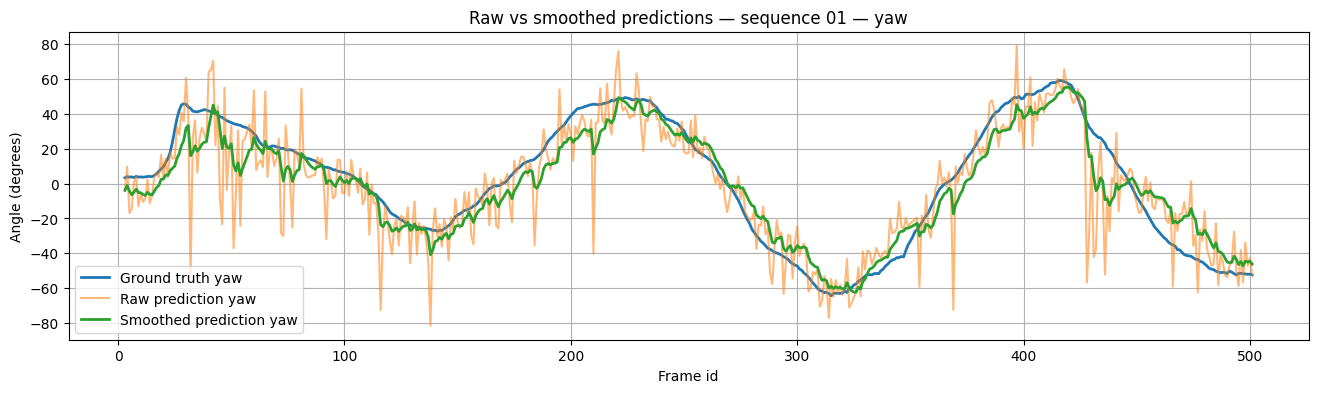

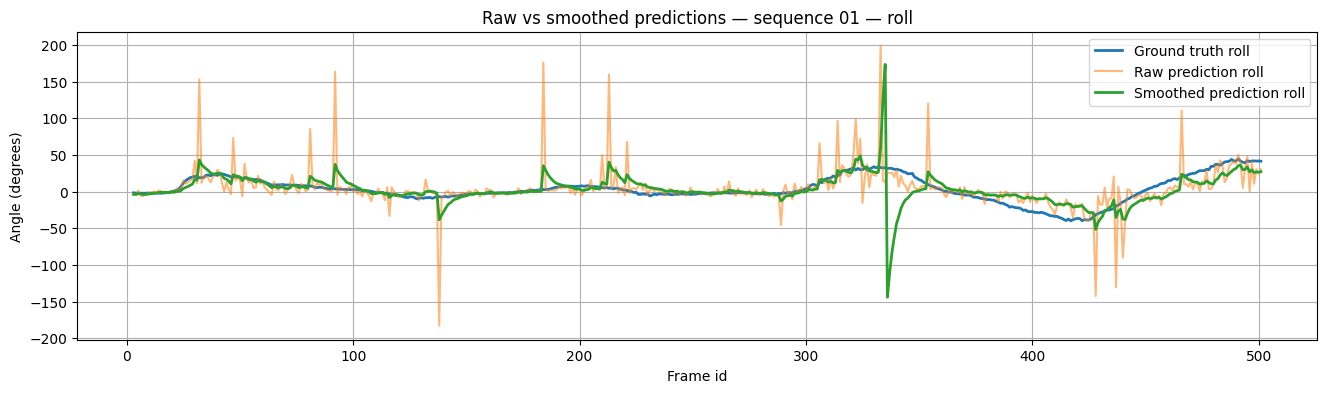

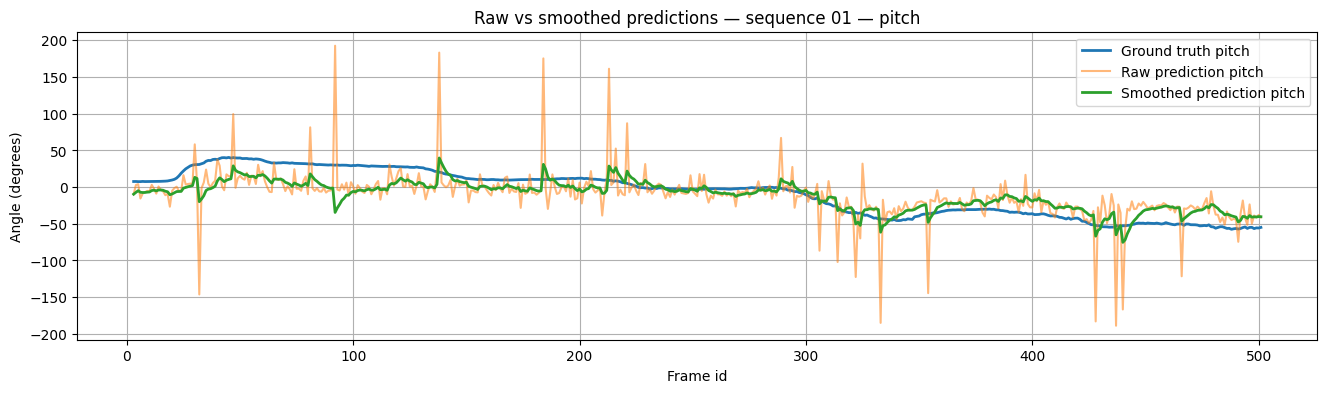

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Choose a representative test sequence
plot_sequence_id = 1

plot_df = (
    final_smoothed_df[final_smoothed_df["sequence_id"] == plot_sequence_id]
    .sort_values("frame_id")
    .reset_index(drop=True)
)

print(f"Visualizing sequence {plot_sequence_id:02d}")
print("Number of frames:", len(plot_df))

for angle in ["yaw", "roll", "pitch"]:
    gt_values = plot_df[angle].values
    raw_values = align_angle_series_to_reference(
        plot_df[f"pred_{angle}"].values,
        gt_values
    )
    smooth_values = align_angle_series_to_reference(
        plot_df[f"smooth_pred_{angle}"].values,
        gt_values
    )
    
    plt.figure(figsize=(16, 4))
    
    plt.plot(
        plot_df["frame_id"],
        gt_values,
        label=f"Ground truth {angle}",
        linewidth=2
    )
    
    plt.plot(
        plot_df["frame_id"],
        raw_values,
        label=f"Raw prediction {angle}",
        alpha=0.55
    )
    
    plt.plot(
        plot_df["frame_id"],
        smooth_values,
        label=f"Smoothed prediction {angle}",
        linewidth=2
    )
    
    plt.xlabel("Frame id")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Raw vs smoothed predictions — sequence {plot_sequence_id:02d} — {angle}")
    plt.legend()
    plt.grid(True)
    plt.show()


### 10.4 Raw versus smoothed temporal metrics by difficulty regime

We now compare the temporal behavior of raw and smoothed predictions under different difficulty regimes. These regimes are defined using two factors:

- the ground-truth motion magnitude, which measures how much the real head pose changes;
- the fisheye-change magnitude, which measures how much the distortion metadata changes between adjacent frames.

This analysis helps determine whether EMA is useful only in easy regions or whether it also helps under more challenging temporal conditions.

The results show that EMA consistently reduces prediction jitter across all motion levels. On the test split, the jitter reduction is approximately:

| Motion level | Raw jitter | Smoothed jitter | Reduction |
|---|---:|---:|---:|
| Low motion | ≈ 40.14° | ≈ 7.98° | ≈ 80.1% |
| Medium motion | ≈ 53.85° | ≈ 11.61° | ≈ 78.4% |
| High motion | ≈ 60.43° | ≈ 14.69° | ≈ 75.7% |

The same pattern appears when grouping by fisheye-change level. EMA reduces jitter by about **79–80%** in low, medium and high fisheye-change regions. This means that smoothing is not only helping in easy cases; it also reduces instability when the fisheye metadata changes strongly between frames.

However, the smoothed jitter remains higher in high-motion regions than in low-motion regions. This is expected: when the real head pose changes faster, a smoothed prediction must follow a more difficult trajectory and may also introduce some temporal lag.

Overall, this regime-based analysis confirms that EMA is a robust temporal denoising baseline. It strongly reduces jitter across different conditions, but it does not eliminate the underlying difficulty of high-motion or high-distortion-change frames.

In [34]:
# Attach motion and fisheye-change levels from the raw temporal table
# to the smoothed temporal table using the same consecutive pair identifier.

level_columns = [
    "sequence_id",
    "frame_id",
    "motion_level",
    "fisheye_change_level",
    "gt_motion_magnitude_eval",
    "fisheye_change"
]

levels_for_merge = raw_temporal_df[level_columns].copy()

smooth_temporal_with_levels = final_smoothed_temporal_df.merge(
    levels_for_merge,
    on=["sequence_id", "frame_id"],
    how="inner"
)

raw_temporal_for_comparison = raw_temporal_df.merge(
    smooth_temporal_with_levels[["sequence_id", "frame_id"]],
    on=["sequence_id", "frame_id"],
    how="inner"
)

print("Raw temporal pairs used for comparison:", len(raw_temporal_for_comparison))
print("Smoothed temporal pairs used for comparison:", len(smooth_temporal_with_levels))

motion_regime_comparison_test = compare_temporal_by_group(
    raw_temporal_for_comparison,
    smooth_temporal_with_levels,
    group_col="motion_level",
    split_name="test"
)

fisheye_regime_comparison_test = compare_temporal_by_group(
    raw_temporal_for_comparison,
    smooth_temporal_with_levels,
    group_col="fisheye_change_level",
    split_name="test"
)

print("Raw vs smoothed temporal metrics by motion level — test split:")
display(motion_regime_comparison_test)

print("\nRaw vs smoothed temporal metrics by fisheye-change level — test split:")
display(fisheye_regime_comparison_test)


Raw temporal pairs used for comparison: 15604
Smoothed temporal pairs used for comparison: 15604
Raw vs smoothed temporal metrics by motion level — test split:


,motion_level,num_pairs,raw_mean_gt_motion,raw_mean_jitter,raw_temporal_motion_error,smooth_mean_jitter,smooth_temporal_motion_error,jitter_reduction_percent,temporal_error_reduction_percent,split
0,high,1293,5.966938,60.432561,60.542117,14.694023,15.413037,75.685254,74.541628,test
1,low,9364,1.320024,40.144778,40.139727,7.980894,7.970871,80.119720,80.142188,test
2,medium,1908,3.106619,53.850748,53.791608,11.611599,11.627106,78.437441,78.384907,test



Raw vs smoothed temporal metrics by fisheye-change level — test split:


,fisheye_change_level,num_pairs,raw_mean_gt_motion,raw_mean_jitter,raw_temporal_motion_error,smooth_mean_jitter,smooth_temporal_motion_error,jitter_reduction_percent,temporal_error_reduction_percent,split
0,high,1269,2.047047,49.564813,49.522650,9.736449,9.796627,80.356126,80.217887,test
1,low,9401,2.061711,43.552209,43.546489,9.161920,9.212369,78.963363,78.844750,test
2,medium,1895,2.123238,44.575285,44.622146,9.182392,9.348507,79.400262,79.049626,test


## 11. Failure analysis

The visual inspection of the worst test frames confirms the main failure modes suggested by the quantitative evaluation.

First, the largest errors often appear in frames with **strong fisheye distortion**, especially when the face is pushed towards peripheral image regions or when the transformation introduces visible **black warped areas**. In these cases, the facial geometry differs strongly from the perspective images on which the pretrained model was trained, making zero-shot transfer much harder.

Second, several of the worst examples correspond to **large pose estimation failures**, where the model predicts roll and pitch values close to `±180°` even though the ground-truth pose is much more moderate. This indicates that the model sometimes collapses to an incorrect orientation under severe distortion, rather than making only a small local error.

Third, many failure cases involve **side views or strongly tilted heads**, which are already difficult poses and become even more challenging after fisheye warping. This suggests that the combination of extreme appearance changes and out-of-distribution geometry is a major source of error.

The smoothed predictions are usually less extreme than the raw frame-by-frame outputs, but they still remain far from the ground truth in the hardest cases. Therefore, EMA helps reduce temporal instability, but it cannot correct large frame-level mistakes when the underlying per-frame prediction is fundamentally wrong.

Overall, the failure analysis shows that the main limitation is not only temporal jitter, but also **poor robustness of the pretrained perspective-based model to severe fisheye distortions and extreme pose configurations**.

Worst frame-level prediction errors on the test split:


,sequence_id,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,smooth_pred_yaw,smooth_pred_roll,smooth_pred_pitch,err_yaw,err_roll,err_pitch,err_mean,rho,theta
5998,9,512,53.874055,6.076503,16.725867,-70.876396,154.25322,-165.43686,0.904999,29.568878,-23.917419,124.750451,148.176717,177.837273,150.254814,0.482496,-85.453781
15637,24,534,14.971824,-4.028159,6.872905,-74.167760,176.19992,-168.28963,-17.104034,-36.744308,-34.816940,89.139584,179.771921,175.162535,148.024680,0.764363,88.145918
8856,13,458,65.697734,-14.164451,-2.924440,-24.145378,161.19873,-179.78734,33.046265,8.325348,-69.566833,89.843112,175.363181,176.862900,147.356398,0.787802,105.030581
13012,20,260,25.871164,-2.158364,32.035123,-81.230270,164.13070,-162.92656,-44.153473,43.430054,-37.721710,107.101434,166.289064,165.038317,146.142938,0.026026,-80.254180
6232,9,746,44.697928,-15.289349,-26.799036,-70.539070,179.87130,179.38560,13.183151,-42.659607,-54.365112,115.236998,164.839351,153.815364,144.630571,0.794175,-71.966720
7494,11,400,27.597994,-1.569234,6.479314,-51.126816,174.05353,-174.37563,5.095856,33.431885,-38.404846,78.724810,175.622764,179.145056,144.497543,0.752066,91.713675
7334,11,240,44.975228,9.912768,24.229610,-37.337852,-176.06473,-167.56093,-0.188843,87.133057,6.470825,82.313080,174.022502,168.209460,141.515014,0.555003,77.461124
9918,15,235,64.012936,26.642886,41.764675,-58.325558,154.30006,-144.19913,-12.235184,114.891083,-143.389465,122.338494,127.657174,174.036195,141.343954,0.086545,133.379167


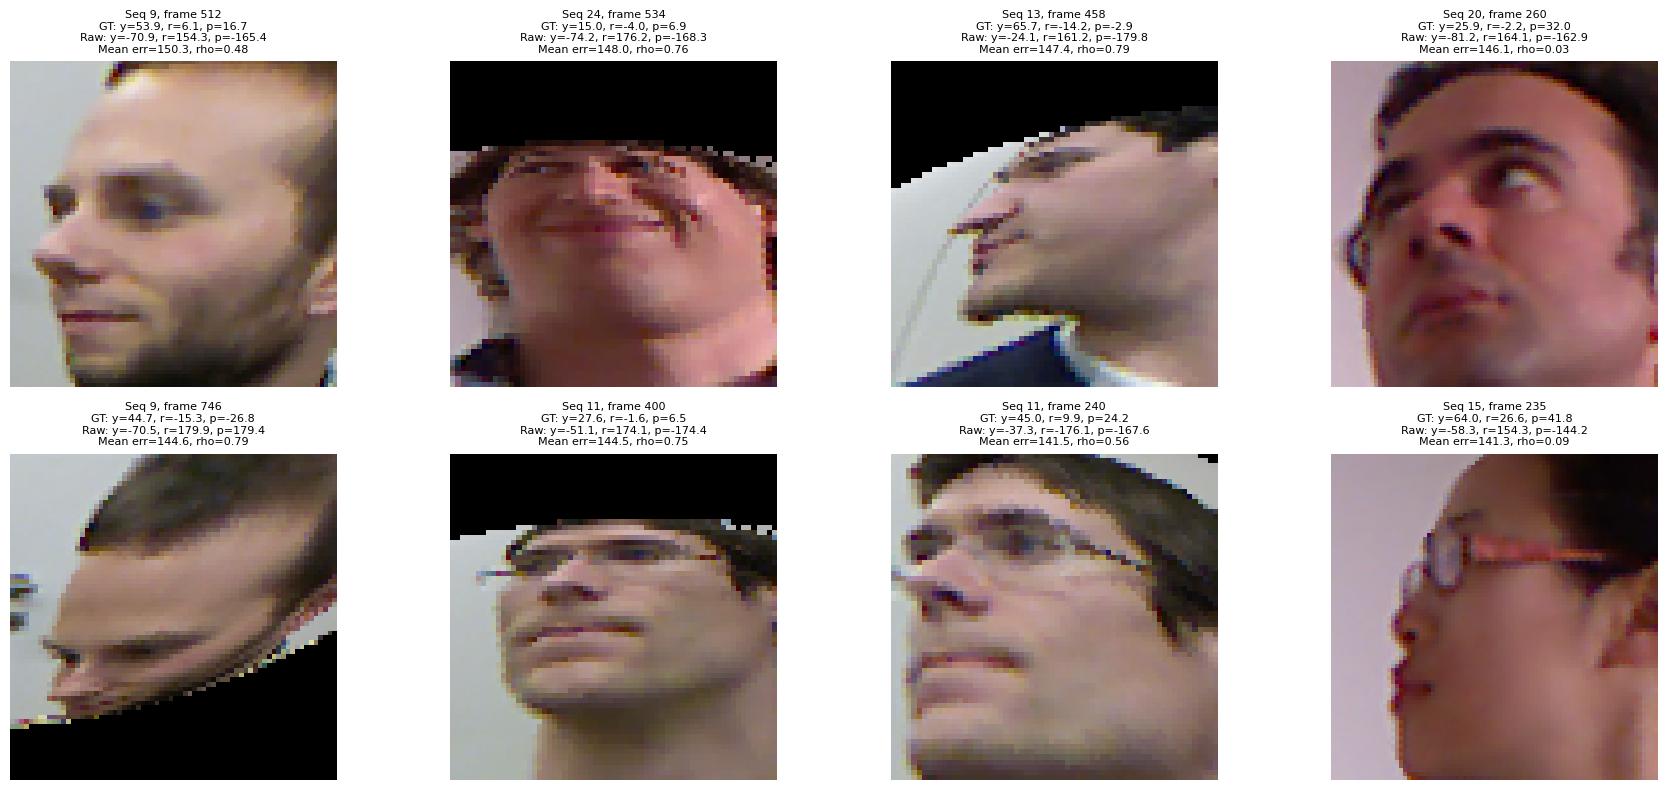

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

# Worst frame-level errors on the test split
worst_frame_errors = (
    final_smoothed_df[final_smoothed_df["split"] == "test"]
    .sort_values("err_mean", ascending=False)
    .head(8)
    .copy()
)

print("Worst frame-level prediction errors on the test split:")
display(
    worst_frame_errors[
        [
            "sequence_id", "frame_id",
            "yaw", "roll", "pitch",
            "pred_yaw", "pred_roll", "pred_pitch",
            "smooth_pred_yaw", "smooth_pred_roll", "smooth_pred_pitch",
            "err_yaw", "err_roll", "err_pitch", "err_mean",
            "rho", "theta"
        ]
    ]
)

plt.figure(figsize=(18, 8))

for i, (_, row) in enumerate(worst_frame_errors.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Seq {int(row['sequence_id'])}, frame {int(row['frame_id'])}\n"
        f"GT: y={row['yaw']:.1f}, r={row['roll']:.1f}, p={row['pitch']:.1f}\n"
        f"Raw: y={row['pred_yaw']:.1f}, r={row['pred_roll']:.1f}, p={row['pred_pitch']:.1f}\n"
        f"Mean err={row['err_mean']:.1f}, rho={row['rho']:.2f}",
        fontsize=8
    )

plt.tight_layout()
plt.show()


### 11.1 Temporal outlier analysis

The previous examples focused on frames with the largest individual prediction errors. We now inspect **temporal outliers**, defined as consecutive frame pairs where the raw prediction changes abruptly from one frame to the next.

This analysis is important because the raw temporal metrics are strongly affected by isolated prediction flips. A single frame with an extreme roll or pitch prediction can create a very large jump between two adjacent frames, even if the ground-truth head pose changes only slightly.

The worst temporal outliers show this clearly. In several cases, the ground-truth motion between consecutive frames is very small, often around **1–2°**, but the raw prediction jitter exceeds **250°**. These jumps are mainly caused by sudden flips in roll and pitch, with predictions moving from moderate values to angles close to `±180°`, or vice versa.

The visual examples confirm that these are not necessarily fast head movements. Some pairs are classified as **low-motion** according to the ground truth, but the model prediction changes dramatically. This indicates that the temporal instability comes mostly from prediction outliers rather than from real head motion.

EMA smoothing reduces the effect of these abrupt jumps, but it can still be influenced by them for several subsequent frames because the smoothed prediction depends on previous values. This explains why temporal post-processing improves stability but does not fully remove the consequences of extreme raw predictions.

Overall, this analysis shows that the raw model suffers from two related problems under fisheye distortion:

- large frame-level orientation errors on individual distorted images;
- abrupt temporal flips between consecutive frames, especially in roll and pitch.

These temporal outliers motivate the later robust filtering experiments, which are designed to reduce the impact of isolated extreme predictions more aggressively than standard EMA.

Worst raw temporal jitter events on the test split:


,sequence_id,prev_frame_id_eval,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,prev_pred_yaw,prev_pred_roll,prev_pred_pitch,gt_motion_magnitude_eval,pred_jitter_magnitude,temporal_motion_error_magnitude,rho,theta,fisheye_change,motion_level,fisheye_change_level
6221,9,746.0,747,45.283021,-15.549258,-27.010221,57.941845,-10.454374,-10.483975,-70.539070,179.871300,179.385600,0.674155,272.472171,272.490825,0.604487,169.163724,0.701663,low,low
9111,14,244.0,245,42.555184,16.676752,46.589256,-61.984715,170.711960,-164.895360,59.483510,5.289853,14.148080,1.537699,272.351899,272.056957,0.620889,77.338989,0.799688,low,low
13584,21,312.0,313,19.580200,-8.361921,49.509294,62.063877,177.983430,178.060620,-44.113594,0.382460,-9.775119,1.553873,269.177066,268.112685,0.768827,81.387184,0.582709,low,low
3780,6,356.0,357,-7.524319,-6.962738,-10.527960,-74.348360,-176.063690,175.764390,-5.367944,4.659939,-8.558890,1.805258,260.308711,259.648789,0.706512,96.833040,0.933843,low,medium
5040,8,336.0,337,-28.264267,-5.642783,5.196704,48.797886,-161.741400,-179.430000,-46.777030,7.263602,-6.369237,2.070266,260.090913,260.636776,0.795389,64.148201,0.810171,low,low
8841,13,458.0,459,62.854153,-11.349928,1.516954,62.476498,-8.597188,-3.520119,-24.145378,161.198730,-179.787340,5.977749,259.623066,259.465889,0.058342,168.221665,0.977072,high,medium
7524,11,443.0,444,55.035073,-14.944150,-10.899110,-5.352636,175.599170,168.757130,64.841960,-8.095066,-8.082684,1.662220,259.390292,259.557453,0.792853,88.593497,0.627647,low,low
13287,21,6.0,7,8.984659,-6.466477,10.876358,-52.573340,164.370160,178.480680,37.992825,-4.031319,3.595054,1.273732,259.125974,259.504118,0.735575,96.430176,0.417729,low,low


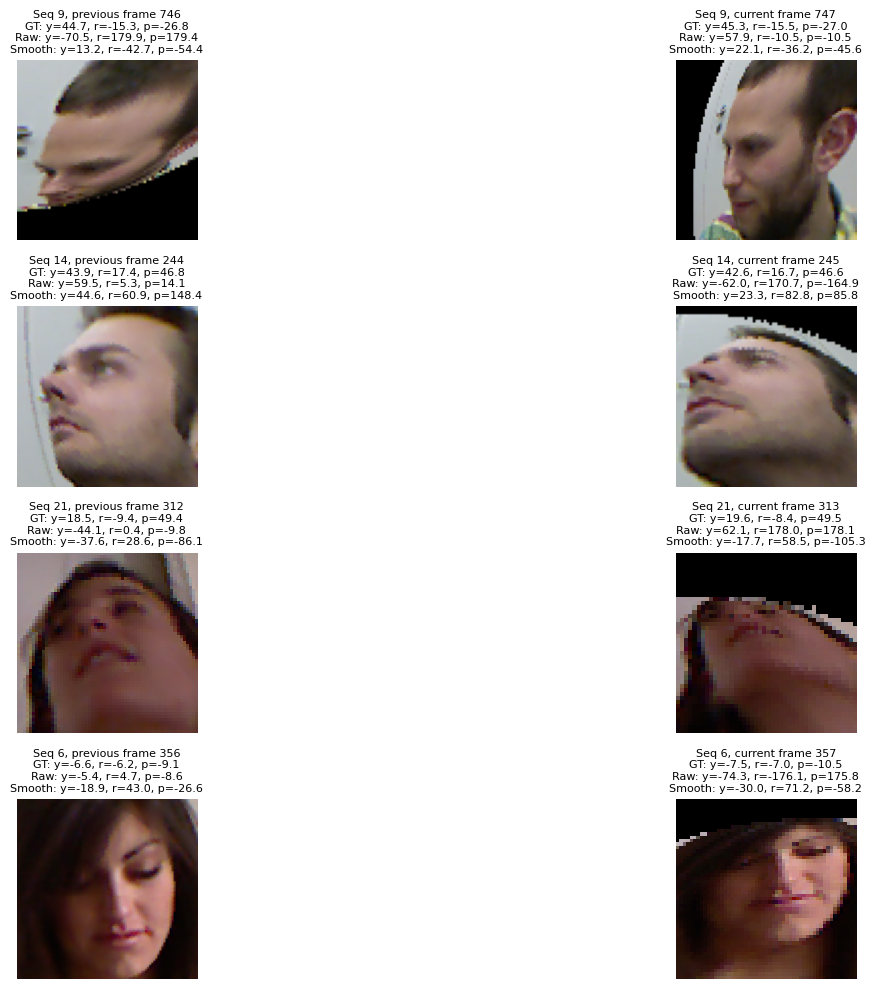

In [36]:
# Worst temporal jitter events on the test split
worst_temporal_outliers = (
    raw_temporal_df[raw_temporal_df["split"] == "test"]
    .sort_values("pred_jitter_magnitude", ascending=False)
    .head(8)
    .copy()
)

print("Worst raw temporal jitter events on the test split:")
display(
    worst_temporal_outliers[
        [
            "sequence_id", "prev_frame_id_eval", "frame_id",
            "yaw", "roll", "pitch",
            "pred_yaw", "pred_roll", "pred_pitch",
            "prev_pred_yaw", "prev_pred_roll", "prev_pred_pitch",
            "gt_motion_magnitude_eval",
            "pred_jitter_magnitude",
            "temporal_motion_error_magnitude",
            "rho", "theta",
            "fisheye_change",
            "motion_level", "fisheye_change_level"
        ]
    ]
)

# Visualize previous/current frames for the top temporal outliers
plt.figure(figsize=(18, 10))

plot_events = worst_temporal_outliers.head(4).reset_index(drop=True)

for i, (_, event_row) in enumerate(plot_events.iterrows()):
    seq_id = int(event_row["sequence_id"])
    prev_frame = int(event_row["prev_frame_id_eval"])
    curr_frame = int(event_row["frame_id"])
    
    prev_row = final_smoothed_df[
        (final_smoothed_df["sequence_id"] == seq_id) &
        (final_smoothed_df["frame_id"] == prev_frame)
    ].iloc[0]
    
    curr_row = final_smoothed_df[
        (final_smoothed_df["sequence_id"] == seq_id) &
        (final_smoothed_df["frame_id"] == curr_frame)
    ].iloc[0]
    
    for j, row in enumerate([prev_row, curr_row]):
        img = Image.open(row["image_path"]).convert("RGB")
        
        subplot_idx = i * 2 + j + 1
        plt.subplot(4, 2, subplot_idx)
        plt.imshow(img)
        plt.axis("off")
        
        label = "previous" if j == 0 else "current"
        plt.title(
            f"Seq {seq_id}, {label} frame {int(row['frame_id'])}\n"
            f"GT: y={row['yaw']:.1f}, r={row['roll']:.1f}, p={row['pitch']:.1f}\n"
            f"Raw: y={row['pred_yaw']:.1f}, r={row['pred_roll']:.1f}, p={row['pred_pitch']:.1f}\n"
            f"Smooth: y={row['smooth_pred_yaw']:.1f}, r={row['smooth_pred_roll']:.1f}, p={row['smooth_pred_pitch']:.1f}",
            fontsize=8
        )

plt.tight_layout()
plt.show()


### 11.2 Interpretation of temporal failures

The temporal failure cases show that the ground-truth head pose often changes only slightly between consecutive frames, while the raw model prediction can jump by more than **250°** in Euler prediction space. These jumps are much larger than the true motion and therefore correspond to prediction instability rather than real head movement.

The outlier summary confirms that extreme raw predictions are a major source of error. On the test split, only about **5.2%** of frames contain at least one raw predicted angle with absolute value above `150°`. However, these frames have a mean error of approximately **110.3°**, compared with **17.8°** for frames without extreme raw angles.

This means that a relatively small subset of frames has a disproportionate impact on the global metrics. The crosstab also shows that most high-error frames are associated with extreme raw predictions, although some high-error frames occur without reaching the `±150°` threshold.

These failures are especially visible in **roll** and **pitch**, where the model often predicts values close to the angular boundary even when the ground-truth pose is moderate. This supports the interpretation that the pretrained model is sensitive to fisheye-induced geometric deformation and can collapse to an incorrect orientation on difficult frames.

This also explains why EMA smoothing helps but is imperfect. When a raw prediction contains an extreme outlier, the smoothed trajectory may be pulled away from the correct pose for several subsequent frames. EMA reduces the sharpness of the jump, but it does not explicitly detect or reject outliers.

Therefore, the failure analysis points to two complementary directions:

- use more robust temporal filters that can suppress isolated extreme predictions;
- adapt the model to the fisheye domain so that these outliers occur less often in the first place.

In [37]:
# Quantify extreme prediction outliers in the test split

test_df = final_smoothed_df[final_smoothed_df["split"] == "test"].copy()

# Frames where at least one raw predicted angle is close to the ±180 boundary
test_df["has_extreme_raw_angle"] = (
    (test_df["pred_yaw"].abs() > 150) |
    (test_df["pred_roll"].abs() > 150) |
    (test_df["pred_pitch"].abs() > 150)
)

# Frames with very high mean angular error
high_error_threshold = test_df["err_mean"].quantile(0.95)
test_df["is_high_error_frame"] = test_df["err_mean"] >= high_error_threshold

outlier_summary = pd.DataFrame([
    {
        "subset": "all test frames",
        "num_frames": len(test_df),
        "mean_error": test_df["err_mean"].mean(),
        "median_error": test_df["err_mean"].median(),
        "extreme_raw_angle_rate_percent": 100 * test_df["has_extreme_raw_angle"].mean(),
        "high_error_threshold_95pct": high_error_threshold,
    },
    {
        "subset": "frames with extreme raw angle",
        "num_frames": int(test_df["has_extreme_raw_angle"].sum()),
        "mean_error": test_df.loc[test_df["has_extreme_raw_angle"], "err_mean"].mean(),
        "median_error": test_df.loc[test_df["has_extreme_raw_angle"], "err_mean"].median(),
        "extreme_raw_angle_rate_percent": 100.0,
        "high_error_threshold_95pct": high_error_threshold,
    },
    {
        "subset": "frames without extreme raw angle",
        "num_frames": int((~test_df["has_extreme_raw_angle"]).sum()),
        "mean_error": test_df.loc[~test_df["has_extreme_raw_angle"], "err_mean"].mean(),
        "median_error": test_df.loc[~test_df["has_extreme_raw_angle"], "err_mean"].median(),
        "extreme_raw_angle_rate_percent": 0.0,
        "high_error_threshold_95pct": high_error_threshold,
    },
])

print("Extreme raw prediction angle summary:")
display(outlier_summary)

print("\nRelationship between extreme raw angles and high-error frames:")
display(
    pd.crosstab(
        test_df["has_extreme_raw_angle"],
        test_df["is_high_error_frame"],
        rownames=["has_extreme_raw_angle"],
        colnames=["is_high_error_frame"]
    )
)

print("\nWorst frames with extreme raw angles:")
display(
    test_df[test_df["has_extreme_raw_angle"]]
    .sort_values("err_mean", ascending=False)
    .head(10)[
        [
            "sequence_id", "frame_id",
            "yaw", "roll", "pitch",
            "pred_yaw", "pred_roll", "pred_pitch",
            "err_yaw", "err_roll", "err_pitch", "err_mean",
            "rho", "theta"
        ]
    ]
)


Extreme raw prediction angle summary:


,subset,num_frames,mean_error,median_error,extreme_raw_angle_rate_percent,high_error_threshold_95pct
0,all test frames,12629,22.596264,11.774267,5.218149,102.931086
1,frames with extreme raw angle,659,110.339710,110.659281,100.000000,102.931086
2,frames without extreme raw angle,11970,17.765610,11.200104,0.000000,102.931086



Relationship between extreme raw angles and high-error frames:


is_high_error_frame,False,True
has_extreme_raw_angle,,
False,11797,173
True,200,459



Worst frames with extreme raw angles:


,sequence_id,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,err_yaw,err_roll,err_pitch,err_mean,rho,theta
5998,9,512,53.874055,6.076503,16.725867,-70.876396,154.25322,-165.43686,124.750451,148.176717,177.837273,150.254814,0.482496,-85.453781
15637,24,534,14.971824,-4.028159,6.872905,-74.167760,176.19992,-168.28963,89.139584,179.771921,175.162535,148.024680,0.764363,88.145918
8856,13,458,65.697734,-14.164451,-2.924440,-24.145378,161.19873,-179.78734,89.843112,175.363181,176.862900,147.356398,0.787802,105.030581
13012,20,260,25.871164,-2.158364,32.035123,-81.230270,164.13070,-162.92656,107.101434,166.289064,165.038317,146.142938,0.026026,-80.254180
6232,9,746,44.697928,-15.289349,-26.799036,-70.539070,179.87130,179.38560,115.236998,164.839351,153.815364,144.630571,0.794175,-71.966720
7494,11,400,27.597994,-1.569234,6.479314,-51.126816,174.05353,-174.37563,78.724810,175.622764,179.145056,144.497543,0.752066,91.713675
7334,11,240,44.975228,9.912768,24.229610,-37.337852,-176.06473,-167.56093,82.313080,174.022502,168.209460,141.515014,0.555003,77.461124
9918,15,235,64.012936,26.642886,41.764675,-58.325558,154.30006,-144.19913,122.338494,127.657174,174.036195,141.343954,0.086545,133.379167
12625,19,386,52.912167,15.735368,29.212049,-62.136765,-155.68860,164.30592,115.048932,171.423968,135.093871,140.522257,0.573721,112.395776
610,2,114,-4.871459,1.881710,21.358199,-81.260440,167.20880,-155.18895,76.388981,165.327090,176.547149,139.421073,0.345597,76.328412


### 11.3 Failure analysis summary

The failure analysis shows that the zero-shot errors are not uniformly distributed across BIWI-360. A small subset of frames produces extreme predictions close to the angular boundary, especially in **roll** and **pitch**, and these frames have a disproportionate effect on both frame-level accuracy and temporal stability.

On the test split, only about **5.2%** of frames contain at least one raw predicted angle with absolute value above `150°`. However, these frames have a mean error of approximately **110.3°**, compared with **17.8°** for frames without extreme raw angles. This confirms that the global error is strongly affected by a limited number of severe outliers.

Visually, many failures correspond to frames with strong fisheye deformation, black warped regions, profile-like views or partial facial visibility. In these cases, the ground-truth head pose is still valid, but the face appearance differs strongly from the perspective images used to train the pretrained model. As a result, 6DRepNet360 can interpret fisheye-induced deformation as a very different head orientation.

The temporal failures are especially informative. In several consecutive-frame pairs, the ground-truth pose changes by only a few degrees, while the raw prediction jumps by more than **250°** in Euler prediction space. The geodesic analysis confirms that these are not only Euler wrap-around artifacts: the model can genuinely flip to a very different SO(3) orientation between adjacent frames.

This explains the behavior of EMA smoothing. EMA strongly reduces temporal jitter and improves Euler MAE, but it is not robust to isolated extreme outliers. Once an outlier enters the smoothed trajectory, it can bias the prediction for several subsequent frames. Moreover, the mean geodesic error remains almost unchanged after EMA, showing that smoothing improves temporal consistency more than true 3D orientation accuracy.

The compact test-set summary below highlights the main result of the zero-shot and smoothing stages: EMA improves Euler MAE and greatly reduces temporal jitter, but it does not solve the underlying fisheye-induced rotation error. This motivates the later experiments with more robust temporal filtering and fisheye-aware adaptation.

In [ ]:
# Compact summary of the main test-set results
test_frame_row = frame_raw_vs_smooth[frame_raw_vs_smooth["split"] == "test"].iloc[0]
test_temporal_row = temporal_raw_vs_smooth[temporal_raw_vs_smooth["split"] == "test"].iloc[0]
test_geo_row = geo_frame[geo_frame["split"] == "test"].iloc[0]

def _dir(delta, lower_is_better=True):
    if abs(delta) < 1e-9:
        return "leaves unchanged"
    improved = (delta < 0) if lower_is_better else (delta > 0)
    return "improves" if improved else "worsens"

mae_delta = test_frame_row["delta_mean_mae"]
geo_delta = test_geo_row["geo_mean_smooth"] - test_geo_row["geo_mean_raw"]

main_results_summary = pd.DataFrame([
    {"metric_group": "Frame-level accuracy (Euler)", "metric": "Mean MAE (deg)",
     "raw": test_frame_row["raw_mean_mae"], "smoothed": test_frame_row["smooth_mean_mae"],
     "change": mae_delta,
     "interpretation": f"Balanced EMA {_dir(mae_delta)} frame-level Euler MAE."},
    {"metric_group": "Frame-level accuracy (geodesic)", "metric": "Mean geodesic error (deg)",
     "raw": test_geo_row["geo_mean_raw"], "smoothed": test_geo_row["geo_mean_smooth"],
     "change": geo_delta,
     "interpretation": f"Faithful SO(3) error (bounded to 180 deg); EMA {_dir(geo_delta)} it."},
    {"metric_group": "Temporal stability (Euler)", "metric": "Mean prediction jitter (deg)",
     "raw": test_temporal_row["raw_mean_jitter"], "smoothed": test_temporal_row["smooth_mean_jitter"],
     "change": test_temporal_row["delta_jitter"],
     "interpretation": "EMA strongly reduces Euler jitter (partly an L2 artifact; cf. geodesic jitter)."},
])

print("Main test-set result summary:")
display(main_results_summary)

summary_csv = "/kaggle/working/main_results_summary.csv"
main_results_summary.to_csv(summary_csv, index=False)
print("Main summary saved to:", summary_csv)


Main test-set result summary:

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>metric_group</th>
      <th>metric</th>
      <th>raw</th>
      <th>smoothed</th>
      <th>change</th>
      <th>interpretation</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Frame-level accuracy (Euler)</td>
      <td>Mean MAE (deg)</td>
      <td>22.596264</td>
      <td>19.936329</td>
      <td>-2.659935</td>
      <td>Balanced EMA improves frame-level Euler MAE.</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Frame-level accuracy (geodesic)</td>
      <td>Mean geodesic error (deg)</td>
      <td>33.190013</td>
      <td>33.545651</td>
      <td>0.355638</td>
      <td>Faithful SO(3) error (bounded to 180 deg); EMA...</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Temporal stability (Euler)</td>
      <td>Mean prediction jitter (deg)</td>
      <td>44.273643</td>
      <td>9.223032</td>
      <td>-35.050611</td>
      <td>EMA strongly reduces Euler jitter (partly an L...</td>
    </tr>
  </tbody>
</table>
</div>


Main summary saved to: /kaggle/working/main_results_summary.csv

## 12. From failure analysis to additional experiments

The previous sections showed that the zero-shot 6DRepNet360 model has two main limitations on BIWI-360:

1. high frame-level error under fisheye distortion;
2. strong temporal instability caused by extreme prediction outliers, especially in roll and pitch.

The failure analysis suggests that these problems are not simply caused by a bad angle convention or by the use of a frame-by-frame model. Instead, the evidence points to a stronger issue: the pretrained model was trained mainly on perspective-like face images and does not generalize well to the fisheye geometry of BIWI-360.

The rest of the notebook tests this interpretation through four additional experiments.

First, we evaluate the same inference pipeline on **AFLW2000-3D**, a non-fisheye benchmark. This sanity check verifies whether the model and preprocessing work correctly under normal image geometry.

Second, we perform a **sensitivity analysis** on BIWI-360. We study the effect of the fisheye radial position `rho`, compare against simple baselines, and analyze whether the model adds useful information on all axes or mainly on yaw.

Third, we test **robust temporal filtering** methods. These filters are motivated by the outlier analysis and aim to reduce isolated extreme predictions more effectively than standard EMA.

Finally, we explore **fisheye-aware adaptation** using 300W-LP-360. This experiment fine-tunes the model with fisheye-distorted images and uses the location metadata `rho` and `theta` to help the model account for the distortion geometry.

Together, these experiments move from diagnosis to possible solutions. They help answer whether the problem is a broken pipeline, a temporal smoothing issue, or a deeper fisheye domain-shift problem.

## 13. Pipeline sanity check on non-fisheye AFLW2000-3D

The main BIWI-360 experiment shows that the zero-shot 6DRepNet360 model performs poorly under fisheye distortion. Before attributing this failure to the model itself, we run a sanity check on a standard non-fisheye head pose benchmark: **AFLW2000-3D**.

The goal of this section is to verify whether the same pretrained model, preprocessing pipeline, Euler-angle conversion and metric implementation behave correctly on conventional perspective face images. If the model performs reasonably on AFLW2000-3D but fails on BIWI-360, this supports the hypothesis that the main issue is the fisheye domain shift rather than a broken inference pipeline.

We first check that the AFLW2000-3D dataset is available in the Kaggle environment and that it contains the expected image and annotation files.

The dataset is found at:

`/kaggle/input/datasets/mohamedadlyi/aflw2000-3d/AFLW2000`

It contains **2,000 `.jpg` images** and **2,000 `.mat` annotation files**, as expected. This allows us to evaluate the same 6DRepNet360 model on non-fisheye images in the following cells.

In [46]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")
DATASETS_ROOT = INPUT_ROOT / "datasets"

AFLW2000_ROOT = DATASETS_ROOT / "mohamedadlyi" / "aflw2000-3d" / "AFLW2000"

print("AFLW2000-3D root:", AFLW2000_ROOT)
print("Exists:", AFLW2000_ROOT.exists())

if not AFLW2000_ROOT.exists():
    raise FileNotFoundError("AFLW2000-3D was not found at the expected path. Please check the Kaggle input structure.")

aflw_jpg_count = len(list(AFLW2000_ROOT.glob("*.jpg")))
aflw_mat_count = len(list(AFLW2000_ROOT.glob("*.mat")))

print("Number of .jpg files:", aflw_jpg_count)
print("Number of .mat files:", aflw_mat_count)


AFLW2000-3D root: /kaggle/input/datasets/mohamedadlyi/aflw2000-3d/AFLW2000
Exists: True
Number of .jpg files: 2000
Number of .mat files: 2000


### 13.1 Inspecting AFLW2000-3D annotations

AFLW2000-3D contains **2,000 non-fisheye face images**, with one `.jpg` image and one `.mat` annotation file per sample. Before running inference, we inspect one annotation file to verify that the dataset has the expected structure for 6DRepNet360 evaluation.

The repository's AFLW2000 pipeline expects two key fields:

| Field | Meaning |
|---|---|
| `Pose_Para` | Head pose parameters and additional camera/scale information |
| `pt2d` | 2D facial landmarks used to crop the face region |

The inspected annotation file contains both fields. `Pose_Para` has shape `(1, 7)`, where the first three values correspond to:

`pitch`, `yaw`, `roll`

in radians. These are converted to degrees before evaluation. The file also contains `pt2d` landmarks with shape `(2, 21)`, which are used to define a loose facial crop before applying the same preprocessing used by the 6DRepNet360 repository.

This confirms that the AFLW2000-3D input is compatible with the model evaluation pipeline. Unlike BIWI-360, these images are not fisheye-distorted, so they provide a useful reference to check whether the pretrained model and our inference code behave correctly under standard image geometry.

In [47]:
import scipy.io as sio
import numpy as np
import pandas as pd
from pathlib import Path

aflw_images = sorted(AFLW2000_ROOT.glob("*.jpg"))
aflw_mats = sorted(AFLW2000_ROOT.glob("*.mat"))

sample_mat_path = aflw_mats[0]
sample_mat = sio.loadmat(sample_mat_path)

print("Sample annotation file:")
print(sample_mat_path)

print("\nAvailable keys:")
for key, value in sample_mat.items():
    if not key.startswith("__"):
        print(f"{key}: type={type(value)}, shape={getattr(value, 'shape', None)}, dtype={getattr(value, 'dtype', None)}")

if "Pose_Para" in sample_mat:
    print("\nPose_Para sample:")
    print(sample_mat["Pose_Para"])
    print("\nPose_Para first three values interpreted as pitch, yaw, roll in radians:")
    pose_para = sample_mat["Pose_Para"][0]
    print("pitch rad:", pose_para[0])
    print("yaw rad:  ", pose_para[1])
    print("roll rad: ", pose_para[2])
    print("\nConverted to degrees:")
    print("pitch deg:", pose_para[0] * 180 / np.pi)
    print("yaw deg:  ", pose_para[1] * 180 / np.pi)
    print("roll deg: ", pose_para[2] * 180 / np.pi)

if "pt2d" in sample_mat:
    print("\npt2d shape:")
    print(sample_mat["pt2d"].shape)


Sample annotation file:
/kaggle/input/datasets/mohamedadlyi/aflw2000-3d/AFLW2000/image00002.mat

Available keys:
pt2d: type=<class 'numpy.ndarray'>, shape=(2, 21), dtype=float64
Illum_Para: type=<class 'numpy.ndarray'>, shape=(1, 10), dtype=float64
Color_Para: type=<class 'numpy.ndarray'>, shape=(1, 7), dtype=float32
Tex_Para: type=<class 'numpy.ndarray'>, shape=(199, 1), dtype=float64
Shape_Para: type=<class 'numpy.ndarray'>, shape=(199, 1), dtype=float64
Exp_Para: type=<class 'numpy.ndarray'>, shape=(29, 1), dtype=float64
Pose_Para: type=<class 'numpy.ndarray'>, shape=(1, 7), dtype=float32
roi: type=<class 'numpy.ndarray'>, shape=(1, 4), dtype=int16
pt3d_68: type=<class 'numpy.ndarray'>, shape=(3, 68), dtype=float32

Pose_Para sample:
[[-3.9923078e-01  1.8226579e-02  8.5676216e-02  2.3146532e+02
   2.6206659e+02 -1.0279360e+02  1.5874623e-03]]

Pose_Para first three values interpreted as pitch, yaw, roll in radians:
pitch rad: -0.39923078
yaw rad:   0.018226579
roll rad:  0.085676216

### 13.2 Building the AFLW2000-3D evaluation table

The AFLW2000-3D `.mat` files store the head pose in the `Pose_Para` field. Following the dataset convention, the first three values correspond to:

`pitch`, `yaw`, `roll`

in radians. For consistency with the BIWI-360 evaluation, we convert these values to degrees and store them in the same column order used throughout the notebook:

`yaw`, `roll`, `pitch`

Some raw Euler values can fall outside the principal angular interval, so we wrap the converted angles to `[-180°, 180°)` before computing errors. This keeps the angular representation consistent with the circular error functions used in the rest of the project.

The resulting AFLW2000-3D evaluation table contains **2,000 samples** and includes the image path, annotation path and wrapped ground-truth pose angles. Unlike BIWI-360, this dataset does not include fisheye metadata, because it is used here only as a **non-fisheye sanity check**.

This table allows us to run the same pretrained 6DRepNet360 model on standard perspective face images and compare its behavior with the much harder BIWI-360 fisheye setting.

In [48]:
import scipy.io as sio
import pandas as pd
import numpy as np
from pathlib import Path

aflw_records = []

for image_path in sorted(AFLW2000_ROOT.glob("*.jpg")):
    mat_path = image_path.with_suffix(".mat")
    
    if not mat_path.exists():
        continue
    
    mat = sio.loadmat(mat_path)
    pose_para = mat["Pose_Para"][0]
    
    # AFLW2000-3D convention in Pose_Para:
    # [pitch, yaw, roll, tdx, tdy, tdz, scale_factor]
    # The first three values are in radians, but some Euler values may appear
    # outside the principal angular range. We therefore convert to degrees
    # and wrap them to [-180, 180).
    pitch_raw_deg = float(pose_para[0]) * 180.0 / np.pi
    yaw_raw_deg = float(pose_para[1]) * 180.0 / np.pi
    roll_raw_deg = float(pose_para[2]) * 180.0 / np.pi
    
    aflw_records.append({
        "image_name": image_path.name,
        "image_path": str(image_path),
        "mat_path": str(mat_path),
        "yaw_raw": yaw_raw_deg,
        "roll_raw": roll_raw_deg,
        "pitch_raw": pitch_raw_deg,
        "yaw": wrap_angle_deg(yaw_raw_deg),
        "roll": wrap_angle_deg(roll_raw_deg),
        "pitch": wrap_angle_deg(pitch_raw_deg),
    })

aflw_df = pd.DataFrame(aflw_records)

print("AFLW2000-3D evaluation table shape:", aflw_df.shape)

print("\nFirst rows:")
display(aflw_df.head())

print("\nRaw pose summary before wrapping:")
display(aflw_df[["yaw_raw", "roll_raw", "pitch_raw"]].describe())

print("\nWrapped pose summary used for evaluation:")
display(aflw_df[["yaw", "roll", "pitch"]].describe())


AFLW2000-3D evaluation table shape: (2000, 9)

First rows:


,image_name,image_path,mat_path,yaw_raw,roll_raw,pitch_raw,yaw,roll,pitch
0,image00002.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,1.044306,4.908886,-22.874239,1.044306,4.908886,-22.874239
1,image00004.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,68.155241,17.243670,26.932742,68.155241,17.243670,26.932742
2,image00006.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,50.485412,-13.570645,-10.579652,50.485412,-13.570645,-10.579652
3,image00008.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,17.143374,-21.392783,-10.048456,17.143374,-21.392783,-10.048456
4,image00010.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,68.640546,-59.207973,-50.544581,68.640546,-59.207973,-50.544581



Raw pose summary before wrapping:


,yaw_raw,roll_raw,pitch_raw
count,2000.000000,2000.000000,2000.000000
mean,0.806547,-1.975500,-6.138931
std,37.482043,41.024606,35.988570
min,-351.226933,-972.272838,-713.745097
25%,-16.859080,-10.015671,-14.811132
50%,1.128854,-1.036931,-7.005438
75%,19.177740,7.699269,2.302842
max,187.786940,333.999693,893.746536



Wrapped pose summary used for evaluation:


,yaw,roll,pitch
count,2000.000000,2000.000000,2000.000000
mean,0.806547,-1.075500,-5.418931
std,36.611833,24.235566,22.281393
min,-172.213060,-161.077284,-164.131403
25%,-16.859080,-9.955861,-14.655580
50%,1.128854,-1.010890,-6.922283
75%,19.170067,7.714045,2.403465
max,118.907542,159.192097,173.746536


### 13.3 Visual sanity check on AFLW2000-3D

Before running inference, we visualize a few AFLW2000-3D samples together with their wrapped ground-truth yaw, roll and pitch angles.

The examples confirm that AFLW2000-3D contains conventional, non-fisheye face images. The faces may still vary in pose, crop, illumination, image quality and background, but they do not contain the strong radial warping, black fisheye padding or frame-wise distortion changes observed in BIWI-360.

This makes AFLW2000-3D a useful sanity-check dataset. If the same pretrained 6DRepNet360 model performs reasonably here but poorly on BIWI-360, the difference is likely caused by the fisheye domain shift rather than by a general failure of the inference code.

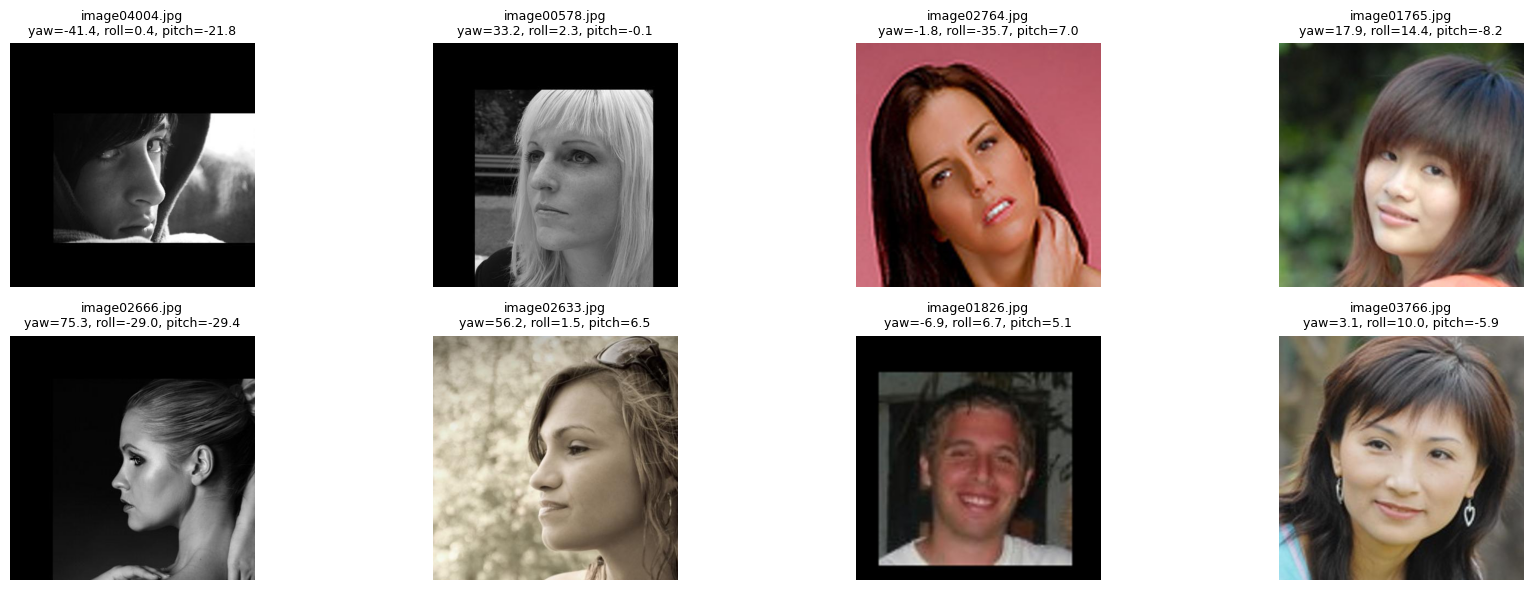

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

sample_aflw = aflw_df.sample(8, random_state=42).reset_index(drop=True)

plt.figure(figsize=(18, 6))

for i, row in sample_aflw.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{row['image_name']}\n"
        f"yaw={row['yaw']:.1f}, roll={row['roll']:.1f}, pitch={row['pitch']:.1f}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### 13.4 Running 6DRepNet360 on AFLW2000-3D

We now run the same pretrained **6DRepNet360** model on AFLW2000-3D. This experiment uses the same model weights, the same Euler-angle output convention and the same angular-error functions as the BIWI-360 evaluation.

The main difference is the input preprocessing. AFLW2000-3D provides 2D facial landmarks in `pt2d`, so we use them to crop a loose face region before applying the standard 6DRepNet360 transform:

`Resize(256) → CenterCrop(224) → ToTensor → ImageNet normalization`

This crop follows the same idea as the official AFLW2000 preprocessing in the 6DRepNet360 repository and makes the comparison fairer, because the model receives a centered face crop rather than the full image.

The inference step produces predictions for all **2,000 AFLW2000-3D images** and saves them to:

`/kaggle/working/aflw2000_6drepnet360_predictions.csv`

In this run, inference takes about **12 seconds**, at roughly **166 frames per second**. The prediction preview already suggests that the model behaves much more reasonably on these non-fisheye images than on BIWI-360: the predicted angles usually follow the ground-truth pose direction and do not show the same systematic instability observed under fisheye distortion.

The next section quantifies this sanity check with the same frame-level metrics used for BIWI-360.

In [50]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm
import scipy.io as sio
import numpy as np
import pandas as pd
import time
from pathlib import Path

class AFLW2000DatasetForInference(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def crop_face_with_pt2d(self, image, mat_path):
        mat = sio.loadmat(mat_path)
        pt2d = mat["pt2d"]

        x_min = float(np.min(pt2d[0, :]))
        y_min = float(np.min(pt2d[1, :]))
        x_max = float(np.max(pt2d[0, :]))
        y_max = float(np.max(pt2d[1, :]))

        width = x_max - x_min
        height = y_max - y_min

        # Loose crop, similar in spirit to the official AFLW2000 preprocessing.
        k = 0.20
        x_min = x_min - 2 * k * width
        y_min = y_min - 2 * k * height
        x_max = x_max + 2 * k * width
        y_max = y_max + 0.6 * k * height

        return image.crop((int(x_min), int(y_min), int(x_max), int(y_max)))

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.crop_face_with_pt2d(image, row["mat_path"])

        image = self.transform(image)

        return image, index

aflw_prediction_csv = Path("/kaggle/working/aflw2000_6drepnet360_predictions.csv")

if aflw_prediction_csv.exists():
    print("Loading existing AFLW2000-3D predictions from:", aflw_prediction_csv)
    aflw_pred_df = pd.read_csv(aflw_prediction_csv)
else:
    aflw_dataset = AFLW2000DatasetForInference(aflw_df, inference_transform)
    aflw_loader = DataLoader(
        aflw_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    pred_yaw = np.zeros(len(aflw_df), dtype=np.float32)
    pred_roll = np.zeros(len(aflw_df), dtype=np.float32)
    pred_pitch = np.zeros(len(aflw_df), dtype=np.float32)

    model.eval()
    start_time = time.time()

    with torch.no_grad():
        for images, indices in tqdm(aflw_loader, desc="Running AFLW2000-3D inference"):
            images = images.to(device, non_blocking=True)

            rotation_matrices = model(images)
            euler = sixd_utils.compute_euler_angles_from_rotation_matrices(rotation_matrices)
            euler_deg = euler.detach().cpu().numpy() * 180.0 / np.pi

            # Repository convention:
            # euler[:, 0] = pitch, euler[:, 1] = yaw, euler[:, 2] = roll
            indices_np = indices.numpy()
            pred_pitch[indices_np] = euler_deg[:, 0]
            pred_yaw[indices_np] = euler_deg[:, 1]
            pred_roll[indices_np] = euler_deg[:, 2]

    elapsed = time.time() - start_time

    aflw_pred_df = aflw_df.copy()
    aflw_pred_df["pred_yaw"] = pred_yaw
    aflw_pred_df["pred_roll"] = pred_roll
    aflw_pred_df["pred_pitch"] = pred_pitch

    aflw_pred_df.to_csv(aflw_prediction_csv, index=False)

    print(f"AFLW2000-3D inference completed in {elapsed:.2f} seconds.")
    print(f"Average speed: {len(aflw_pred_df) / elapsed:.2f} frames/second.")
    print("Predictions saved to:", aflw_prediction_csv)

print("AFLW2000-3D prediction table shape:", aflw_pred_df.shape)

print("\nPrediction preview:")
display(aflw_pred_df[[
    "image_name",
    "yaw", "roll", "pitch",
    "pred_yaw", "pred_roll", "pred_pitch"
]].head())

print("\nPrediction summary:")
display(aflw_pred_df[["pred_yaw", "pred_roll", "pred_pitch"]].describe())


Running AFLW2000-3D inference:   0%|          | 0/16 [00:00<?, ?it/s]

AFLW2000-3D inference completed in 12.03 seconds.
Average speed: 166.19 frames/second.
Predictions saved to: /kaggle/working/aflw2000_6drepnet360_predictions.csv
AFLW2000-3D prediction table shape: (2000, 12)

Prediction preview:


,image_name,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch
0,image00002.jpg,1.044306,4.908886,-22.874239,2.653513,4.699481,-17.231188
1,image00004.jpg,68.155241,17.243670,26.932742,63.499775,15.963361,24.122458
2,image00006.jpg,50.485412,-13.570645,-10.579652,36.625687,-8.763353,-10.252538
3,image00008.jpg,17.143374,-21.392783,-10.048456,14.361500,-21.054016,-17.879030
4,image00010.jpg,68.640546,-59.207973,-50.544581,68.612160,-70.097839,-72.951759



Prediction summary:


,pred_yaw,pred_roll,pred_pitch
count,2000.000000,2000.000000,2000.000000
mean,-2.382340,-1.909897,-4.871856
std,37.862797,30.883980,28.941111
min,-88.061996,-179.480667,-177.180084
25%,-22.325544,-10.634272,-12.481963
50%,-1.687401,-1.363595,-5.921751
75%,16.066055,6.453628,1.650722
max,88.667770,179.611191,168.595016


### 13.5 AFLW2000-3D angle convention diagnostic and metrics

Before using AFLW2000-3D as a sanity check, we repeat the same angle-convention diagnostic applied to BIWI-360. We test all possible assignments of predicted angles to ground-truth angles, together with all sign combinations.

The best result is again obtained with the raw convention:

| Ground-truth angle | Prediction column | Sign |
|---|---|---|
| `yaw` | `pred_yaw` | `+1` |
| `roll` | `pred_roll` | `+1` |
| `pitch` | `pred_pitch` | `+1` |

This confirms that the model output convention is consistent across both datasets and that no additional sign correction or angle permutation is needed.

Using this convention, the pretrained 6DRepNet360 model obtains the following AFLW2000-3D sanity-check results:

| Metric | Value |
|---|---:|
| MAE yaw | ≈ 5.48° |
| MAE roll | ≈ 5.87° |
| MAE pitch | ≈ 7.82° |
| Mean MAE | ≈ 6.39° |
| Mean RMSE | ≈ 16.57° |

These results are much better than the zero-shot BIWI-360 test results, where the same model and inference pipeline obtained a mean MAE of about **22.6°**. Therefore, the poor BIWI-360 performance cannot be explained by a broken implementation, wrong angle convention or invalid preprocessing pipeline.

Instead, this sanity check supports the main interpretation of the project: 6DRepNet360 works reasonably on conventional non-fisheye images, but suffers a strong domain shift when applied directly to fisheye-distorted BIWI-360 frames.

The error distribution still contains a few large outliers, which is expected in AFLW2000-3D due to difficult samples and wide pose variation. However, the median errors are low and the overall mean MAE is close to the expected behavior of a strong pretrained head pose estimator on standard perspective imagery.

In [51]:
import itertools
import numpy as np
import pandas as pd

gt_cols = ["yaw", "roll", "pitch"]
pred_cols = ["pred_yaw", "pred_roll", "pred_pitch"]

diagnostic_rows = []

for perm in itertools.permutations(pred_cols):
    for signs in itertools.product([1, -1], repeat=3):
        errors = {}
        
        for gt_col, pred_col, sign in zip(gt_cols, perm, signs):
            errors[gt_col] = angular_diff_array_deg(
                sign * aflw_pred_df[pred_col].values,
                aflw_pred_df[gt_col].values
            )
        
        mae_yaw = errors["yaw"].mean()
        mae_roll = errors["roll"].mean()
        mae_pitch = errors["pitch"].mean()
        mean_mae = np.mean([mae_yaw, mae_roll, mae_pitch])
        
        diagnostic_rows.append({
            "pred_for_yaw": perm[0],
            "pred_for_roll": perm[1],
            "pred_for_pitch": perm[2],
            "sign_yaw": signs[0],
            "sign_roll": signs[1],
            "sign_pitch": signs[2],
            "mae_yaw": mae_yaw,
            "mae_roll": mae_roll,
            "mae_pitch": mae_pitch,
            "mean_mae": mean_mae,
        })

aflw_angle_diagnostic = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("mean_mae")
    .reset_index(drop=True)
)

print("Best AFLW2000-3D angle assignment and sign combinations:")
display(aflw_angle_diagnostic.head(15))

print("\nRaw convention result:")
aflw_raw_result = aflw_angle_diagnostic[
    (aflw_angle_diagnostic["pred_for_yaw"] == "pred_yaw") &
    (aflw_angle_diagnostic["pred_for_roll"] == "pred_roll") &
    (aflw_angle_diagnostic["pred_for_pitch"] == "pred_pitch") &
    (aflw_angle_diagnostic["sign_yaw"] == 1) &
    (aflw_angle_diagnostic["sign_roll"] == 1) &
    (aflw_angle_diagnostic["sign_pitch"] == 1)
]
display(aflw_raw_result)

# Compute final AFLW2000-3D frame-level errors using raw convention
for angle in ["yaw", "roll", "pitch"]:
    aflw_pred_df[f"err_{angle}"] = angular_diff_array_deg(
        aflw_pred_df[f"pred_{angle}"],
        aflw_pred_df[angle]
    )

aflw_pred_df["err_mean"] = aflw_pred_df[["err_yaw", "err_roll", "err_pitch"]].mean(axis=1)

aflw_metrics = pd.DataFrame([{
    "dataset": "AFLW2000-3D non-fisheye",
    "num_frames": len(aflw_pred_df),
    "mae_yaw": aflw_pred_df["err_yaw"].mean(),
    "mae_roll": aflw_pred_df["err_roll"].mean(),
    "mae_pitch": aflw_pred_df["err_pitch"].mean(),
    "mean_mae": aflw_pred_df[["err_yaw", "err_roll", "err_pitch"]].mean().mean(),
    "rmse_yaw": np.sqrt(np.mean(aflw_pred_df["err_yaw"] ** 2)),
    "rmse_roll": np.sqrt(np.mean(aflw_pred_df["err_roll"] ** 2)),
    "rmse_pitch": np.sqrt(np.mean(aflw_pred_df["err_pitch"] ** 2)),
}])

aflw_metrics["mean_rmse"] = aflw_metrics[["rmse_yaw", "rmse_roll", "rmse_pitch"]].mean(axis=1)

print("\nAFLW2000-3D sanity-check metrics:")
display(aflw_metrics)

print("\nAFLW2000-3D error distribution:")
display(aflw_pred_df[["err_yaw", "err_roll", "err_pitch", "err_mean"]].describe())

aflw_output_csv = "/kaggle/working/aflw2000_6drepnet360_predictions_with_errors.csv"
aflw_pred_df.to_csv(aflw_output_csv, index=False)

print("\nAFLW2000-3D predictions with errors saved to:")
print(aflw_output_csv)


Best AFLW2000-3D angle assignment and sign combinations:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,5.476733,5.866819,7.822874,6.388808
1,pred_yaw,pred_roll,pred_pitch,1,1,-1,5.476733,5.866819,29.465042,13.602864
2,pred_yaw,pred_roll,pred_pitch,1,-1,1,5.476733,30.093771,7.822874,14.464459
3,pred_yaw,pred_pitch,pred_roll,1,1,1,5.476733,19.994818,21.183583,15.551711
4,pred_yaw,pred_pitch,pred_roll,1,1,-1,5.476733,19.994818,21.417165,15.629572
5,pred_yaw,pred_pitch,pred_roll,1,-1,1,5.476733,20.572983,21.183583,15.744433
6,pred_yaw,pred_pitch,pred_roll,1,-1,-1,5.476733,20.572983,21.417165,15.822294
7,pred_roll,pred_yaw,pred_pitch,-1,-1,1,27.559397,28.967982,7.822874,21.450084
8,pred_yaw,pred_roll,pred_pitch,1,-1,-1,5.476733,30.093771,29.465042,21.678515
9,pred_pitch,pred_roll,pred_yaw,-1,1,1,28.729967,5.866819,31.166319,21.921035



Raw convention result:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,5.476733,5.866819,7.822874,6.388808



AFLW2000-3D sanity-check metrics:


,dataset,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse_yaw,rmse_roll,rmse_pitch,mean_rmse
0,AFLW2000-3D non-fisheye,2000,5.476733,5.866819,7.822874,6.388808,10.083944,19.602597,20.038184,16.574909



AFLW2000-3D error distribution:


,err_yaw,err_roll,err_pitch,err_mean
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,5.476733,5.866819,7.822874,6.388808
std,8.469191,18.708748,18.452689,13.674932
min,0.009722,0.000906,0.002940,0.147979
25%,1.724605,0.756171,1.706054,2.170510
50%,3.694763,1.736460,3.922340,3.553771
75%,6.611863,3.642508,7.594737,5.518661
max,152.512930,179.784732,179.165648,142.277997



AFLW2000-3D predictions with errors saved to:
/kaggle/working/aflw2000_6drepnet360_predictions_with_errors.csv


### 13.6 Comparing the sanity check with BIWI-360

The AFLW2000-3D sanity check provides an important reference point for interpreting the BIWI-360 results. If the model setup, preprocessing, angle conversion or metric implementation were incorrect, we would expect poor performance on AFLW2000-3D as well.

Instead, the same pretrained 6DRepNet360 model performs much better on AFLW2000-3D than on BIWI-360. On the BIWI-360 fisheye test split, the model obtains a mean MAE of about **22.60°**, while on AFLW2000-3D it obtains about **6.39°**.

| Dataset | Mean MAE | Mean RMSE |
|---|---:|---:|
| BIWI-360 fisheye test | ≈ 22.60° | ≈ 39.49° |
| AFLW2000-3D non-fisheye | ≈ 6.39° | ≈ 16.57° |

This corresponds to a relative increase of about **253.7%** in mean MAE from AFLW2000-3D to BIWI-360.

The comparison supports the main interpretation of the project: the poor BIWI-360 performance is not mainly caused by a broken inference implementation or a wrong angle convention. The same model and pipeline work reasonably well on conventional non-fisheye images, but degrade strongly under fisheye distortion.

Therefore, the next analyses focus on understanding the BIWI-360 failure modes more precisely: the effect of fisheye position, the role of outliers, the comparison with simple baselines, and whether post-processing or fisheye-aware adaptation can reduce the domain gap.

In [ ]:
# Compare BIWI-360 test performance with AFLW2000-3D sanity-check performance

biwi_test_metrics_for_comparison = frame_metrics[frame_metrics["split"] == "test"].iloc[0]

dataset_comparison = pd.DataFrame([
    {
        "dataset": "BIWI-360 fisheye test",
        "num_frames": int(biwi_test_metrics_for_comparison["num_frames"]),
        "mae_yaw": biwi_test_metrics_for_comparison["mae_yaw"],
        "mae_roll": biwi_test_metrics_for_comparison["mae_roll"],
        "mae_pitch": biwi_test_metrics_for_comparison["mae_pitch"],
        "mean_mae": biwi_test_metrics_for_comparison["mean_mae"],
        "mean_rmse": biwi_test_metrics_for_comparison["mean_rmse"],
    },
    {
        "dataset": "AFLW2000-3D non-fisheye",
        "num_frames": int(aflw_metrics.iloc[0]["num_frames"]),
        "mae_yaw": aflw_metrics.iloc[0]["mae_yaw"],
        "mae_roll": aflw_metrics.iloc[0]["mae_roll"],
        "mae_pitch": aflw_metrics.iloc[0]["mae_pitch"],
        "mean_mae": aflw_metrics.iloc[0]["mean_mae"],
        "mean_rmse": aflw_metrics.iloc[0]["mean_rmse"],
    }
])

print("BIWI-360 vs AFLW2000-3D comparison:")
display(dataset_comparison)

print("\nRelative increase in mean MAE from AFLW2000-3D to BIWI-360:")
relative_increase = (
    (dataset_comparison.loc[0, "mean_mae"] - dataset_comparison.loc[1, "mean_mae"])
    / dataset_comparison.loc[1, "mean_mae"]
    * 100.0
)
print(f"{relative_increase:.2f}%")

comparison_csv = "/kaggle/working/biwi360_vs_aflw2000_sanity_check.csv"
dataset_comparison.to_csv(comparison_csv, index=False)

print("\nComparison saved to:")
print(comparison_csv)

BIWI-360 vs AFLW2000-3D comparison:


,dataset,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_rmse
0,BIWI-360 fisheye test,12629,16.992973,21.132519,29.663300,22.596264,39.485479
1,AFLW2000-3D non-fisheye,2000,5.476733,5.866819,7.822874,6.388808,16.574909



Relative increase in mean MAE from AFLW2000-3D to BIWI-360:
253.69%

Comparison saved to:
/kaggle/working/biwi360_vs_aflw2000_sanity_check.csv


### 13.7 Visual comparison of BIWI-360 and AFLW2000-3D results

To make the sanity check easier to interpret, we visualize the difference between the **BIWI-360 fisheye test split** and the **AFLW2000-3D non-fisheye benchmark**.

The bar plot shows that 6DRepNet360 performs substantially worse on BIWI-360 for all three axes. The gap is especially large for **pitch** and **roll**, which are also the axes most affected by the extreme outliers observed in the failure analysis.

The boxplot and histogram provide a complementary view of the error distribution. AFLW2000-3D has most of its frame-level errors concentrated at low values, while BIWI-360 has a much wider distribution and a long tail of high-error frames. This confirms that the BIWI-360 degradation is not only a small average shift, but a much more severe increase in difficult and failed predictions.

These visual comparisons reinforce the conclusion of the sanity check: the same pretrained model and inference pipeline behave reasonably on conventional non-fisheye images, but degrade strongly under fisheye distortion. Therefore, the main BIWI-360 failure is best interpreted as a fisheye domain-shift problem rather than as an implementation error.

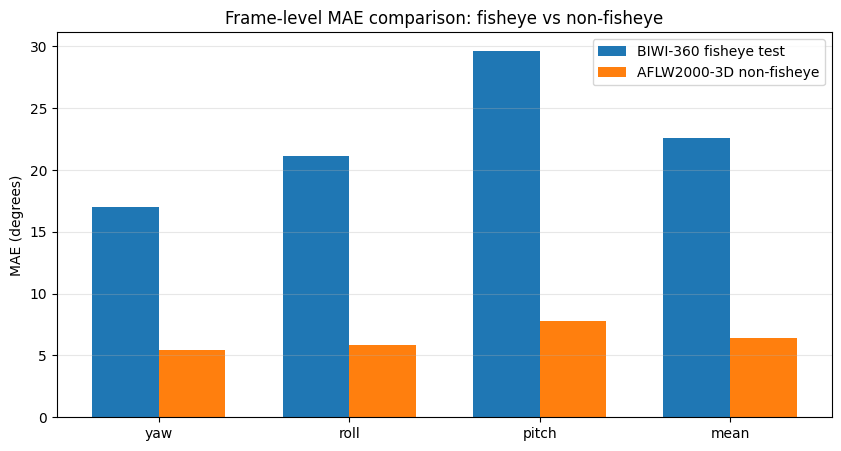

/tmp/ipykernel_24/3720858285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


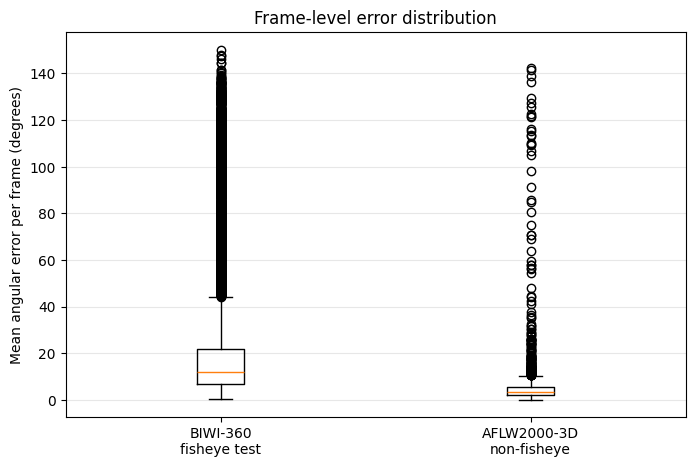

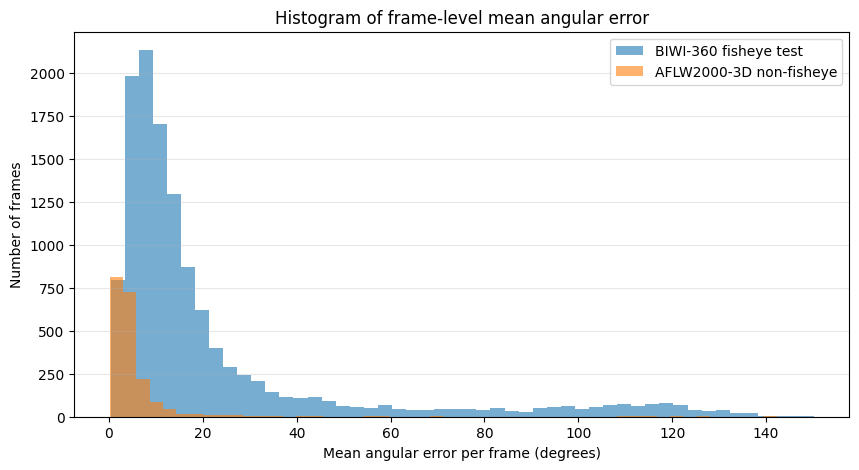

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# --- Bar plot: MAE by angle for both datasets ---
angle_labels = ["yaw", "roll", "pitch", "mean"]
biwi_mae_values = [
    dataset_comparison.loc[dataset_comparison["dataset"] == "BIWI-360 fisheye test", "mae_yaw"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "BIWI-360 fisheye test", "mae_roll"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "BIWI-360 fisheye test", "mae_pitch"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "BIWI-360 fisheye test", "mean_mae"].iloc[0],
]

aflw_mae_values = [
    dataset_comparison.loc[dataset_comparison["dataset"] == "AFLW2000-3D non-fisheye", "mae_yaw"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "AFLW2000-3D non-fisheye", "mae_roll"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "AFLW2000-3D non-fisheye", "mae_pitch"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "AFLW2000-3D non-fisheye", "mean_mae"].iloc[0],
]

x = np.arange(len(angle_labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, biwi_mae_values, width, label="BIWI-360 fisheye test")
plt.bar(x + width / 2, aflw_mae_values, width, label="AFLW2000-3D non-fisheye")

plt.xticks(x, angle_labels)
plt.ylabel("MAE (degrees)")
plt.title("Frame-level MAE comparison: fisheye vs non-fisheye")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# --- Boxplot: mean error distribution ---
biwi_test_errors = final_smoothed_df[final_smoothed_df["split"] == "test"]["err_mean"].values
aflw_errors = aflw_pred_df["err_mean"].values

plt.figure(figsize=(8, 5))
plt.boxplot(
    [biwi_test_errors, aflw_errors],
    labels=["BIWI-360\nfisheye test", "AFLW2000-3D\nnon-fisheye"],
    showfliers=True
)
plt.ylabel("Mean angular error per frame (degrees)")
plt.title("Frame-level error distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()

# --- Histogram: error distribution with same range ---
plt.figure(figsize=(10, 5))
plt.hist(biwi_test_errors, bins=50, alpha=0.6, label="BIWI-360 fisheye test")
plt.hist(aflw_errors, bins=50, alpha=0.6, label="AFLW2000-3D non-fisheye")
plt.xlabel("Mean angular error per frame (degrees)")
plt.ylabel("Number of frames")
plt.title("Histogram of frame-level mean angular error")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


### 13.8 Standard angle-range protocol check

Some head pose papers report AFLW2000-3D results using a standard angular-range protocol, commonly evaluating only samples whose Euler angles lie within approximately `±99°`. Our previous AFLW2000-3D sanity check used all **2,000** images after wrapping the Euler angles to the principal range.

This section is not intended to exactly reproduce the official benchmark protocol from the original papers, because our setup may differ in checkpoint version, crop procedure and dataset copy. However, reporting the `±99°` subset makes the sanity check more transparent and easier to compare with common head pose evaluation practice.

The filter removes only **31 images**, leaving **1,969** samples within the `±99°` range. As expected, the filtered subset obtains slightly better results:

| Subset | Mean MAE | Mean RMSE |
|---|---:|---:|
| All AFLW2000-3D samples | ≈ 6.39° | ≈ 16.57° |
| AFLW2000-3D within ±99° | ≈ 5.88° | ≈ 14.66° |

The improvement is modest, which means that the sanity-check conclusion does not depend on a small number of extreme AFLW2000-3D samples. The same model still performs much better on non-fisheye AFLW2000-3D than on BIWI-360, reinforcing the interpretation that the BIWI-360 failure is mainly caused by fisheye domain shift.

AFLW2000-3D total frames: 2000
AFLW2000-3D frames within ±99°: 1969
Frames removed by ±99° filter: 31

AFLW2000-3D sanity-check metrics with and without ±99° filtering:


,subset,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse_yaw,rmse_roll,rmse_pitch,mean_rmse
0,all AFLW2000-3D samples,2000,5.476733,5.866819,7.822874,6.388808,10.083944,19.602597,20.038184,16.574909
1,AFLW2000-3D within ±99°,1969,5.318565,5.102971,7.220922,5.880820,9.280864,16.897497,17.812437,14.663599


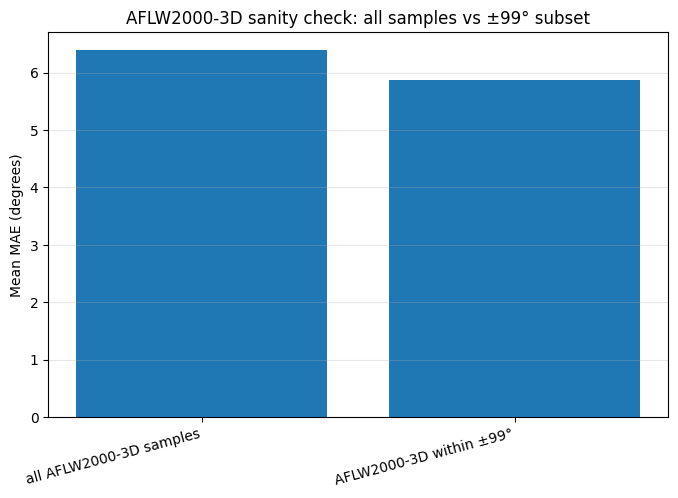

In [54]:
# AFLW2000-3D metrics with and without the common ±99 degree angular range filter

aflw_range_mask = (
    (aflw_pred_df["yaw"].abs() <= 99) &
    (aflw_pred_df["roll"].abs() <= 99) &
    (aflw_pred_df["pitch"].abs() <= 99)
)

print("AFLW2000-3D total frames:", len(aflw_pred_df))
print("AFLW2000-3D frames within ±99°:", int(aflw_range_mask.sum()))
print("Frames removed by ±99° filter:", int((~aflw_range_mask).sum()))

aflw_range_comparison = pd.DataFrame([
    summarize_aflw_subset(aflw_pred_df, "all AFLW2000-3D samples"),
    summarize_aflw_subset(aflw_pred_df[aflw_range_mask].copy(), "AFLW2000-3D within ±99°"),
])

print("\nAFLW2000-3D sanity-check metrics with and without ±99° filtering:")
display(aflw_range_comparison)

# Plot the comparison
plt.figure(figsize=(8, 5))
plt.bar(
    aflw_range_comparison["subset"],
    aflw_range_comparison["mean_mae"]
)
plt.ylabel("Mean MAE (degrees)")
plt.title("AFLW2000-3D sanity check: all samples vs ±99° subset")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()


### 13.9 Sanity check conclusion

The AFLW2000-3D sanity check confirms that the 6DRepNet360 inference pipeline is working correctly under standard, non-fisheye image conditions. Using the same pretrained model, the same angle convention and the same metric implementation, the model obtains much lower error on AFLW2000-3D than on BIWI-360.

On all AFLW2000-3D samples, the model reaches a mean MAE of approximately **6.39°**. When applying the common `±99°` angle-range filter, only **31 out of 2,000** samples are removed, and the mean MAE decreases slightly to approximately **5.88°**.

These values are not intended to exactly reproduce the benchmark numbers reported in the literature, because our checkpoint, crop procedure and dataset copy may not match the original protocol exactly. However, they are sufficient for the purpose of this project: verifying that the model behaves reasonably on conventional perspective face images.

Therefore, the much larger error on BIWI-360 is unlikely to be caused by a basic implementation problem in model loading, preprocessing, angle conversion or inference. It is more consistent with a strong **fisheye domain shift** caused by the radial distortion and frame-wise geometric deformation in HPE-360.

This motivates the next section, where we analyze BIWI-360 more deeply through sensitivity analysis and simple baselines.

## 14. BIWI-360 sensitivity analysis and simple baselines

The previous sections reported the main BIWI-360 test results using the full test split. However, the failure analysis showed that the zero-shot model is strongly affected by fisheye deformation and by isolated extreme predictions near the angular boundary.

In this section, we perform a diagnostic sensitivity analysis to better understand why the pretrained frame-by-frame model performs poorly on BIWI-360. This analysis does not replace the main evaluation. Instead, it helps identify which factors contribute most to the error.

We analyze four aspects:

1. whether the error increases with the fisheye radial parameter `rho`;
2. whether the common `±99°` angle-range protocol changes the BIWI-360 evaluation;
3. whether 6DRepNet360 performs better than simple constant baselines;
4. how much extreme raw prediction outliers affect frame-level accuracy and temporal smoothing.

Before running these analyses, we collect the main test-set objects produced by the previous sections and define an **extreme raw prediction** flag. A frame is marked as extreme when at least one raw predicted angle has absolute value above `150°`. This flag is based only on the raw model output, not on the ground-truth error.

The reference BIWI-360 test results are:

| Metric | Raw | EMA-smoothed |
|---|---:|---:|
| Mean MAE | ≈ 22.60° | ≈ 19.94° |
| Mean prediction jitter | ≈ 44.27°/frame | ≈ 9.22°/frame |
| Mean temporal motion error | ≈ 44.27°/frame | ≈ 9.29°/frame |

The test split contains **12,629 frames**. Among them, **659 frames** contain at least one extreme raw predicted angle, corresponding to about **5.2%** of the test set.

The results in this section should be interpreted as diagnostic analyses, not as alternative benchmark numbers. The main zero-shot result remains the full BIWI-360 test evaluation reported earlier.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_objects = [
    "final_smoothed_df",
    "raw_temporal_df",
    "final_smoothed_temporal_df",
    "frame_raw_vs_smooth",
    "temporal_raw_vs_smooth",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "The following required objects are missing. "
        "Please run the main BIWI-360 experiment before Section 14: "
        + ", ".join(missing_objects)
    )

# Main BIWI-360 test table used throughout Appendix B
biwi_test_df = final_smoothed_df[final_smoothed_df["split"] == "test"].copy()

# Add an extreme raw prediction flag.
# This is based only on the raw model output, not on the ground-truth error.
biwi_test_df["has_extreme_raw_angle"] = (
    (biwi_test_df["pred_yaw"].abs() > 150) |
    (biwi_test_df["pred_roll"].abs() > 150) |
    (biwi_test_df["pred_pitch"].abs() > 150)
)

# Official reference results from the main experiment
official_frame_test = frame_raw_vs_smooth[frame_raw_vs_smooth["split"] == "test"].iloc[0]
official_temporal_test = temporal_raw_vs_smooth[temporal_raw_vs_smooth["split"] == "test"].iloc[0]

official_reference = pd.DataFrame([
    {
        "metric_group": "Frame-level accuracy",
        "metric": "Mean MAE",
        "raw": official_frame_test["raw_mean_mae"],
        "smoothed": official_frame_test["smooth_mean_mae"],
        "change_smooth_minus_raw": official_frame_test["delta_mean_mae"],
    },
    {
        "metric_group": "Temporal stability",
        "metric": "Mean prediction jitter",
        "raw": official_temporal_test["raw_mean_jitter"],
        "smoothed": official_temporal_test["smooth_mean_jitter"],
        "change_smooth_minus_raw": official_temporal_test["delta_jitter"],
    },
    {
        "metric_group": "Temporal consistency",
        "metric": "Mean temporal motion error",
        "raw": official_temporal_test["raw_temporal_motion_error"],
        "smoothed": official_temporal_test["smooth_temporal_motion_error"],
        "change_smooth_minus_raw": official_temporal_test["delta_temporal_motion_error"],
    },
])

print("BIWI-360 test frames used in Section 14:", len(biwi_test_df))
print("Frames with at least one extreme raw predicted angle:",
      int(biwi_test_df["has_extreme_raw_angle"].sum()))
print("Extreme raw angle rate (%):",
      100.0 * biwi_test_df["has_extreme_raw_angle"].mean())

print("\nOfficial BIWI-360 test reference metrics:")
display(official_reference)


BIWI-360 test frames used in Appendix B: 12629
Frames with at least one extreme raw predicted angle: 659
Extreme raw angle rate (%): 5.218148705360678

Official BIWI-360 test reference metrics:


,metric_group,metric,raw,smoothed,change_smooth_minus_raw
0,Frame-level accuracy,Mean MAE,22.596264,19.936329,-2.659935
1,Temporal stability,Mean prediction jitter,44.273643,9.223032,-35.050611
2,Temporal consistency,Mean temporal motion error,44.272610,9.291907,-34.980702


### 14.1 Error by fisheye distortion level

We first analyze performance by `rho`, the normalized radial position used to generate the fisheye distortion. Larger `rho` values indicate that the face was placed farther from the fisheye center before distortion, which generally leads to stronger geometric deformation.

We split the valid `rho` range `[0, 0.8]` into three fixed intervals: low, medium and high. This split uses only dataset metadata and does not depend on model error, so it is not a post-hoc filtering criterion.

The results show a clear relation between fisheye distortion strength and model error. The raw mean MAE increases from approximately **18.85°** at low `rho`, to **20.63°** at medium `rho`, and to **28.35°** at high `rho`. The percentage of frames with at least one extreme raw prediction also increases, reaching about **7.7%** in the high-`rho` group.

EMA smoothing behaves differently across distortion levels. It slightly worsens the low-`rho` subset, has a small positive effect at medium `rho`, and strongly improves the high-`rho` subset, reducing the mean MAE from approximately **28.35°** to **20.09°**. This suggests that smoothing is most useful when the raw predictions are highly unstable, but it may be less beneficial when the input is already less distorted.

Overall, this analysis supports the domain-shift interpretation: the zero-shot model degrades as the fisheye radial position increases, and high-`rho` frames produce more extreme prediction outliers.

Frame-level BIWI-360 test metrics by rho level:


,rho_level,num_frames,mean_rho,raw_mae_yaw,raw_mae_roll,raw_mae_pitch,raw_mean_mae,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,extreme_raw_angle_rate_percent,delta_smooth_minus_raw_mae
0,low rho,4272,0.133492,15.354798,16.906745,24.298531,18.853358,13.469818,18.312541,26.902289,19.561549,4.026217,0.708191
1,medium rho,4158,0.401450,15.701070,18.787271,27.409839,20.632727,13.401146,19.108569,27.977659,20.162458,3.944204,-0.470268
2,high rho,4199,0.665275,19.938916,27.754106,37.352794,28.348605,13.371616,19.383957,27.525533,20.093702,7.692308,-8.254903


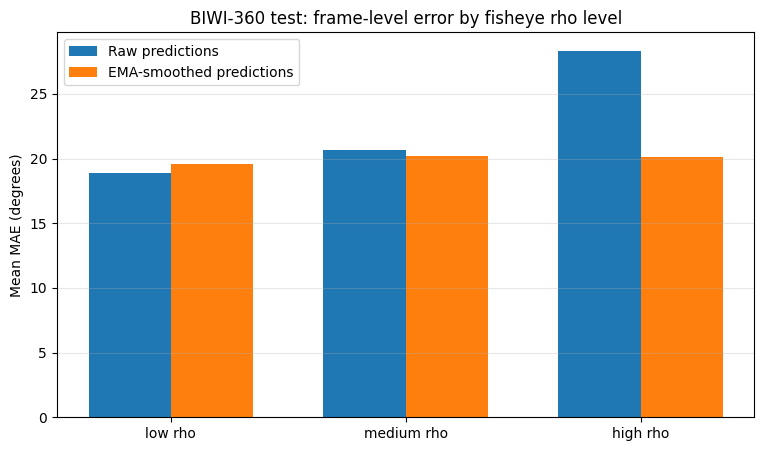

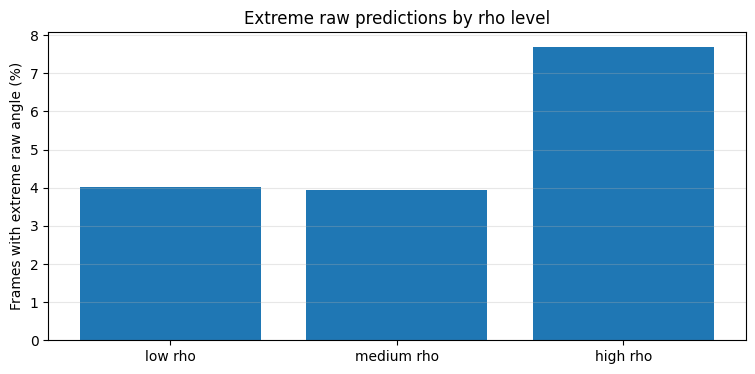

In [ ]:
# Section 14.1: Frame-level raw and smoothed errors by rho level

rho_bins = [0.0, 0.8 / 3, 2 * 0.8 / 3, 0.8 + 1e-6]
rho_labels = ["low rho", "medium rho", "high rho"]

biwi_test_df["rho_level"] = pd.cut(
    biwi_test_df["rho"],
    bins=rho_bins,
    labels=rho_labels,
    include_lowest=True
)

rho_frame_summary = (
    biwi_test_df
    .groupby("rho_level", observed=False)
    .agg(
        num_frames=("frame_id", "count"),
        mean_rho=("rho", "mean"),
        raw_mae_yaw=("err_yaw", "mean"),
        raw_mae_roll=("err_roll", "mean"),
        raw_mae_pitch=("err_pitch", "mean"),
        raw_mean_mae=("err_mean", "mean"),
        smooth_mae_yaw=("smooth_err_yaw", "mean"),
        smooth_mae_roll=("smooth_err_roll", "mean"),
        smooth_mae_pitch=("smooth_err_pitch", "mean"),
        smooth_mean_mae=("smooth_err_mean", "mean"),
        extreme_raw_angle_rate_percent=("has_extreme_raw_angle", lambda x: 100.0 * x.mean()),
    )
    .reset_index()
)

rho_frame_summary["delta_smooth_minus_raw_mae"] = (
    rho_frame_summary["smooth_mean_mae"] - rho_frame_summary["raw_mean_mae"]
)

print("Frame-level BIWI-360 test metrics by rho level:")
display(rho_frame_summary)

# Plot raw vs smoothed mean MAE by rho level
plt.figure(figsize=(9, 5))
x = np.arange(len(rho_frame_summary))
width = 0.35

plt.bar(
    x - width / 2,
    rho_frame_summary["raw_mean_mae"],
    width,
    label="Raw predictions"
)
plt.bar(
    x + width / 2,
    rho_frame_summary["smooth_mean_mae"],
    width,
    label="EMA-smoothed predictions"
)

plt.xticks(x, rho_frame_summary["rho_level"])
plt.ylabel("Mean MAE (degrees)")
plt.title("BIWI-360 test: frame-level error by fisheye rho level")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Plot extreme raw angle rate by rho level
plt.figure(figsize=(9, 4))
plt.bar(
    rho_frame_summary["rho_level"],
    rho_frame_summary["extreme_raw_angle_rate_percent"]
)
plt.ylabel("Frames with extreme raw angle (%)")
plt.title("Extreme raw predictions by rho level")
plt.grid(axis="y", alpha=0.3)
plt.show()


### 14.2 Standard angle-range filtering

Some head pose evaluation protocols report results after restricting the test samples to a bounded Euler-angle range, commonly `±99°`. Since BIWI-360 is derived from BIWI and its ground-truth poses are already relatively bounded, we check whether this filter changes the BIWI-360 test evaluation.

This check is useful because the AFLW2000-3D sanity check changed slightly after applying the same filter. If BIWI-360 is already fully inside the `±99°` range, then the poor BIWI-360 performance cannot be explained by unusually extreme ground-truth poses.

The result confirms that all **12,629** BIWI-360 test frames are already within the `±99°` range. Therefore, the filter removes **0 frames** and does not change the test metrics.

This means that the high BIWI-360 error is not caused by evaluating poses outside the standard angular range. The problem is more consistent with the fisheye domain shift and the instability of the zero-shot predictions, rather than with an unusually difficult ground-truth pose distribution.

In [ ]:
# Section 14.2: Standard ±99 degree GT angle filter on BIWI-360

biwi_range_mask = (
    (biwi_test_df["yaw"].abs() <= 99) &
    (biwi_test_df["roll"].abs() <= 99) &
    (biwi_test_df["pitch"].abs() <= 99)
)

num_total = len(biwi_test_df)
num_within_range = int(biwi_range_mask.sum())
num_removed = int((~biwi_range_mask).sum())

biwi_range_filter_check = pd.DataFrame([{
    "total_test_frames": num_total,
    "frames_within_±99°": num_within_range,
    "frames_removed_by_filter": num_removed,
    "percentage_removed": 100.0 * num_removed / num_total,
    "raw_mean_mae_all_frames": biwi_test_df["err_mean"].mean(),
    "smooth_mean_mae_all_frames": biwi_test_df["smooth_err_mean"].mean(),
}])

print("BIWI-360 ±99° angle-range filtering check:")
display(biwi_range_filter_check)

if num_removed == 0:
    print(
        "All BIWI-360 test frames are already within the ±99° ground-truth angle range. "
        "Therefore, this standard filtering protocol does not change the BIWI-360 test metrics."
    )


BIWI-360 ±99° angle-range filtering check:


,total_test_frames,frames_within_±99°,frames_removed_by_filter,percentage_removed,raw_mean_mae_all_frames,smooth_mean_mae_all_frames
0,12629,12629,0,0.0,22.596264,19.936329


All BIWI-360 test frames are already within the ±99° ground-truth angle range. Therefore, this standard filtering protocol does not change the BIWI-360 test metrics.


### 14.3 Simple baseline comparison

We now compare 6DRepNet360 against simple constant baselines on the BIWI-360 test split. The goal is to understand whether the pretrained model extracts useful pose information under fisheye distortion, or whether its zero-shot predictions are so unstable that simple predictors become competitive.

We evaluate three baselines:

- **Zero-pose baseline:** always predicts `yaw = roll = pitch = 0`.
- **Validation-mean baseline:** always predicts the circular mean pose computed from the validation split.
- **Oracle sequence-mean baseline:** predicts the circular mean ground-truth pose of each test sequence.

The oracle sequence-mean baseline is not deployable because it uses test labels. It is included only as an upper-reference constant baseline, to measure how much sequence-level pose bias exists in BIWI-360.

The results show that the constant baselines outperform the raw and EMA-smoothed 6DRepNet360 predictions in global mean MAE. The validation-mean baseline obtains approximately **17.55°**, compared with **22.60°** for raw 6DRepNet360 and **19.94°** after EMA smoothing. This is an important result and should not be hidden.

The reason is that the BIWI-360 pose distribution is relatively centered, especially for **roll**. A constant predictor can therefore be surprisingly strong on some axes. In contrast, the pretrained frame-by-frame model produces large outliers under fisheye distortion, particularly in **roll** and **pitch**. These outliers increase the average error enough for simple baselines to outperform the model in global frame-level accuracy.

This does not mean that the implementation is broken. The AFLW2000-3D sanity check showed that the same model, preprocessing and angle convention perform much better on non-fisheye images. Instead, this result suggests that zero-shot 6DRepNet360 is not reliable on BIWI-360 without domain adaptation or a fisheye-aware training strategy.

The axis-level errors also show a more nuanced behavior: 6DRepNet360 performs better on **yaw** than the constant baselines, especially after EMA smoothing. However, it performs much worse on **roll** and **pitch**, where the dataset distribution is more centered and the model is more affected by extreme prediction outliers.

Overall, this comparison reveals an axis-dependent failure mode: under fisheye distortion, the pretrained model still captures useful yaw information, but its roll and pitch predictions are too unstable. This motivates the later robust filtering and fisheye-aware adaptation experiments.

Validation circular mean pose:
yaw=8.90, roll=-0.13, pitch=13.09

BIWI-360 test: model vs simple baselines


,method,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse_yaw,rmse_roll,rmse_pitch,mean_rmse
0,6DRepNet360 raw,12629,16.992973,21.132519,29.663300,22.596264,25.984591,44.367790,48.104056,39.485479
1,6DRepNet360 + EMA,12629,13.414557,18.930861,27.463568,19.936329,18.371469,38.004817,44.561206,33.645831
2,Zero-pose baseline,12629,24.283217,9.091160,22.660551,18.678309,30.960283,13.217287,27.539979,23.905850
3,Validation-mean baseline,12629,23.565473,9.091692,19.986305,17.547823,30.007969,13.219040,26.660303,23.295771
4,Oracle sequence-mean baseline,12629,22.802194,8.709599,17.602722,16.371505,29.521051,12.598670,22.766385,21.628702


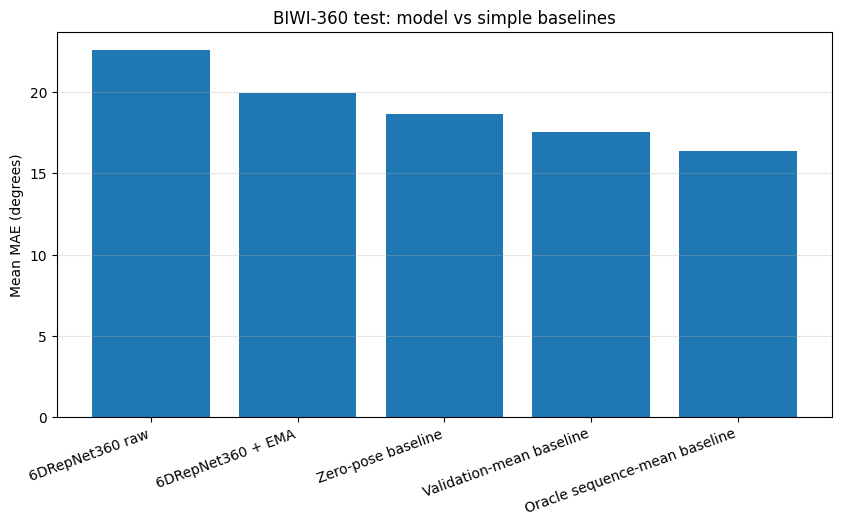

In [ ]:
# Section 14.3: Simple baseline comparison

baseline_df = biwi_test_df.copy()

# Zero-pose predictor
baseline_df["zero_yaw"] = 0.0
baseline_df["zero_roll"] = 0.0
baseline_df["zero_pitch"] = 0.0

# Validation-mean predictor, estimated only from validation split
validation_df = final_smoothed_df[final_smoothed_df["split"] == "validation"].copy()

mean_yaw_val = circular_mean_deg(validation_df["yaw"])
mean_roll_val = circular_mean_deg(validation_df["roll"])
mean_pitch_val = circular_mean_deg(validation_df["pitch"])

baseline_df["valmean_yaw"] = mean_yaw_val
baseline_df["valmean_roll"] = mean_roll_val
baseline_df["valmean_pitch"] = mean_pitch_val

print("Validation circular mean pose:")
print(f"yaw={mean_yaw_val:.2f}, roll={mean_roll_val:.2f}, pitch={mean_pitch_val:.2f}")

# Oracle sequence mean predictor: not a fair deployable baseline
baseline_df["oracle_seqmean_yaw"] = np.nan
baseline_df["oracle_seqmean_roll"] = np.nan
baseline_df["oracle_seqmean_pitch"] = np.nan

for seq_id, seq_df in baseline_df.groupby("sequence_id"):
    idx = seq_df.index
    
    baseline_df.loc[idx, "oracle_seqmean_yaw"] = circular_mean_deg(seq_df["yaw"])
    baseline_df.loc[idx, "oracle_seqmean_roll"] = circular_mean_deg(seq_df["roll"])
    baseline_df.loc[idx, "oracle_seqmean_pitch"] = circular_mean_deg(seq_df["pitch"])

baseline_results = pd.DataFrame([
    evaluate_prediction_columns(baseline_df, "pred_yaw", "pred_roll", "pred_pitch", "6DRepNet360 raw"),
    evaluate_prediction_columns(baseline_df, "smooth_pred_yaw", "smooth_pred_roll", "smooth_pred_pitch", "6DRepNet360 + EMA"),
    evaluate_prediction_columns(baseline_df, "zero_yaw", "zero_roll", "zero_pitch", "Zero-pose baseline"),
    evaluate_prediction_columns(baseline_df, "valmean_yaw", "valmean_roll", "valmean_pitch", "Validation-mean baseline"),
    evaluate_prediction_columns(baseline_df, "oracle_seqmean_yaw", "oracle_seqmean_roll", "oracle_seqmean_pitch", "Oracle sequence-mean baseline"),
])

print("\nBIWI-360 test: model vs simple baselines")
display(baseline_results)

# Plot model vs baselines
plt.figure(figsize=(10, 5))
plt.bar(
    baseline_results["method"],
    baseline_results["mean_mae"]
)
plt.ylabel("Mean MAE (degrees)")
plt.title("BIWI-360 test: model vs simple baselines")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()


### 14.4 Sensitivity to extreme prediction outliers

The baseline comparison suggests that the poor frame-level performance is strongly affected by unstable predictions and extreme outliers. We now quantify this effect more directly.

A frame is marked as an **extreme raw prediction** if at least one predicted angle has absolute value above `150°`. This threshold is not based on the ground-truth error; it only detects raw model outputs close to the angular boundary.

We analyze frame-level metrics for three subsets:

- all test frames;
- frames with at least one extreme raw angle;
- frames without extreme raw angles.

For temporal metrics, a consecutive pair is considered affected by an extreme raw prediction if either the current or previous frame contains an extreme raw angle.

The results show that extreme raw predictions have a very large impact on the BIWI-360 evaluation. Only **659 test frames** contain at least one extreme raw angle, but their raw mean MAE is approximately **110.34°**, compared with **17.77°** for frames without extreme raw predictions.

EMA smoothing strongly reduces the error on these extreme frames, from approximately **110.34°** to **65.93°**, but the remaining error is still very high. For frames without extreme raw predictions, EMA has only a small effect, slightly reducing the mean MAE from approximately **17.77°** to **17.40°**.

The temporal metrics show the same pattern. Consecutive pairs affected by extreme raw predictions have a raw mean jitter of approximately **152.74°/frame**, while pairs not affected by extreme predictions still have a raw mean jitter of approximately **33.95°/frame**. After EMA, these values decrease to approximately **29.67°/frame** and **7.27°/frame**, respectively.

Therefore, extreme outliers explain the worst temporal failures, but they are not the only source of instability. Even pairs without extreme boundary predictions remain much more jittery than the underlying ground-truth motion.

Overall, EMA is effective as a simple jitter-reduction method, but it does not fully solve the problem. It reduces the impact of isolated outliers, but large errors can still remain after smoothing. This motivates testing more robust temporal filtering methods that combine smoothing with explicit outlier handling.

Frame-level sensitivity to extreme raw prediction outliers:


,subset,num_frames,extreme_raw_angle_rate_percent,raw_mean_mae,smooth_mean_mae,delta_smooth_minus_raw_mae,raw_mae_yaw,raw_mae_roll,raw_mae_pitch,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch
0,all test frames,12629,5.218149,22.596264,19.936329,-2.659935,16.992973,21.132519,29.663300,13.414557,18.930861,27.463568
1,frames with extreme raw angle,659,100.000000,110.339710,65.934013,-44.405696,37.398353,152.188877,141.431899,23.662900,86.849436,87.289704
2,frames without extreme raw angle,11970,0.000000,17.765610,17.403958,-0.361652,15.869569,13.917303,23.509958,12.850342,15.191651,24.169882



Temporal sensitivity to extreme raw prediction outliers:


,subset,num_raw_pairs,num_smooth_pairs,raw_mean_jitter,smooth_mean_jitter,jitter_reduction_percent,raw_temporal_motion_error,smooth_temporal_motion_error,temporal_error_reduction_percent
0,all test consecutive pairs,12585,12565,44.273643,9.223032,79.168120,44.272610,9.291907,79.012063
1,pairs affected by extreme raw angle,1094,1094,152.739769,29.667547,80.576410,152.895201,30.136791,80.289250
2,pairs not affected by extreme raw angle,11491,11471,33.947131,7.273220,78.574862,33.931202,7.303911,78.474351


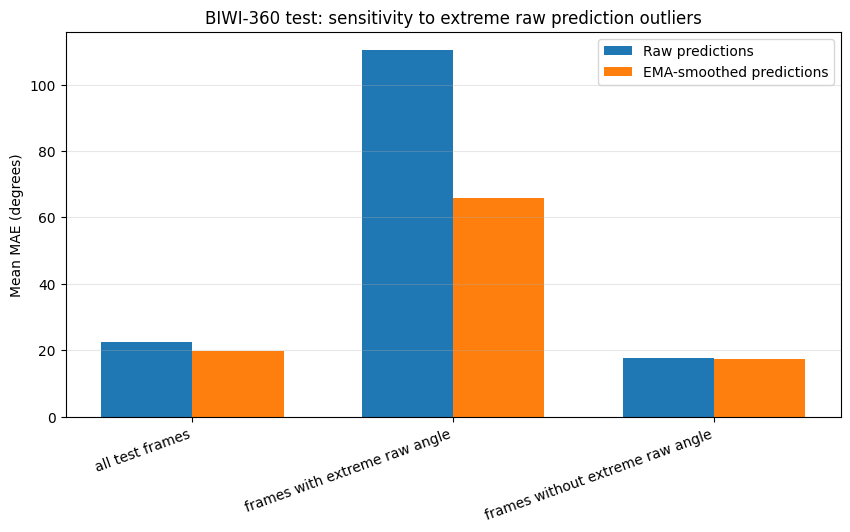

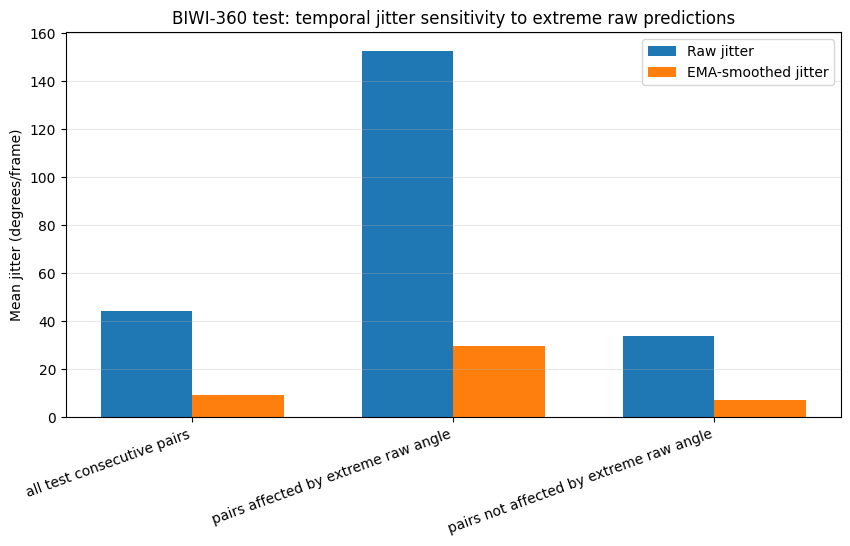

In [ ]:
# Section 14.4: Sensitivity analysis for extreme raw prediction outliers

outlier_analysis_df = biwi_test_df.copy()

frame_outlier_sensitivity = pd.DataFrame([
    summarize_frame_outlier_subset(outlier_analysis_df, "all test frames"),
    summarize_frame_outlier_subset(
        outlier_analysis_df[outlier_analysis_df["has_extreme_raw_angle"]],
        "frames with extreme raw angle"
    ),
    summarize_frame_outlier_subset(
        outlier_analysis_df[~outlier_analysis_df["has_extreme_raw_angle"]],
        "frames without extreme raw angle"
    ),
])

print("Frame-level sensitivity to extreme raw prediction outliers:")
display(frame_outlier_sensitivity)

# Temporal sensitivity
frame_flags = outlier_analysis_df[
    ["sequence_id", "frame_id", "has_extreme_raw_angle"]
].copy()

raw_temporal_test = raw_temporal_df[raw_temporal_df["split"] == "test"].copy()
smooth_temporal_test = final_smoothed_temporal_df[
    final_smoothed_temporal_df["split"] == "test"
].copy()

raw_temporal_test_flags = attach_pair_outlier_flags(raw_temporal_test, frame_flags)
smooth_temporal_test_flags = attach_pair_outlier_flags(smooth_temporal_test, frame_flags)

temporal_outlier_sensitivity = pd.DataFrame([
    summarize_temporal_outlier_subset(
        raw_temporal_test_flags,
        smooth_temporal_test_flags,
        lambda df: pd.Series(True, index=df.index),
        "all test consecutive pairs"
    ),
    summarize_temporal_outlier_subset(
        raw_temporal_test_flags,
        smooth_temporal_test_flags,
        lambda df: df["pair_has_extreme_raw_angle"],
        "pairs affected by extreme raw angle"
    ),
    summarize_temporal_outlier_subset(
        raw_temporal_test_flags,
        smooth_temporal_test_flags,
        lambda df: ~df["pair_has_extreme_raw_angle"],
        "pairs not affected by extreme raw angle"
    ),
])

print("\nTemporal sensitivity to extreme raw prediction outliers:")
display(temporal_outlier_sensitivity)

# Plot frame-level sensitivity
plt.figure(figsize=(10, 5))
x = np.arange(len(frame_outlier_sensitivity))
width = 0.35

plt.bar(
    x - width / 2,
    frame_outlier_sensitivity["raw_mean_mae"],
    width,
    label="Raw predictions"
)
plt.bar(
    x + width / 2,
    frame_outlier_sensitivity["smooth_mean_mae"],
    width,
    label="EMA-smoothed predictions"
)

plt.xticks(x, frame_outlier_sensitivity["subset"], rotation=20, ha="right")
plt.ylabel("Mean MAE (degrees)")
plt.title("BIWI-360 test: sensitivity to extreme raw prediction outliers")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Plot temporal sensitivity
plt.figure(figsize=(10, 5))
x = np.arange(len(temporal_outlier_sensitivity))

plt.bar(
    x - width / 2,
    temporal_outlier_sensitivity["raw_mean_jitter"],
    width,
    label="Raw jitter"
)
plt.bar(
    x + width / 2,
    temporal_outlier_sensitivity["smooth_mean_jitter"],
    width,
    label="EMA-smoothed jitter"
)

plt.xticks(x, temporal_outlier_sensitivity["subset"], rotation=20, ha="right")
plt.ylabel("Mean jitter (degrees/frame)")
plt.title("BIWI-360 test: temporal jitter sensitivity to extreme raw predictions")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


### 14.5 Where does the model still add value?

The previous baseline comparison showed that simple constant predictors outperform zero-shot 6DRepNet360 in overall mean MAE on BIWI-360. However, this global result hides important axis-specific behavior.

In particular, **yaw** has the largest variation in the BIWI-360 labels, and it is also the angle where the model performs best relative to the trivial baselines. This suggests that the model still extracts useful pose information for horizontal head orientation, even though roll and pitch are strongly affected by fisheye distortion and extreme outliers.

We therefore compare the model and the baselines per axis, both on the full test split and across the different `rho` levels.

The axis-specific results show that the best non-oracle method for **yaw** is **6DRepNet360 + EMA**, with a yaw MAE of approximately **13.41°**. This is clearly better than the zero-pose baseline and the validation-mean baseline, which are both around **24°** for yaw.

However, the picture is very different for **roll** and **pitch**. For roll, the zero-pose baseline is the best non-oracle method, with an MAE of approximately **9.09°**, while 6DRepNet360 raw and EMA are much worse. For pitch, the validation-mean baseline is best, with an MAE of approximately **19.99°**, again outperforming the model.

The comparison by `rho` level confirms this pattern. Across all distortion levels, the raw model improves yaw MAE over the validation-mean baseline. The improvement is strongest for low and medium `rho`, where yaw error is reduced by more than **30%** relative to the validation-mean baseline. Even at high `rho`, where fisheye distortion is stronger, the raw model still improves yaw by approximately **15%**.

This useful yaw information is offset by much worse roll and pitch errors, especially at high `rho`. In the high-`rho` group, the raw model reaches approximately **27.75°** MAE for roll and **37.35°** for pitch, while the validation-mean baseline remains around **9.10°** for roll and **19.84°** for pitch.

After excluding frames with extreme raw predictions, the model becomes much more competitive. The raw model reaches approximately **17.77°** mean MAE and the EMA-smoothed model reaches approximately **17.40°**, both outperforming the zero-pose baseline. However, the validation-mean baseline remains slightly better at approximately **17.23°**.

Overall, this analysis shows that zero-shot 6DRepNet360 is not completely uninformative on BIWI-360. It captures useful yaw information, but its roll and pitch predictions are too unstable under fisheye distortion. This axis-dependent failure explains why the model can add value in one direction while still losing to simple baselines in the overall mean MAE. It also motivates the next steps: robust filtering to reduce outliers, and fisheye-aware adaptation to improve the pose estimator itself.

Axis-specific MAE comparison on all BIWI-360 test frames:


,subset,method,mae_yaw,mae_roll,mae_pitch,mean_mae
0,all test frames,6DRepNet360 raw,16.992973,21.132519,29.663300,22.596264
1,all test frames,6DRepNet360 + EMA,13.414557,18.930861,27.463568,19.936329
2,all test frames,Zero-pose baseline,24.283217,9.091160,22.660551,18.678309
3,all test frames,Validation-mean baseline,23.565473,9.091692,19.986305,17.547823
4,all test frames,Oracle sequence-mean baseline,22.802194,8.709599,17.602722,16.371505



Best non-oracle method by metric:


,metric,best_non_oracle_method,best_value
0,mae_yaw,6DRepNet360 + EMA,13.414557
1,mae_roll,Zero-pose baseline,9.091160
2,mae_pitch,Validation-mean baseline,19.986305
3,mean_mae,Validation-mean baseline,17.547823



Raw model vs baselines by rho level and angle:


,rho_level,angle,num_frames,raw_model_mae,ema_model_mae,zero_baseline_mae,validation_mean_baseline_mae,raw_minus_valmean,raw_improvement_over_valmean_percent
0,low rho,yaw,4272,15.354798,13.469818,24.120549,23.379254,-8.024456,34.322976
1,low rho,roll,4272,16.906745,18.312541,9.163182,9.160974,7.745771,-84.551828
2,low rho,pitch,4272,24.298531,26.902289,22.590313,20.412196,3.886335,-19.039279
3,medium rho,yaw,4158,15.701070,13.401146,24.341731,23.672526,-7.971456,33.673871
4,medium rho,roll,4158,18.787271,19.108569,9.014715,9.015448,9.771823,-108.389771
5,medium rho,pitch,4158,27.409839,27.977659,22.993933,19.693252,7.716587,-39.183916
6,high rho,yaw,4199,19.938916,13.371616,24.390772,23.648923,-3.710007,15.687849
7,high rho,roll,4199,27.754106,19.383957,9.093584,9.096704,18.657403,-205.100700
8,high rho,pitch,4199,37.352794,27.525533,22.401883,19.843201,17.509593,-88.239759



Axis-specific MAE comparison after excluding frames with extreme raw predictions:


,subset,method,mae_yaw,mae_roll,mae_pitch,mean_mae
0,frames without extreme raw angle,6DRepNet360 raw,15.869569,13.917303,23.509958,17.765610
1,frames without extreme raw angle,6DRepNet360 + EMA,12.850342,15.191651,24.169882,17.403958
2,frames without extreme raw angle,Zero-pose baseline,24.117142,8.986377,21.707023,18.270180
3,frames without extreme raw angle,Validation-mean baseline,23.321890,8.985456,19.380124,17.229156
4,frames without extreme raw angle,Oracle sequence-mean baseline,22.591668,8.613486,17.083405,16.096187


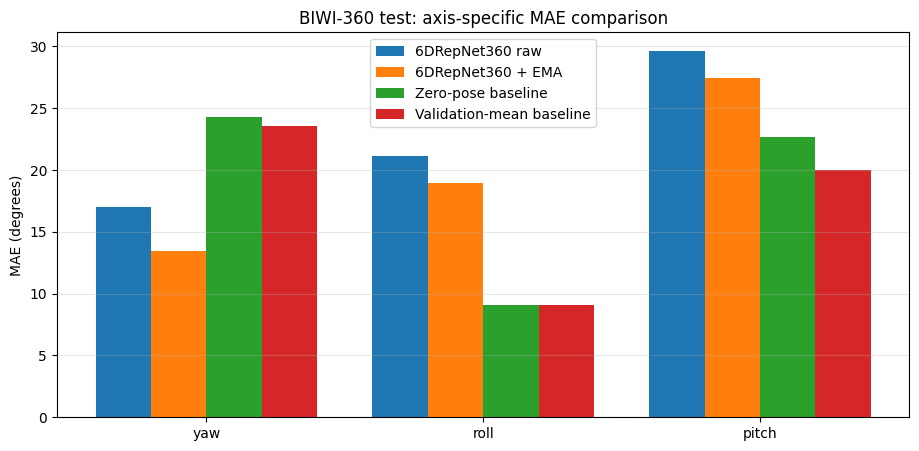

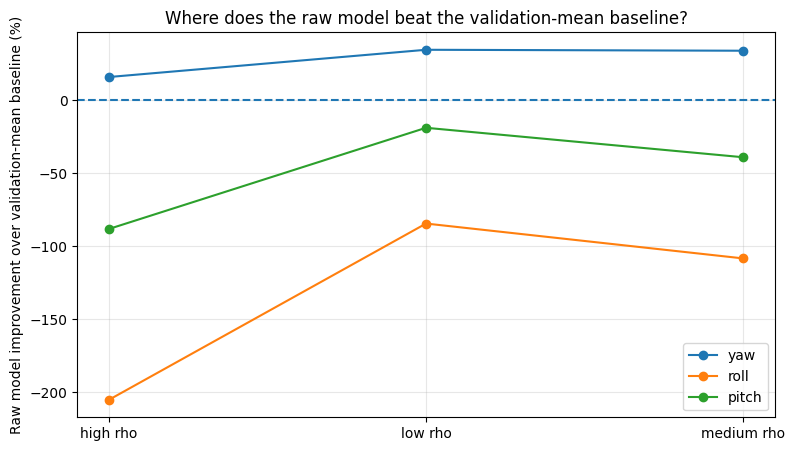

In [ ]:
# Section 14.5: Where does the model still add value?

analysis_df = baseline_df.copy()

# Make sure rho_level exists in this table
if "rho_level" not in analysis_df.columns:
    analysis_df["rho_level"] = pd.cut(
        analysis_df["rho"],
        bins=[0.0, 0.8 / 3, 2 * 0.8 / 3, 0.8 + 1e-6],
        labels=["low rho", "medium rho", "high rho"],
        include_lowest=True
    )

methods = {
    "6DRepNet360 raw": ("pred_yaw", "pred_roll", "pred_pitch"),
    "6DRepNet360 + EMA": ("smooth_pred_yaw", "smooth_pred_roll", "smooth_pred_pitch"),
    "Zero-pose baseline": ("zero_yaw", "zero_roll", "zero_pitch"),
    "Validation-mean baseline": ("valmean_yaw", "valmean_roll", "valmean_pitch"),
    "Oracle sequence-mean baseline": (
        "oracle_seqmean_yaw",
        "oracle_seqmean_roll",
        "oracle_seqmean_pitch"
    ),
}

overall_axis_comparison = axis_mae_table(analysis_df, "all test frames", methods)

print("Axis-specific MAE comparison on all BIWI-360 test frames:")
display(overall_axis_comparison)

# Identify best non-oracle method per axis
non_oracle_axis_comparison = overall_axis_comparison[
    overall_axis_comparison["method"] != "Oracle sequence-mean baseline"
].copy()

best_non_oracle_by_axis = []

for axis_col in ["mae_yaw", "mae_roll", "mae_pitch", "mean_mae"]:
    best_row = non_oracle_axis_comparison.sort_values(axis_col).iloc[0]
    best_non_oracle_by_axis.append({
        "metric": axis_col,
        "best_non_oracle_method": best_row["method"],
        "best_value": best_row[axis_col],
    })

best_non_oracle_by_axis = pd.DataFrame(best_non_oracle_by_axis)

print("\nBest non-oracle method by metric:")
display(best_non_oracle_by_axis)

# Compare raw model vs validation-mean baseline by rho level and angle
rho_axis_rows = []

for rho_level, group in analysis_df.groupby("rho_level", observed=False):
    for angle in ["yaw", "roll", "pitch"]:
        raw_error = angular_diff_array_deg(
            group[f"pred_{angle}"],
            group[angle]
        ).mean()
        
        valmean_error = angular_diff_array_deg(
            group[f"valmean_{angle}"],
            group[angle]
        ).mean()
        
        zero_error = angular_diff_array_deg(
            group[f"zero_{angle}"],
            group[angle]
        ).mean()
        
        smooth_error = angular_diff_array_deg(
            group[f"smooth_pred_{angle}"],
            group[angle]
        ).mean()
        
        rho_axis_rows.append({
            "rho_level": rho_level,
            "angle": angle,
            "num_frames": len(group),
            "raw_model_mae": raw_error,
            "ema_model_mae": smooth_error,
            "zero_baseline_mae": zero_error,
            "validation_mean_baseline_mae": valmean_error,
            "raw_minus_valmean": raw_error - valmean_error,
            "raw_improvement_over_valmean_percent": (
                100.0 * (valmean_error - raw_error) / valmean_error
            ),
        })

rho_axis_comparison = pd.DataFrame(rho_axis_rows)

print("\nRaw model vs baselines by rho level and angle:")
display(rho_axis_comparison)

# Same comparison but excluding extreme raw predictions
non_extreme_df = analysis_df[~analysis_df["has_extreme_raw_angle"]].copy()
non_extreme_axis_comparison = axis_mae_table(
    non_extreme_df,
    "frames without extreme raw angle",
    methods
)

print("\nAxis-specific MAE comparison after excluding frames with extreme raw predictions:")
display(non_extreme_axis_comparison)

# Plot axis-specific comparison for the most relevant non-oracle methods
plot_methods = [
    "6DRepNet360 raw",
    "6DRepNet360 + EMA",
    "Zero-pose baseline",
    "Validation-mean baseline",
]

plot_df = overall_axis_comparison[
    overall_axis_comparison["method"].isin(plot_methods)
].copy()

x = np.arange(3)
width = 0.2
axis_labels = ["yaw", "roll", "pitch"]

plt.figure(figsize=(11, 5))

for i, method_name in enumerate(plot_methods):
    row = plot_df[plot_df["method"] == method_name].iloc[0]
    values = [row["mae_yaw"], row["mae_roll"], row["mae_pitch"]]
    
    plt.bar(
        x + (i - 1.5) * width,
        values,
        width,
        label=method_name
    )

plt.xticks(x, axis_labels)
plt.ylabel("MAE (degrees)")
plt.title("BIWI-360 test: axis-specific MAE comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Plot raw improvement over validation-mean baseline by rho level and angle
pivot_improvement = rho_axis_comparison.pivot(
    index="rho_level",
    columns="angle",
    values="raw_improvement_over_valmean_percent"
)

plt.figure(figsize=(9, 5))
for angle in ["yaw", "roll", "pitch"]:
    plt.plot(
        pivot_improvement.index.astype(str),
        pivot_improvement[angle],
        marker="o",
        label=angle
    )

plt.axhline(0, linestyle="--")
plt.ylabel("Raw model improvement over validation-mean baseline (%)")
plt.title("Where does the raw model beat the validation-mean baseline?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 14.6 Sensitivity analysis conclusion

The BIWI-360 sensitivity analysis provides a more detailed explanation of the poor zero-shot performance.

First, the error increases with the fisheye radial parameter `rho`. Raw mean MAE rises from approximately **18.85°** for low-`rho` frames to approximately **28.35°** for high-`rho` frames. This supports the interpretation that stronger fisheye deformation makes zero-shot head pose estimation more difficult.

Second, the standard `±99°` angle-range filter does not change the BIWI-360 test set, because all test frames are already inside this range. Therefore, the poor BIWI-360 result cannot be explained by evaluating unusually extreme ground-truth head poses.

Third, simple constant baselines outperform zero-shot 6DRepNet360 in overall mean MAE. However, this result is strongly axis-dependent. The model is clearly useful for **yaw**, where both the raw and EMA-smoothed predictions outperform the constant baselines. In fact, the best non-oracle method for yaw is **6DRepNet360 + EMA**. The global failure is mainly caused by **roll** and **pitch**, where the model produces large fisheye-induced outliers and the constant baselines benefit from the centered distribution of those angles.

Fourth, extreme raw predictions are a major source of error. Frames with at least one raw predicted angle above `150°` have much larger error than the rest of the test set. When these frames are excluded, the raw and EMA-smoothed models become much closer to the validation-mean baseline in overall MAE and outperform the zero-pose baseline. This suggests that the model is not completely uninformative, but it is not robust enough under fisheye distortion.

Finally, EMA smoothing strongly reduces temporal jitter, including in pairs affected by extreme predictions. With the balanced smoothing strength selected in Section 10, it also improves the overall frame-level mean MAE. However, the geodesic analysis in Section 10.2 shows that much of this gain is a per-axis averaging effect rather than a genuinely better predicted 3D orientation.

Overall, the pretrained model captures useful yaw information, but its roll and pitch predictions are too unstable for reliable zero-shot use on BIWI-360. The most promising next step is therefore not simply stronger smoothing, but either more robust temporal post-processing or fisheye-aware domain adaptation. In the following sections, we explore these directions through outlier-aware filtering and model adaptation to fisheye-distorted data.

## 15. Robust temporal filtering pilot

The previous analysis showed that a moderate EMA reduces temporal jitter and slightly improves frame-level MAE, but it smooths every prediction equally and is not robust to the isolated extreme outliers in roll and pitch identified in the failure analysis.

In this section, we test more robust temporal post-processing strategies. The goal is to preserve useful pose information, especially yaw, while reducing roll/pitch outliers and temporal jitter.

We evaluate both causal and offline filters:

- causal filters use only the current and previous frames;
- centered filters use both past and future frames, so they are suitable only for offline video post-processing.

All hyperparameters are selected using the validation split only. The test split is used only for the final evaluation of the selected filter.

### 15.1 Validation grid search over robust temporal filters

We now compare several temporal post-processing candidates on the validation split. The search includes rolling median filters, rolling mean filters, median-plus-EMA combinations, and EMA with jump clipping.

The robust-filter helper functions, such as `rolling_median_1d`, `ema_with_jump_clipping_1d`, `apply_temporal_filter_by_sequence` and `summarize_candidate`, are defined in `utils.py` and were imported at the top of the notebook.

The selection criterion is the same balanced validation score used for EMA: frame-level MAE and temporal motion error are both normalized by the raw validation baseline. This avoids selecting a filter that only minimizes jitter by over-smoothing the trajectory and sacrificing accuracy.

In [ ]:
# Section 15.1: Validation grid search over robust temporal filters

import matplotlib.pyplot as plt

# Base dataframe for robust-filter experiments
robust_base_df = final_smoothed_df.copy()
candidate_configs = []

# Rolling median filters
for window_size in [3, 5, 7, 11]:
    candidate_configs.append({
        "method": "rolling_median",
        "params": {"window_size": window_size, "centered": False},
        "name": f"causal median w={window_size}"
    })
    candidate_configs.append({
        "method": "rolling_median",
        "params": {"window_size": window_size, "centered": True},
        "name": f"centered median w={window_size}"
    })

# Rolling mean filters
for window_size in [3, 5, 7, 11]:
    candidate_configs.append({
        "method": "rolling_mean",
        "params": {"window_size": window_size, "centered": False},
        "name": f"causal mean w={window_size}"
    })
    candidate_configs.append({
        "method": "rolling_mean",
        "params": {"window_size": window_size, "centered": True},
        "name": f"centered mean w={window_size}"
    })

# Median followed by EMA
for window_size in [3, 5, 7]:
    for alpha in [0.10, 0.20, 0.30, 0.50]:
        candidate_configs.append({
            "method": "median_then_ema",
            "params": {"window_size": window_size, "centered": True, "alpha": alpha},
            "name": f"centered median w={window_size} + EMA alpha={alpha}"
        })

# EMA with jump clipping
for alpha in [0.10, 0.20, 0.30, 0.50, 0.70]:
    for max_jump_deg in [5, 10, 20, 40]:
        candidate_configs.append({
            "method": "ema_clip",
            "params": {"alpha": alpha, "max_jump_deg": max_jump_deg},
            "name": f"EMA clip alpha={alpha}, jump={max_jump_deg}"
        })

print("Number of candidate filters:", len(candidate_configs))

search_rows = []

# Raw baseline in the same table
raw_candidate_df = robust_base_df.copy()
raw_candidate_df = add_frame_errors_for_prefix(
    raw_candidate_df,
    pred_prefix="pred",
    error_prefix="raw_search_err"
)
raw_candidate_temporal_df = compute_temporal_metrics_for_prefix(
    raw_candidate_df,
    pred_prefix="pred"
)

search_rows.append(
    summarize_candidate(
        raw_candidate_df,
        raw_candidate_temporal_df,
        pred_prefix="pred",
        error_prefix="raw_search_err",
        candidate_name="raw predictions",
        split_name="validation"
    )
)
search_rows.append(
    summarize_candidate(
        raw_candidate_df,
        raw_candidate_temporal_df,
        pred_prefix="pred",
        error_prefix="raw_search_err",
        candidate_name="raw predictions",
        split_name="test"
    )
)

# Original EMA selected earlier
ema_candidate_df = robust_base_df.copy()
ema_candidate_df = add_frame_errors_for_prefix(
    ema_candidate_df,
    pred_prefix="smooth_pred",
    error_prefix="ema_search_err"
)
ema_candidate_temporal_df = compute_temporal_metrics_for_prefix(
    ema_candidate_df,
    pred_prefix="smooth_pred"
)

search_rows.append(
    summarize_candidate(
        ema_candidate_df,
        ema_candidate_temporal_df,
        pred_prefix="smooth_pred",
        error_prefix="ema_search_err",
        candidate_name=f"original EMA alpha={best_alpha}",
        split_name="validation"
    )
)
search_rows.append(
    summarize_candidate(
        ema_candidate_df,
        ema_candidate_temporal_df,
        pred_prefix="smooth_pred",
        error_prefix="ema_search_err",
        candidate_name=f"original EMA alpha={best_alpha}",
        split_name="test"
    )
)

# Robust candidates
for config in candidate_configs:
    candidate_df = apply_temporal_filter_by_sequence(
        robust_base_df,
        method=config["method"],
        params=config["params"],
        output_prefix="robust_pred"
    )
    
    candidate_df = add_frame_errors_for_prefix(
        candidate_df,
        pred_prefix="robust_pred",
        error_prefix="robust_err"
    )
    
    candidate_temporal_df = compute_temporal_metrics_for_prefix(
        candidate_df,
        pred_prefix="robust_pred"
    )
    
    for split_name in ["validation", "test"]:
        search_rows.append(
            summarize_candidate(
                candidate_df,
                candidate_temporal_df,
                pred_prefix="robust_pred",
                error_prefix="robust_err",
                candidate_name=config["name"],
                split_name=split_name
            )
        )

robust_search_results = pd.DataFrame(search_rows)

# Balanced validation score:
# equal weight to frame-level MAE and temporal motion error,
# both normalized by the raw validation values.
raw_validation_row = robust_search_results[
    (robust_search_results["split"] == "validation") &
    (robust_search_results["candidate"] == "raw predictions")
].iloc[0]

raw_val_mae = raw_validation_row["mean_mae"]
raw_val_temporal_error = raw_validation_row["mean_temporal_motion_error"]

robust_search_results["balanced_score"] = (
    robust_search_results["mean_mae"] / raw_val_mae +
    robust_search_results["mean_temporal_motion_error"] / raw_val_temporal_error
)

validation_search = (
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("balanced_score")
    .reset_index(drop=True)
)

print("Top candidates by validation balanced score:")
display(validation_search.head(15))

print("\nTop candidates by validation mean MAE:")
display(
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("mean_mae")
    .head(15)
    .reset_index(drop=True)
)

print("\nTop candidates by validation temporal motion error:")
display(
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("mean_temporal_motion_error")
    .head(15)
    .reset_index(drop=True)
)

best_robust_candidate_name = validation_search.iloc[0]["candidate"]
print("\nBest robust candidate selected by validation balanced score:")
print(best_robust_candidate_name)

print("\nValidation and test rows for the selected candidate:")
display(
    robust_search_results[robust_search_results["candidate"] == best_robust_candidate_name]
)


Number of candidate filters: 48
Top candidates by validation balanced score:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
1,centered median w=7 + EMA alpha=0.5,validation,3049,3043,11.815572,16.262273,28.282864,18.786903,9.471593,9.630585,1.012818
2,centered median w=7 + EMA alpha=0.3,validation,3049,3043,11.813777,17.227507,29.612128,19.551137,8.446838,8.632860,1.023930
3,causal median w=11,validation,3049,3043,12.772443,16.566500,27.905138,19.081361,9.844029,10.349774,1.040998
4,centered median w=5 + EMA alpha=0.3,validation,3049,3043,11.875461,17.480919,29.755697,19.704026,9.033289,9.182236,1.042372
5,centered median w=5 + EMA alpha=0.5,validation,3049,3043,11.951306,16.664136,28.316987,18.977476,10.573988,10.675617,1.043607
6,centered median w=7,validation,3049,3043,11.954908,15.905350,27.542051,18.467436,11.754986,12.117808,1.053002
7,centered median w=7 + EMA alpha=0.2,validation,3049,3043,12.043058,18.649817,31.635335,20.776070,7.742211,7.989620,1.062441
8,causal median w=7,validation,3049,3043,12.406026,16.377763,27.615426,18.799738,11.761741,12.144065,1.067796
9,centered median w=5 + EMA alpha=0.2,validation,3049,3043,12.055578,18.893085,31.793407,20.914023,8.073331,8.290181,1.074855



Top candidates by validation mean MAE:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
1,centered median w=7,validation,3049,3043,11.954908,15.905350,27.542051,18.467436,11.754986,12.117808,1.053002
2,centered median w=7 + EMA alpha=0.5,validation,3049,3043,11.815572,16.262273,28.282864,18.786903,9.471593,9.630585,1.012818
3,centered median w=5,validation,3049,3043,12.232676,16.458612,27.705214,18.798834,13.995448,14.273040,1.113860
4,causal median w=7,validation,3049,3043,12.406026,16.377763,27.615426,18.799738,11.761741,12.144065,1.067796
5,causal median w=5,validation,3049,3043,12.455623,16.672410,27.738453,18.955496,14.010879,14.311299,1.121395
6,centered median w=5 + EMA alpha=0.5,validation,3049,3043,11.951306,16.664136,28.316987,18.977476,10.573988,10.675617,1.043607
7,causal median w=11,validation,3049,3043,12.772443,16.566500,27.905138,19.081361,9.844029,10.349774,1.040998
8,centered median w=3 + EMA alpha=0.5,validation,3049,3043,12.348750,17.135003,28.736977,19.406910,13.106145,13.127447,1.115084
9,centered median w=3,validation,3049,3043,13.109866,17.237738,28.291608,19.546404,19.063807,19.269789,1.254066



Top candidates by validation temporal motion error:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,"EMA clip alpha=0.1, jump=5",validation,3049,3043,21.749960,85.155710,72.585487,59.830386,0.829647,2.106943,2.606978
1,"EMA clip alpha=0.1, jump=10",validation,3049,3043,18.569116,68.068738,73.740950,53.459601,1.579462,2.425482,2.341141
2,"EMA clip alpha=0.2, jump=5",validation,3049,3043,18.312966,68.062765,73.732765,53.369499,1.643798,2.461499,2.338064
3,"EMA clip alpha=0.3, jump=5",validation,3049,3043,15.815796,51.968017,70.985545,46.256453,2.401927,2.932590,2.043754
4,"EMA clip alpha=0.1, jump=20",validation,3049,3043,14.822807,42.945973,66.567547,41.445442,2.655876,3.084213,1.841077
5,"EMA clip alpha=0.2, jump=10",validation,3049,3043,14.140213,42.541506,66.727710,41.136476,2.923171,3.276677,1.832018
6,"EMA clip alpha=0.5, jump=5",validation,3049,3043,13.039000,40.048010,63.188337,38.758449,3.906785,4.097253,1.747983
7,"EMA clip alpha=0.3, jump=10",validation,3049,3043,12.548370,39.383400,64.726702,38.886157,4.240523,4.414485,1.760320
8,"EMA clip alpha=0.1, jump=40",validation,3049,3043,13.810798,36.938315,62.334007,37.694373,4.177715,4.464219,1.710376
9,"EMA clip alpha=0.2, jump=20",validation,3049,3043,12.471795,36.000671,62.288932,36.920466,4.820361,4.978084,1.688373



Best robust candidate selected by validation balanced score:
centered median w=11

Validation and test rows for the selected candidate:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
18,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
19,centered median w=11,test,12629,12585,11.848100,14.243855,23.793740,16.628565,7.141341,7.506834,0.874430


The best robust candidate selected by the balanced validation score is a **centered median filter with window size 11**.

This filter improves both accuracy and temporal stability on the test split. Compared with the raw predictions, it reduces the test mean MAE to approximately **16.63°** and the mean temporal motion error to approximately **7.51°**. It also improves over the original EMA, suggesting that median filtering is more robust to isolated angular outliers than simple exponential smoothing.

Because this is a centered filter, it uses future frames and is therefore an **offline** post-processing method. It is useful for analyzing recorded videos, but it would not be directly suitable for real-time inference without replacing it with a causal variant.

### 15.2 Visual inspection of the selected robust filter

Aggregate metrics are useful, but they do not fully show whether the filtered predictions follow the pose trajectory. We therefore visualize the temporal predictions for a small number of representative sequences.

We compare:

- ground truth;
- raw 6DRepNet360 predictions;
- the original EMA filter selected in Section 10;
- the best robust temporal filter selected on the validation split;
- the validation-mean baseline.

These plots help determine whether the robust filter preserves useful yaw dynamics while reducing unstable roll and pitch outliers.

In [ ]:
# Section 15.2: Recover the selected robust candidate and prepare plotting tables

selected_candidate_df = build_candidate_prediction_df(
    robust_base_df,
    best_robust_candidate_name,
    candidate_configs,
    best_alpha
)

print("Selected robust candidate:")
print(best_robust_candidate_name)

print("\nSelected candidate prediction table preview:")
display(
    selected_candidate_df[
        [
            "split", "sequence_id", "frame_id",
            "yaw", "roll", "pitch",
            "pred_yaw", "pred_roll", "pred_pitch",
            "smooth_pred_yaw", "smooth_pred_roll", "smooth_pred_pitch",
            "bestrobust_pred_yaw", "bestrobust_pred_roll", "bestrobust_pred_pitch",
        ]
    ].head()
)


Selected robust candidate:
centered median w=11

Selected candidate prediction table preview:


,split,sequence_id,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,smooth_pred_yaw,smooth_pred_roll,smooth_pred_pitch,bestrobust_pred_yaw,bestrobust_pred_roll,bestrobust_pred_pitch
0,test,1,3,3.290994,-1.566632,7.607223,-3.889712,-3.664211,-9.666253,-3.889709,-3.664215,-9.666260,-1.529763,-3.977085,-7.838665
1,test,1,4,3.889411,-1.930131,7.650885,9.635563,-4.170786,2.779594,-1.184662,-3.765533,-7.177078,-3.889712,-3.783383,-6.940434
2,test,1,5,3.664672,-1.946089,7.445381,-16.904100,1.359497,3.938677,-4.328552,-2.740524,-4.953934,-4.745743,-3.723797,-6.315489
3,test,1,6,3.795917,-1.896884,7.455991,-14.823156,-4.605124,-15.515920,-6.427475,-3.113449,-7.066330,-5.601775,-3.664211,-5.690544
4,test,1,7,3.433040,-2.123386,7.729789,0.830185,-6.454150,-8.736897,-4.975937,-3.781586,-7.400436,-7.267628,-3.097575,-5.460999


Selected robust candidate:
centered median w=11

Compact comparison of relevant candidates:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,centered median w=11,test,12629,12585,11.848100,14.243855,23.793740,16.628565,7.141341,7.506834,0.874430
1,original EMA alpha=0.2,test,12629,12585,13.414557,18.930861,27.463568,19.936329,9.201122,9.251010,1.053806
2,raw predictions,test,12629,12585,16.992973,21.132519,29.663300,22.596264,44.273643,44.272610,1.926058
3,"EMA clip alpha=0.1, jump=5",test,12629,12585,24.026922,49.387607,61.174067,44.862865,0.808564,2.141183,1.966957
4,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
5,original EMA alpha=0.2,validation,3049,3043,12.839133,21.014418,33.070133,22.307894,11.090576,11.167648,1.196837
6,raw predictions,validation,3049,3043,16.389506,21.885331,31.801848,23.358895,46.223222,46.179548,2.000000
7,"EMA clip alpha=0.1, jump=5",validation,3049,3043,21.749960,85.155710,72.585487,59.830386,0.829647,2.106943,2.606978



Selected robust filter summary:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error
0,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957
1,centered median w=11,test,12629,12585,11.848100,14.243855,23.793740,16.628565,7.141341,7.506834


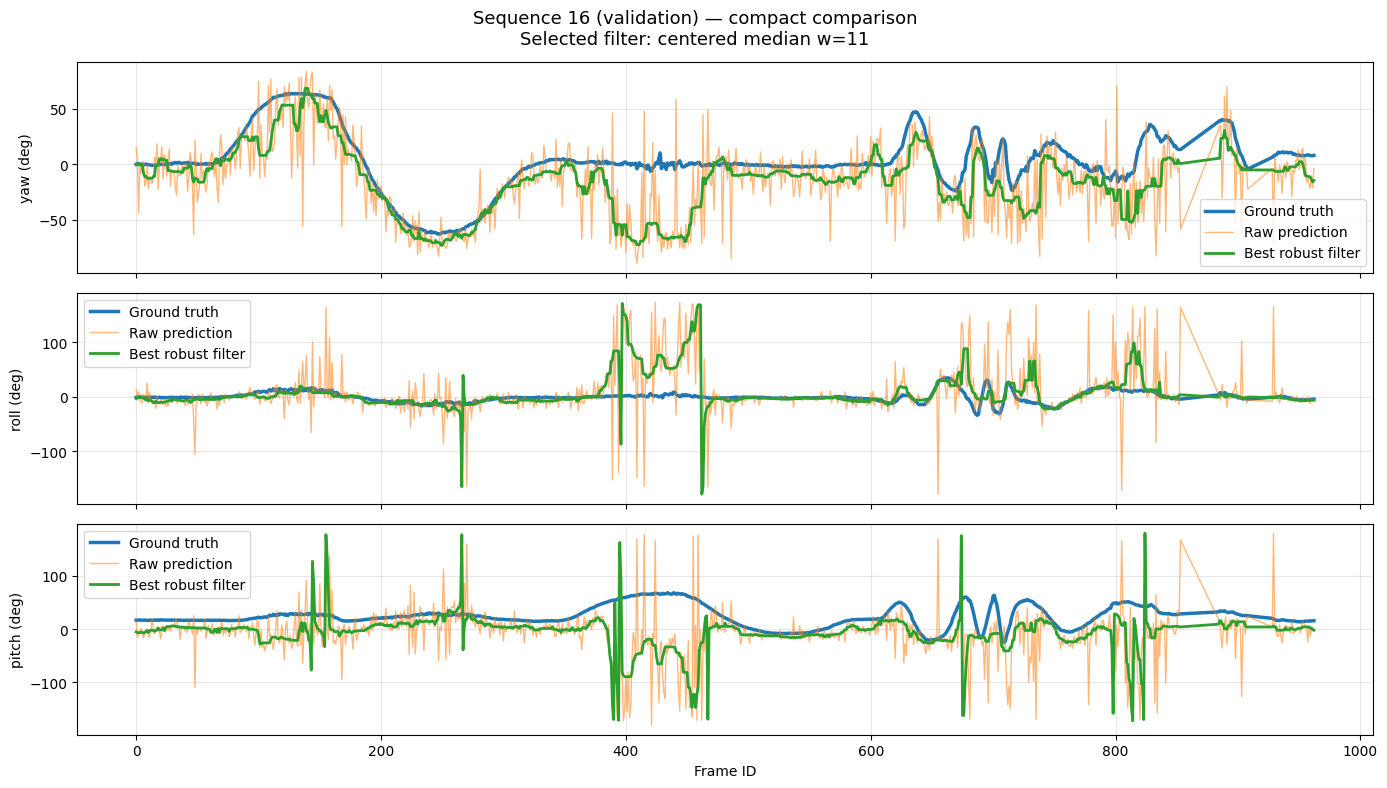

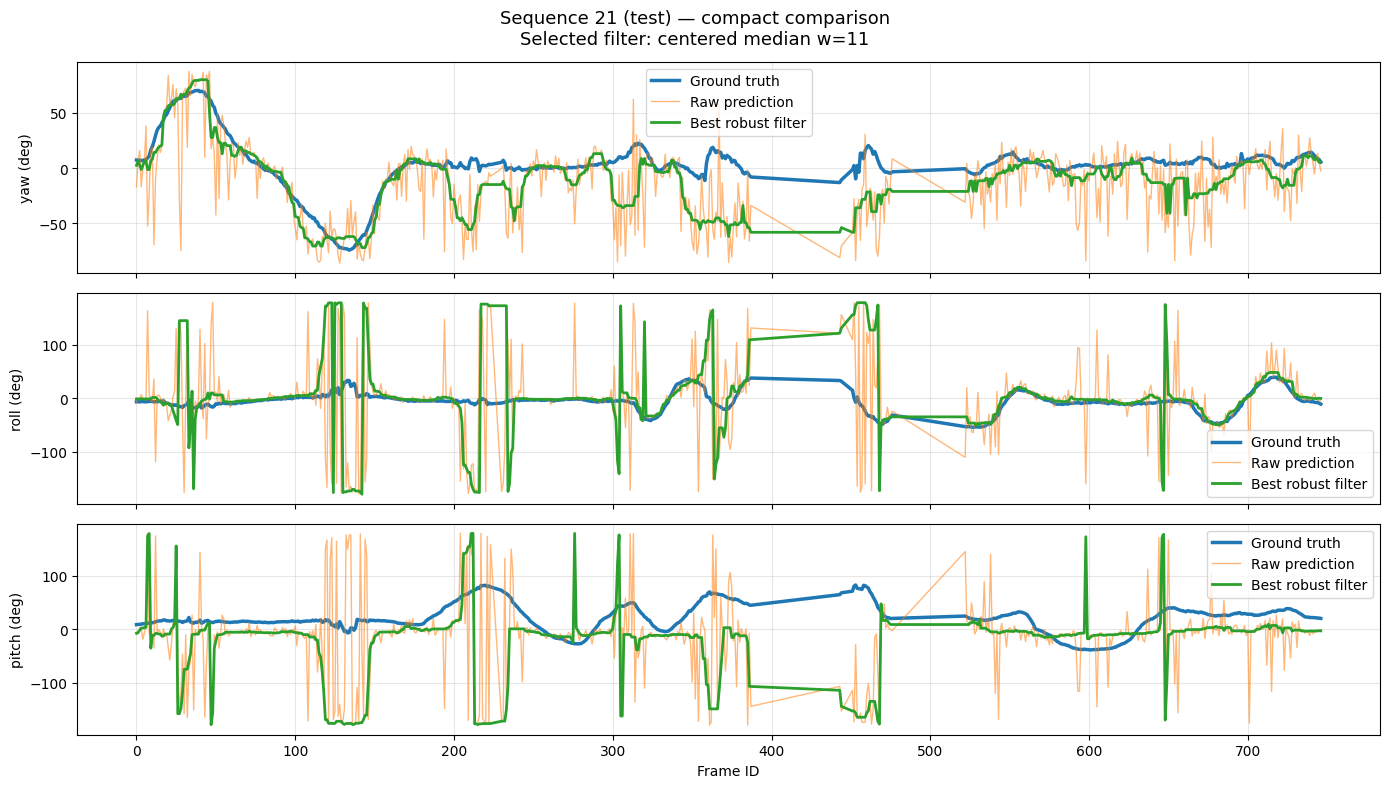

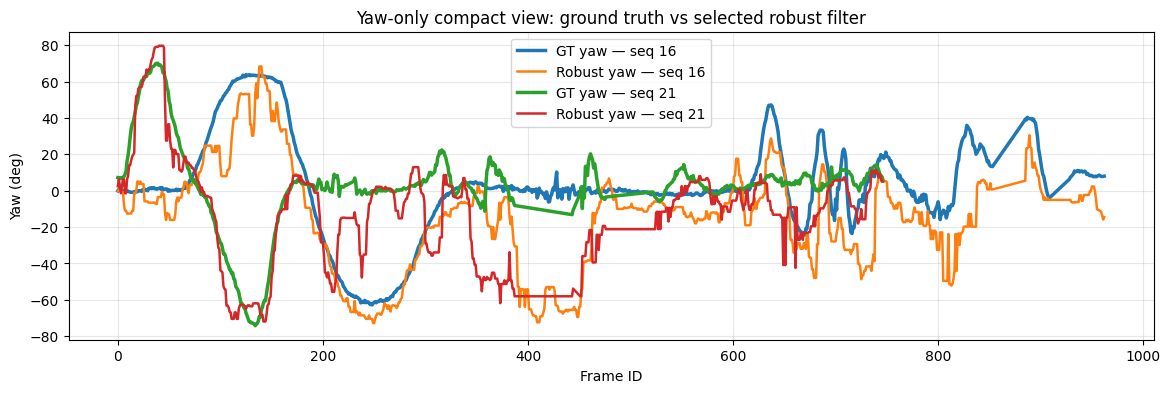

In [ ]:
# Section 15.2: Compact visual inspection of the selected robust filter

# Select the best candidate from validation balanced score if it is not already defined
if "best_robust_candidate_name" not in globals():
    best_robust_candidate_name = validation_search.iloc[0]["candidate"]

print("Selected robust candidate:")
print(best_robust_candidate_name)

# Build a compact table with the most relevant candidates
best_balanced_name = (
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("balanced_score")
    .iloc[0]["candidate"]
)

best_mae_name = (
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("mean_mae")
    .iloc[0]["candidate"]
)

best_temporal_name = (
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("mean_temporal_motion_error")
    .iloc[0]["candidate"]
)

compact_candidate_summary = robust_search_results[
    robust_search_results["candidate"].isin([
        "raw predictions",
        f"original EMA alpha={best_alpha}",
        best_balanced_name,
        best_mae_name,
        best_temporal_name,
    ])
].copy()

compact_candidate_summary = (
    compact_candidate_summary
    .sort_values(["split", "balanced_score", "mean_mae"])
    .reset_index(drop=True)
)

print("\nCompact comparison of relevant candidates:")
display(compact_candidate_summary)

# Build dataframe with selected robust-filter predictions
selected_candidate_df = robust_base_df.copy().sort_values(
    ["sequence_id", "frame_id"]
).reset_index(drop=True)

if best_robust_candidate_name == "raw predictions":
    for angle in ["yaw", "roll", "pitch"]:
        selected_candidate_df[f"bestrobust_pred_{angle}"] = selected_candidate_df[f"pred_{angle}"]

elif best_robust_candidate_name == f"original EMA alpha={best_alpha}":
    for angle in ["yaw", "roll", "pitch"]:
        selected_candidate_df[f"bestrobust_pred_{angle}"] = selected_candidate_df[f"smooth_pred_{angle}"]

else:
    selected_config = None
    
    for config in candidate_configs:
        if config["name"] == best_robust_candidate_name:
            selected_config = config
            break
    
    if selected_config is None:
        raise ValueError(f"Could not find config for candidate: {best_robust_candidate_name}")
    
    robust_tmp = apply_temporal_filter_by_sequence(
        selected_candidate_df,
        method=selected_config["method"],
        params=selected_config["params"],
        output_prefix="bestrobust_pred"
    )
    
    for angle in ["yaw", "roll", "pitch"]:
        selected_candidate_df[f"bestrobust_pred_{angle}"] = robust_tmp[f"bestrobust_pred_{angle}"].values

# Add errors and temporal metrics for the selected robust candidate
selected_candidate_df = add_frame_errors_for_prefix(
    selected_candidate_df,
    pred_prefix="bestrobust_pred",
    error_prefix="bestrobust_err"
)

selected_candidate_temporal_df = compute_temporal_metrics_for_prefix(
    selected_candidate_df,
    pred_prefix="bestrobust_pred"
)

selected_filter_summary = pd.DataFrame([
    summarize_candidate(
        selected_candidate_df,
        selected_candidate_temporal_df,
        pred_prefix="bestrobust_pred",
        error_prefix="bestrobust_err",
        candidate_name=best_robust_candidate_name,
        split_name="validation"
    ),
    summarize_candidate(
        selected_candidate_df,
        selected_candidate_temporal_df,
        pred_prefix="bestrobust_pred",
        error_prefix="bestrobust_err",
        candidate_name=best_robust_candidate_name,
        split_name="test"
    ),
])

print("\nSelected robust filter summary:")
display(selected_filter_summary)

# Compact temporal visualization:
# Only GT, raw prediction and best robust filter are plotted.
# This avoids overcrowding the figures with too many colored lines.

sequence_ids_to_plot = [16, 21]  # validation sequence 16 and test sequence 21

for sequence_id in sequence_ids_to_plot:
    seq_df = selected_candidate_df[
        selected_candidate_df["sequence_id"] == sequence_id
    ].copy().sort_values("frame_id")
    
    if len(seq_df) == 0:
        print(f"No frames found for sequence {sequence_id}")
        continue
    
    split_name = seq_df["split"].iloc[0]
    frame_ids = seq_df["frame_id"].values
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    
    for ax, angle in zip(axes, ["yaw", "roll", "pitch"]):
        ax.plot(
            frame_ids,
            seq_df[angle].values,
            label="Ground truth",
            linewidth=2.5
        )
        ax.plot(
            frame_ids,
            seq_df[f"pred_{angle}"].values,
            label="Raw prediction",
            alpha=0.55,
            linewidth=1.0
        )
        ax.plot(
            frame_ids,
            seq_df[f"bestrobust_pred_{angle}"].values,
            label="Best robust filter",
            linewidth=2.0
        )
        
        ax.set_ylabel(f"{angle} (deg)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
    
    axes[-1].set_xlabel("Frame ID")
    
    fig.suptitle(
        f"Sequence {sequence_id} ({split_name}) — compact comparison\n"
        f"Selected filter: {best_robust_candidate_name}",
        fontsize=13
    )
    
    plt.tight_layout()
    plt.show()

# Compact yaw-only plot, because yaw is where the model adds most value
plt.figure(figsize=(14, 4))

for sequence_id in sequence_ids_to_plot:
    seq_df = selected_candidate_df[
        selected_candidate_df["sequence_id"] == sequence_id
    ].copy().sort_values("frame_id")
    
    if len(seq_df) == 0:
        continue
    
    plt.plot(
        seq_df["frame_id"],
        seq_df["yaw"],
        label=f"GT yaw — seq {sequence_id}",
        linewidth=2.5
    )
    plt.plot(
        seq_df["frame_id"],
        seq_df["bestrobust_pred_yaw"],
        label=f"Robust yaw — seq {sequence_id}",
        linewidth=1.8
    )

plt.xlabel("Frame ID")
plt.ylabel("Yaw (deg)")
plt.title("Yaw-only compact view: ground truth vs selected robust filter")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


#### 15.2.1 Interpretation of the selected robust filter

The selected robust filter is a centered median filter with window size 11. Quantitatively, it improves over both the raw predictions and the original EMA on the test split: the mean MAE decreases to approximately 16.63 degrees, and the temporal motion error decreases to approximately 7.51 degrees.

However, the visual inspection shows that this improvement should be interpreted carefully. The filter strongly suppresses isolated raw prediction spikes, but it can also produce piecewise-constant trajectories and does not fully recover the true pose dynamics, especially for roll and pitch. In some regions, the robust filtered output remains far from the ground truth even though the raw outliers are reduced.

The yaw-only plot is more informative: yaw is the axis where the model retains the most useful pose signal, and the robust filter often follows the broad yaw trend better than it does for roll or pitch. This agrees with the previous baseline analysis, where the pretrained model added most value on yaw while roll and pitch were more affected by fisheye-induced outliers.

Overall, robust temporal filtering is a better post-processing strategy than simple EMA, but it still treats the symptoms of the problem rather than the cause. The remaining failures suggest that the main limitation is not just temporal instability, but the lack of fisheye-aware domain adaptation.

### 15.3 Axis-specific robust filtering

The previous robust filtering search applied the same temporal filter to yaw, roll and pitch. However, Section 14 showed that the model behaves differently across axes. The raw model preserves useful information for yaw, while roll and pitch are more affected by fisheye-induced outliers and by the centered distribution of the dataset.

We therefore perform an axis-specific post-processing search. The goal is to preserve useful yaw dynamics while stabilizing roll and pitch more aggressively.

This experiment should be interpreted as a diagnostic rather than as a final deployable method. Some candidates are allowed to replace an axis with the validation-set circular mean. This can improve MAE and temporal stability when an axis is poorly predicted, but it also removes frame-level pose dynamics from that axis.

All candidate filters are selected using the validation split only. The test split is used only for final evaluation.

Validation circular means used for shrinkage/constant filters:
{'yaw': np.float64(8.901577350299588), 'roll': np.float64(-0.13126947192336208), 'pitch': np.float64(13.093011262652142)}
Number of axis-specific candidates: 144

Top axis-specific candidates by validation balanced score:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,17.991085,12.974950,1.883512,2.921863,0.618733
1,yaw=centered_median_w7 | roll=validation_mean ...,validation,3049,3043,11.954908,9.329161,17.991085,13.091718,2.618361,3.613894,0.638717
2,yaw=centered_median_w11 | roll=centered_median...,validation,3049,3043,11.604605,9.430763,17.991085,13.008818,3.920916,4.679669,0.658247
3,yaw=centered_median_w5 | roll=validation_mean ...,validation,3049,3043,12.232676,9.329161,17.991085,13.184307,3.668526,4.604917,0.664141
4,yaw=centered_median_w7 | roll=centered_median_...,validation,3049,3043,11.954908,9.430763,17.991085,13.125585,4.608633,5.343012,0.677610
5,yaw=centered_median_w5 | roll=centered_median_...,validation,3049,3043,12.232676,9.430763,17.991085,13.218175,5.569157,6.267036,0.701584
6,yaw=centered_median_w11 | roll=centered_median...,validation,3049,3043,11.604605,12.307999,17.991085,13.967896,4.656755,5.344179,0.713695
7,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,19.648282,13.527349,5.834465,6.567008,0.721315
8,yaw=centered_median_w7 | roll=centered_median_...,validation,3049,3043,11.954908,12.307999,17.991085,14.084664,5.329046,5.994220,0.732770
9,yaw=centered_median_w7 | roll=validation_mean ...,validation,3049,3043,11.954908,9.329161,19.648282,13.644117,6.468418,7.178007,0.739545



Top axis-specific candidates by validation mean MAE:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,17.991085,12.974950,1.883512,2.921863,0.618733
1,yaw=centered_median_w11 | roll=centered_median...,validation,3049,3043,11.604605,9.430763,17.991085,13.008818,3.920916,4.679669,0.658247
2,yaw=centered_median_w7 | roll=validation_mean ...,validation,3049,3043,11.954908,9.329161,17.991085,13.091718,2.618361,3.613894,0.638717
3,yaw=centered_median_w7 | roll=centered_median_...,validation,3049,3043,11.954908,9.430763,17.991085,13.125585,4.608633,5.343012,0.677610
4,yaw=centered_median_w5 | roll=validation_mean ...,validation,3049,3043,12.232676,9.329161,17.991085,13.184307,3.668526,4.604917,0.664141
5,yaw=centered_median_w5 | roll=centered_median_...,validation,3049,3043,12.232676,9.430763,17.991085,13.218175,5.569157,6.267036,0.701584
6,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,19.648282,13.527349,5.834465,6.567008,0.721315
7,yaw=centered_median_w11 | roll=centered_median...,validation,3049,3043,11.604605,9.430763,19.648282,13.561217,7.264824,7.826149,0.750031
8,yaw=centered_median_w7 | roll=validation_mean ...,validation,3049,3043,11.954908,9.329161,19.648282,13.644117,6.468418,7.178007,0.739545
9,yaw=centered_median_w7 | roll=centered_median_...,validation,3049,3043,11.954908,9.430763,19.648282,13.677984,7.876828,8.426909,0.768039



Best axis-specific candidate selected on validation:
yaw=centered_median_w11 | roll=validation_mean | pitch=validation_mean

Appendix C comparison: raw vs EMA vs global robust vs axis-specific robust


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,yaw=centered_median_w11 | roll=validation_mean...,test,12629,12585,11.848100,9.091692,19.986305,13.642032,1.950993,2.955157,0.648011
1,centered median w=11,test,12629,12585,11.848100,14.243855,23.793740,16.628565,7.141341,7.506834,0.874430
2,original EMA alpha=0.2,test,12629,12585,13.414557,18.930861,27.463568,19.936329,9.201122,9.251010,1.053806
3,raw predictions,test,12629,12585,16.992973,21.132519,29.663300,22.596264,44.273643,44.272610,1.926058
4,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,17.991085,12.974950,1.883512,2.921863,0.618733
5,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
6,original EMA alpha=0.2,validation,3049,3043,12.839133,21.014418,33.070133,22.307894,11.090576,11.167648,1.196837
7,raw predictions,validation,3049,3043,16.389506,21.885331,31.801848,23.358895,46.223222,46.179548,2.000000



Selected axis-specific robust filter summary:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error
0,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,17.991085,12.974950,1.883512,2.921863
1,yaw=centered_median_w11 | roll=validation_mean...,test,12629,12585,11.848100,9.091692,19.986305,13.642032,1.950993,2.955157


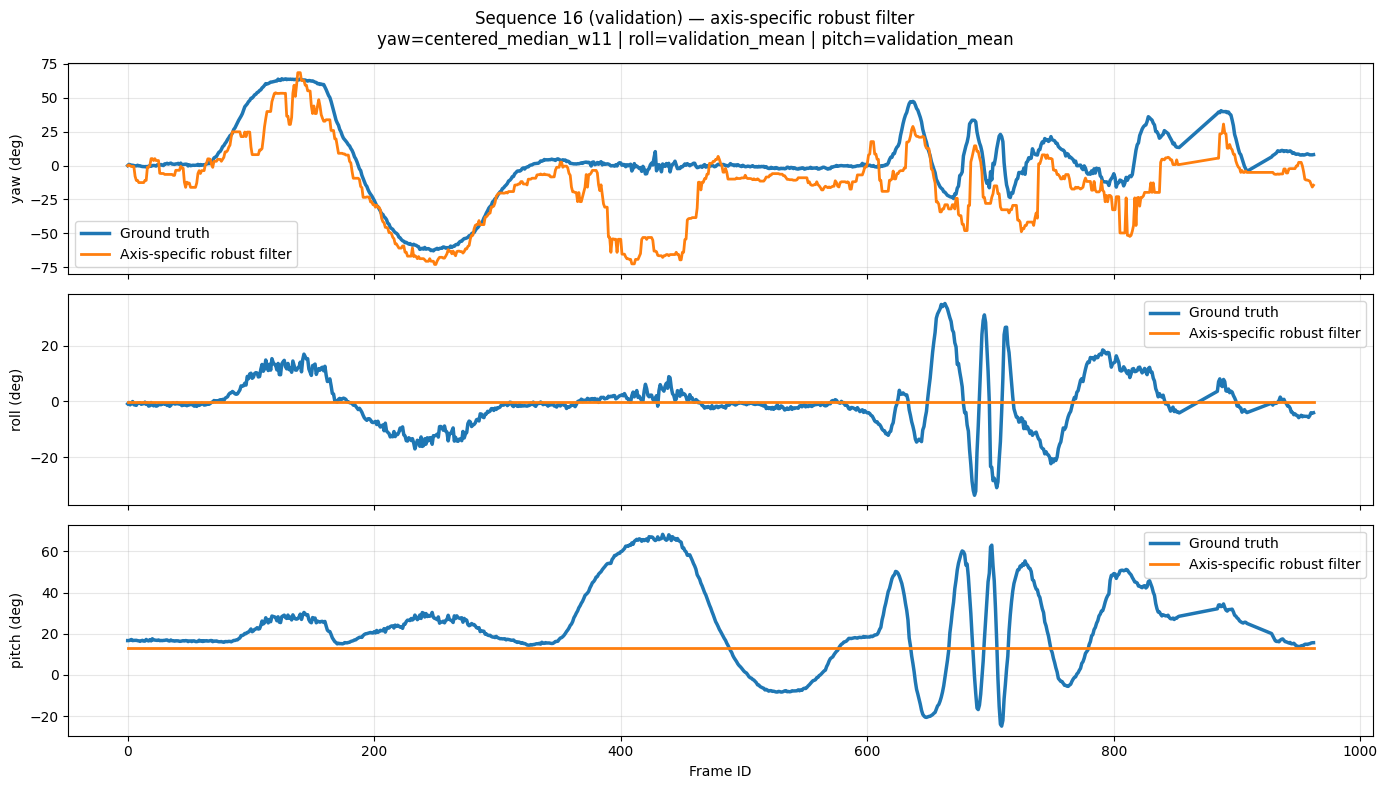

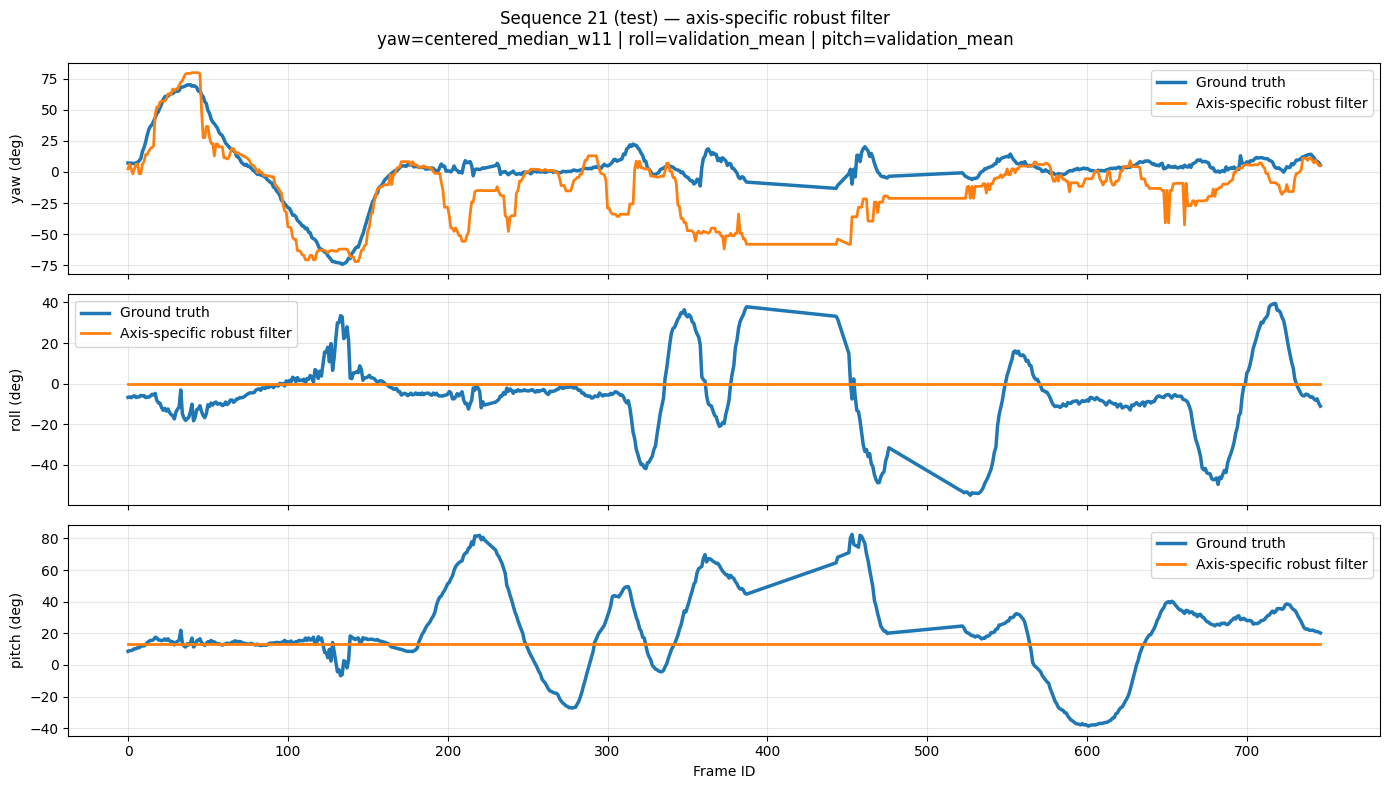

In [ ]:
# Section 15.3: Axis-specific robust filtering search

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

axis_base_df = final_smoothed_df.copy()

validation_df_for_axis = axis_base_df[axis_base_df["split"] == "validation"].copy()

validation_means = {
    "yaw": circular_mean_deg(validation_df_for_axis["yaw"]),
    "roll": circular_mean_deg(validation_df_for_axis["roll"]),
    "pitch": circular_mean_deg(validation_df_for_axis["pitch"]),
}

print("Validation circular means used for shrinkage/constant filters:")
print(validation_means)

# -------------------------------------------------------------------
# Candidate space
# -------------------------------------------------------------------

# Yaw gets less aggressive options because Appendix B showed
# that the model adds useful yaw information.
yaw_filter_options = [
    "raw",
    "centered_median_w5",
    "centered_median_w7",
    "centered_median_w11",
]

# Roll and pitch get more aggressive options because they are more unstable.
roll_filter_options = [
    "centered_median_w7",
    "centered_median_w11",
    "centered_median_w11_ema05",
    "centered_median_w11_shrink025",
    "centered_median_w11_shrink050",
    "validation_mean",
]

pitch_filter_options = [
    "centered_median_w7",
    "centered_median_w11",
    "centered_median_w11_ema05",
    "centered_median_w11_shrink025",
    "centered_median_w11_shrink050",
    "validation_mean",
]

axis_candidate_configs = []

for yaw_filter, roll_filter, pitch_filter in itertools.product(
    yaw_filter_options,
    roll_filter_options,
    pitch_filter_options
):
    axis_candidate_configs.append({
        "yaw": yaw_filter,
        "roll": roll_filter,
        "pitch": pitch_filter,
    })

print("Number of axis-specific candidates:", len(axis_candidate_configs))

# -------------------------------------------------------------------
# Search
# -------------------------------------------------------------------

axis_search_rows = []

for axis_config in axis_candidate_configs:
    candidate_name = axis_config_name(axis_config)

    candidate_df = apply_axis_specific_filter(
        axis_base_df,
        axis_config=axis_config,
        output_prefix="axisrobust_pred",
        validation_means=validation_means
    )

    candidate_df = add_frame_errors_for_prefix(
        candidate_df,
        pred_prefix="axisrobust_pred",
        error_prefix="axisrobust_err"
    )

    candidate_temporal_df = compute_temporal_metrics_for_prefix(
        candidate_df,
        pred_prefix="axisrobust_pred"
    )

    for split_name in ["validation", "test"]:
        axis_search_rows.append(
            summarize_candidate(
                candidate_df,
                candidate_temporal_df,
                pred_prefix="axisrobust_pred",
                error_prefix="axisrobust_err",
                candidate_name=candidate_name,
                split_name=split_name
            )
        )

axis_search_results = pd.DataFrame(axis_search_rows)

# Normalization against raw validation values
raw_validation_row = robust_search_results[
    (robust_search_results["split"] == "validation") &
    (robust_search_results["candidate"] == "raw predictions")
].iloc[0]

raw_val_mae = raw_validation_row["mean_mae"]
raw_val_temporal_error = raw_validation_row["mean_temporal_motion_error"]

axis_search_results["balanced_score"] = (
    axis_search_results["mean_mae"] / raw_val_mae +
    axis_search_results["mean_temporal_motion_error"] / raw_val_temporal_error
)

axis_validation_search = (
    axis_search_results[axis_search_results["split"] == "validation"]
    .sort_values("balanced_score")
    .reset_index(drop=True)
)

best_axis_candidate_name = axis_validation_search.iloc[0]["candidate"]

print("\nTop axis-specific candidates by validation balanced score:")
display(axis_validation_search.head(15))

print("\nTop axis-specific candidates by validation mean MAE:")
display(
    axis_search_results[axis_search_results["split"] == "validation"]
    .sort_values("mean_mae")
    .head(15)
    .reset_index(drop=True)
)

print("\nBest axis-specific candidate selected on validation:")
print(best_axis_candidate_name)

# -------------------------------------------------------------------
# Compare selected axis-specific filter with previous methods
# -------------------------------------------------------------------

comparison_names = [
    "raw predictions",
    f"original EMA alpha={best_alpha}",
    best_robust_candidate_name,
    best_axis_candidate_name,
]

previous_comparison = robust_search_results[
    robust_search_results["candidate"].isin([
        "raw predictions",
        f"original EMA alpha={best_alpha}",
        best_robust_candidate_name,
    ])
].copy()

axis_selected_comparison = axis_search_results[
    axis_search_results["candidate"] == best_axis_candidate_name
].copy()

final_c_comparison = pd.concat(
    [previous_comparison, axis_selected_comparison],
    ignore_index=True
).sort_values(["split", "mean_mae"]).reset_index(drop=True)

print("\nSection 15 comparison: raw vs EMA vs global robust vs axis-specific robust")
display(final_c_comparison)

# -------------------------------------------------------------------
# Build prediction table for selected axis-specific candidate
# -------------------------------------------------------------------

selected_axis_config = None

for config in axis_candidate_configs:
    if axis_config_name(config) == best_axis_candidate_name:
        selected_axis_config = config
        break

if selected_axis_config is None:
    raise ValueError("Selected axis-specific config was not found.")

axis_selected_df = apply_axis_specific_filter(
    axis_base_df,
    axis_config=selected_axis_config,
    output_prefix="axisbest_pred",
    validation_means=validation_means
)

axis_selected_df = add_frame_errors_for_prefix(
    axis_selected_df,
    pred_prefix="axisbest_pred",
    error_prefix="axisbest_err"
)

axis_selected_temporal_df = compute_temporal_metrics_for_prefix(
    axis_selected_df,
    pred_prefix="axisbest_pred"
)

axis_selected_summary = pd.DataFrame([
    summarize_candidate(
        axis_selected_df,
        axis_selected_temporal_df,
        pred_prefix="axisbest_pred",
        error_prefix="axisbest_err",
        candidate_name=best_axis_candidate_name,
        split_name="validation"
    ),
    summarize_candidate(
        axis_selected_df,
        axis_selected_temporal_df,
        pred_prefix="axisbest_pred",
        error_prefix="axisbest_err",
        candidate_name=best_axis_candidate_name,
        split_name="test"
    ),
])

print("\nSelected axis-specific robust filter summary:")
display(axis_selected_summary)

# -------------------------------------------------------------------
# Compact visualization
# Only GT and selected axis-specific robust filter are plotted.
# This avoids overcrowded figures.
# -------------------------------------------------------------------

sequence_ids_to_plot = [16, 21]

for sequence_id in sequence_ids_to_plot:
    seq_df = axis_selected_df[
        axis_selected_df["sequence_id"] == sequence_id
    ].copy().sort_values("frame_id")

    if len(seq_df) == 0:
        print(f"No frames found for sequence {sequence_id}")
        continue

    split_name = seq_df["split"].iloc[0]
    frame_ids = seq_df["frame_id"].values

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    for ax, angle in zip(axes, ["yaw", "roll", "pitch"]):
        ax.plot(
            frame_ids,
            seq_df[angle],
            label="Ground truth",
            linewidth=2.5
        )
        ax.plot(
            frame_ids,
            seq_df[f"axisbest_pred_{angle}"],
            label="Axis-specific robust filter",
            linewidth=2.0
        )

        ax.set_ylabel(f"{angle} (deg)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    axes[-1].set_xlabel("Frame ID")

    fig.suptitle(
        f"Sequence {sequence_id} ({split_name}) — axis-specific robust filter\n"
        f"{best_axis_candidate_name}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()


#### 15.3.1 Interpretation of the axis-specific filter

The selected axis-specific candidate uses a centered median filter with window size 11 for yaw, but replaces roll and pitch with their validation-set circular means. This produces the best validation balanced score and also improves the test metrics: the test mean MAE decreases to approximately 13.64 degrees, while the mean temporal motion error decreases to approximately 2.96 degrees.

However, this result must be interpreted carefully. The improvement in roll and pitch does not come from better frame-by-frame pose estimation, but from suppressing those axes almost completely. The visual inspection confirms this: roll and pitch become nearly flat trajectories. This works numerically because roll and pitch are relatively centered in BIWI-360 and because the zero-shot model produces many large outliers on those axes.

Yaw behaves differently. The selected method keeps a filtered version of the model's yaw prediction, which confirms the previous finding that 6DRepNet360 still extracts useful horizontal head-pose information under fisheye distortion.

Therefore, the axis-specific filter is useful as a diagnostic: it shows that most of the model's transferable signal is concentrated in yaw, while roll and pitch are not reliable in the zero-shot setting. But it is not a satisfactory general solution, because it sacrifices real roll and pitch dynamics. This further supports the conclusion that the core problem is not only temporal instability, but a fisheye domain shift that requires domain adaptation or a fisheye-aware model.

## 15.4 Robust temporal filtering conclusion

The robust temporal filtering pilot shows that post-processing can substantially improve the BIWI-360 results, but only when it is designed according to the failure analysis.

The best global robust filter selected on the validation split was a centered temporal median with window size 11. This filter improved the test mean MAE from 22.60 degrees for raw predictions to 16.63 degrees, while also reducing the mean temporal motion error from 44.27 to 7.51 degrees per frame. This confirms that many of the raw prediction failures are temporally inconsistent outliers that can be reduced with robust filtering.

However, the best overall result was obtained by an axis-specific hybrid filter. This filter uses a centered median filter for yaw, while replacing roll and pitch with their validation-set circular means. On the test split, this reduced the mean MAE to 13.64 degrees and the temporal motion error to 2.96 degrees per frame.

This result should be interpreted carefully. The axis-specific filter is not a pure temporal smoothing method for all angles. Instead, it exploits the observation from Section 14 that the model is useful mainly for yaw, while roll and pitch are dominated by fisheye-induced outliers and are better approximated by stable constants. Since the constants are estimated only from the validation split, this is not test leakage, but it is still a dataset-specific post-processing strategy.

The result supports a nuanced conclusion. Zero-shot 6DRepNet360 is not reliable as a direct frame-by-frame estimator on BIWI-360, especially for roll and pitch. Nevertheless, its yaw predictions contain useful pose information. A robust axis-specific post-processing strategy can preserve this useful yaw signal while suppressing unstable roll and pitch predictions.

Overall, this section confirms that simple EMA is not the best temporal strategy for this setting. More robust post-processing, especially median filtering and axis-specific treatment, gives a much better accuracy-stability trade-off. However, the best axis-specific result is partly achieved by suppressing roll and pitch dynamics rather than truly recovering them. Therefore, post-processing improves the symptoms of the problem but does not fully solve the underlying fisheye domain shift.

The next section follows the domain-adaptation direction suggested by these results. It evaluates whether a fisheye-aware fine-tuning strategy can reduce the error more fundamentally than temporal post-processing alone.

# 16. Location-guided fine-tuning (`rho`/`theta` + fine-tune)

The failure analysis in Section 14 showed that the zero-shot error is a genuine geometric domain shift that grows with the radial fisheye position `rho`, and Section 5.1 showed that the distortion is sampled independently per frame. Therefore, temporal post-processing can reduce prediction jitter, but it cannot fully solve the underlying per-frame distortion problem.

The natural next step is to adapt the model to fisheye images and let it condition explicitly on the distortion location.

**Architecture.** We keep the pretrained 6DRepNet360 backbone and its 6D rotation head, and add a small residual head conditioned on the fisheye location `(rho, theta)`, encoded as `[rho, sin(theta), cos(theta)]`. The residual is zero-initialized, so training starts exactly from the pretrained model and learns a location-conditioned correction. This follows the location-guided idea proposed for HPE-360. The model is trained with the native geodesic loss on SO(3).

**Why this is deployable.** `rho` and `theta` are the polar coordinates used to synthesize the HPE-360 fisheye distortion. In a real fisheye image, the equivalent information can be obtained from the detected face location and the known lens distortion model. Therefore, conditioning on location is a realistic and deployable design, not test-time leakage.

**Protocol.** We fine-tune on 300W-LP-360, the large fisheye split with many identities, and evaluate on the same BIWI-360 test sequences used throughout the notebook. This makes the result directly comparable with the zero-shot, EMA and robust-filtering experiments. We deliberately do not fine-tune on BIWI-360 itself, because it contains only 20 subjects and would carry a high risk of overfitting.

Before running the full experiment, the pipeline can be checked with `SMOKE_TEST = True`, which uses a tiny subset and one epoch. The real run uses `SMOKE_TEST = False`.

In [ ]:
# 16.1 Configuration
import os
import numpy as np
import pandas as pd

WLP360_ROOT  = HPE360_ROOT / "300W-LP-360"
WLP360_LABEL = WLP360_ROOT / "label_300wlp.txt"

RUN_SECTION_16 = WLP360_LABEL.exists()

# Backward-compatible alias in case later cells still refer to the old name.
RUN_APPENDIX_D = RUN_SECTION_16

# Kept modest so a real run fits a single Kaggle GPU session.
SMOKE_TEST      = False     # True: tiny subset + 1 epoch to verify the pipeline runs.
TRAIN_SUBSET    = 30000    # Number of 300W-LP-360 images to train on (None = all ~122k).
VAL_FRACTION    = 0.05
EPOCHS          = 3
BATCH_SIZE      = 64
FREEZE_BACKBONE = False    # False: full location-guided fine-tune; True: train only the location head.
USE_LOCATION    = True     # False: ablation -- feed zeros instead of (rho, theta) to isolate location guidance.
LR_HEAD         = 1e-3
LR_BACKBONE     = 1e-5
SEED            = 42

if SMOKE_TEST:
    TRAIN_SUBSET, EPOCHS = 512, 1

print("Section 16 will run:", RUN_SECTION_16, "| smoke test:", SMOKE_TEST)

if not RUN_SECTION_16:
    print("300W-LP-360 not found at", WLP360_LABEL)
    print("Section 16 will be skipped; the rest of the notebook is unaffected.")

Appendix D will run: True | smoke test: False


## 16.2 Model components: geodesic loss and location-guided wrapper

This section defines the two core components needed for the fisheye adaptation experiment.

First, we define a geodesic loss on SO(3), which measures the angular distance between the predicted and ground-truth rotation matrices. This is more appropriate than directly optimizing Euler angles because it avoids discontinuities and respects the geometry of 3D rotations.

Second, we wrap the pretrained 6DRepNet360 model with a small residual head conditioned on the fisheye location metadata. The location is represented as `[rho, sin(theta), cos(theta)]`, so the angular coordinate is encoded continuously. The residual head is zero-initialized, meaning that before fine-tuning the model behaves exactly like the pretrained baseline. During training, it learns only the correction needed to adapt the prediction to fisheye distortion.

In [ ]:
# 16.2 Model components: geodesic loss + location-guided wrapper
import copy
import torch
import torch.nn as nn

class GeodesicLoss(nn.Module):
    """Mean geodesic distance on SO(3), measured in radians."""
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, R_pred, R_gt):
        R_rel = torch.bmm(R_pred.transpose(1, 2), R_gt)
        cos_theta = (
            R_rel[:, 0, 0] +
            R_rel[:, 1, 1] +
            R_rel[:, 2, 2] -
            1.0
        ) / 2.0

        return torch.acos(
            torch.clamp(cos_theta, -1.0 + self.eps, 1.0 - self.eps)
        ).mean()


class LocationGuidedHeadPose(nn.Module):
    """
    Pretrained 6DRepNet360 plus a residual 6D head conditioned on fisheye
    location metadata.

    The location input is encoded as [rho, sin(theta), cos(theta)].
    The residual head is zero-initialized, so the model starts exactly from
    the pretrained baseline and then learns a location-conditioned correction.

    base_model is a SixDRepNet360 instance.
    ortho6d_fn maps a 6D vector to a rotation matrix, using the repository's
    own ortho6D-to-SO(3) conversion function.
    """
    def __init__(
        self,
        base_model,
        ortho6d_fn,
        loc_in=3,
        loc_embed=64,
        feat_dim=2048,
        hidden=256
    ):
        super().__init__()

        self.base = base_model
        self.ortho6d_fn = ortho6d_fn

        self.loc_mlp = nn.Sequential(
            nn.Linear(loc_in, loc_embed),
            nn.ReLU()
        )

        self.residual = nn.Sequential(
            nn.Linear(feat_dim + loc_embed, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 6)
        )

        # Start exactly from the pretrained model.
        nn.init.zeros_(self.residual[-1].weight)
        nn.init.zeros_(self.residual[-1].bias)

    def backbone_features(self, x):
        b = self.base

        x = b.conv1(x)
        x = b.bn1(x)
        x = b.relu(x)
        x = b.maxpool(x)

        x = b.layer1(x)
        x = b.layer2(x)
        x = b.layer3(x)
        x = b.layer4(x)

        x = b.avgpool(x)
        return x.view(x.size(0), -1)

    def forward(self, image, loc):
        feat = self.backbone_features(image)

        base_6d = self.base.linear_reg(feat)
        loc_feat = self.loc_mlp(loc)

        delta_6d = self.residual(torch.cat([feat, loc_feat], dim=1))

        return self.ortho6d_fn(base_6d + delta_6d)


print("Location-guided model components defined.")

Location-guided model components defined.


The wrapper keeps the pretrained model as the starting point and adds only a learnable correction. This makes the experiment conservative: any improvement should come from adapting the pretrained representation to fisheye geometry, rather than from replacing the original model with a completely new architecture.

## 16.3 Dataset classes for fine-tuning and evaluation

This section defines the dataset wrappers used in the location-guided fine-tuning experiment.

The first dataset, `WLP360Dataset`, is used for training on 300W-LP-360. For each image, it returns the transformed RGB input, the location features `[rho, sin(theta), cos(theta)]`, and the ground-truth rotation matrix built from the yaw, roll and pitch labels.

The second dataset, `LocationEvalDataset`, is used for inference on frame-level datasets such as BIWI-360. It returns the image, the same location encoding, and the row index so that predictions can later be written back into the original dataframe.

Using the same location encoding in training and evaluation ensures that the model learns a correction that is directly conditioned on the fisheye distortion metadata.

In [ ]:
# 16.3 Dataset classes for 300W-LP-360 training and BIWI-360 evaluation
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class WLP360Dataset(Dataset):
    """
    Dataset for training on 300W-LP-360.

    Each sample returns:
    - transformed RGB image;
    - location features [rho, sin(theta), cos(theta)];
    - ground-truth rotation matrix.
    """
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, i):
        path, yaw, roll, pitch, rho, theta = self.records[i]

        image = Image.open(path).convert("RGB")
        image = self.transform(image)

        loc = torch.tensor(
            location_features_deg(rho, theta),
            dtype=torch.float32
        )

        R_gt = torch.from_numpy(
            rotation_matrices_from_euler_deg(yaw, roll, pitch)
        ).float()

        return image, loc, R_gt


class LocationEvalDataset(Dataset):
    """
    Generic image + location dataset for inference over a frame dataframe,
    for example BIWI-360.
    """
    def __init__(self, frame_df, transform):
        self.df = frame_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]

        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)

        loc = torch.tensor(
            location_features_deg(row["rho"], row["theta"]),
            dtype=torch.float32
        )

        return image, loc, i


print("Dataset classes defined.")

Dataset classes defined.


## 16.4 Fine-tuning the location-guided model on 300W-LP-360

We now fine-tune the location-guided model on 300W-LP-360.

The label file contains the image path together with yaw, roll, pitch, `rho` and `theta`. Since some image paths may contain spaces, the parser reads the last five tokens as numeric labels and treats the remaining tokens as the image path. This makes the loading procedure robust to small differences in the label-file format.

The model is initialized from the pretrained 6DRepNet360 baseline. A deep copy is used so that the original zero-shot model remains unchanged for the previous experiments. If `FREEZE_BACKBONE = False`, both the backbone and the new location-conditioned residual head are updated, using a smaller learning rate for the pretrained backbone. If `FREEZE_BACKBONE = True`, only the new residual head is trained.

The objective is the geodesic loss on SO(3), measured between the predicted and ground-truth rotation matrices.

In [ ]:
# 16.4 Fine-tune the location-guided model on 300W-LP-360

if RUN_SECTION_16:
    rng = np.random.default_rng(SEED)

    # The image path is the first field and may contain spaces.
    # We therefore parse the last 5 tokens as the numeric labels:
    # yaw, roll, pitch, rho, theta.
    # Everything before them is interpreted as the image path.
    raw = []
    skipped = 0

    with open(WLP360_LABEL) as f:
        for line in f:
            parts = line.split()

            if len(parts) < 6:
                continue

            try:
                yaw, roll, pitch, rho, theta = (float(x) for x in parts[-5:])
            except ValueError:
                skipped += 1
                continue

            raw.append((parts[:-5], yaw, roll, pitch, rho, theta))

    def _join_space(toks):
        return " ".join(toks)

    def _join_os(toks):
        return os.path.join(*toks)

    # Auto-detect whether the image path should be reconstructed with spaces
    # or with OS path separators.
    join_fn = _join_space

    if raw:
        probe = raw[0][0]

        if (
            not (WLP360_ROOT / _join_space(probe)).exists()
            and (WLP360_ROOT / _join_os(probe)).exists()
        ):
            join_fn = _join_os

    records = [
        (str(WLP360_ROOT / join_fn(toks)), yaw, roll, pitch, rho, theta)
        for (toks, yaw, roll, pitch, rho, theta) in raw
    ]

    print(
        f"Parsed {len(records)} labels ({skipped} malformed lines skipped). "
        f"Path strategy: {'space-joined' if join_fn is _join_space else 'os-path-joined'}."
    )

    if records:
        print("First image path:", records[0][0], "| exists:", os.path.exists(records[0][0]))

    # Shuffle and optionally subsample the training set.
    rng.shuffle(records)

    if TRAIN_SUBSET is not None:
        records = records[:TRAIN_SUBSET]

    n_val = max(1, int(len(records) * VAL_FRACTION))
    val_records = records[:n_val]
    train_records = records[n_val:]

    print(f"300W-LP-360 records: train={len(train_records)} val={len(val_records)}")

    train_loader = DataLoader(
        WLP360Dataset(train_records, inference_transform),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    val_loader = DataLoader(
        WLP360Dataset(val_records, inference_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    # Deep copy the base model so the original zero-shot model is preserved.
    lg_model = LocationGuidedHeadPose(
        copy.deepcopy(model),
        sixd_utils.compute_rotation_matrix_from_ortho6d
    ).to(device)

    if FREEZE_BACKBONE:
        for p in lg_model.base.parameters():
            p.requires_grad = False

        param_groups = [
            {
                "params": [
                    p for n, p in lg_model.named_parameters()
                    if not n.startswith("base.")
                ],
                "lr": LR_HEAD
            }
        ]

    else:
        head_params = [
            p for n, p in lg_model.named_parameters()
            if not n.startswith("base.")
        ]

        base_params = [
            p for n, p in lg_model.named_parameters()
            if n.startswith("base.")
        ]

        param_groups = [
            {"params": head_params, "lr": LR_HEAD},
            {"params": base_params, "lr": LR_BACKBONE}
        ]

    optimizer = torch.optim.Adam(param_groups)
    geo_loss = GeodesicLoss()

    n_trainable = sum(
        p.numel()
        for p in lg_model.parameters()
        if p.requires_grad
    )

    print(f"Trainable parameters: {n_trainable:,} (freeze_backbone={FREEZE_BACKBONE})")

    for epoch in range(EPOCHS):
        lg_model.train()

        # If the backbone is frozen, keep BatchNorm statistics fixed.
        if FREEZE_BACKBONE:
            lg_model.base.eval()

        train_loss_sum = 0.0
        train_batches = 0

        for img, loc, R_gt in train_loader:
            img = img.to(device, non_blocking=True)
            loc = loc.to(device, non_blocking=True)
            R_gt = R_gt.to(device, non_blocking=True)

            # Ablation: remove location information while keeping the same model.
            if not USE_LOCATION:
                loc = torch.zeros_like(loc)

            optimizer.zero_grad()

            R_pred = lg_model(img, loc)
            loss = geo_loss(R_pred, R_gt)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_batches += 1

            if SMOKE_TEST and train_batches >= 5:
                break

        lg_model.eval()

        val_loss_sum = 0.0
        val_batches = 0

        with torch.no_grad():
            for img, loc, R_gt in val_loader:
                img = img.to(device, non_blocking=True)
                loc = loc.to(device, non_blocking=True)
                R_gt = R_gt.to(device, non_blocking=True)

                if not USE_LOCATION:
                    loc = torch.zeros_like(loc)

                R_pred = lg_model(img, loc)
                val_loss = geo_loss(R_pred, R_gt)

                val_loss_sum += val_loss.item()
                val_batches += 1

                if SMOKE_TEST and val_batches >= 3:
                    break

        train_geo_deg = np.degrees(train_loss_sum / max(train_batches, 1))
        val_geo_deg = np.degrees(val_loss_sum / max(val_batches, 1))

        print(
            f"epoch {epoch + 1}/{EPOCHS}  "
            f"train_geo={train_geo_deg:.2f} deg  "
            f"val_geo={val_geo_deg:.2f} deg"
        )

else:
    print("Skipped because 300W-LP-360 is not available.")

Parsed 122415 labels (0 malformed lines skipped). Path strategy: space-joined.
First image path: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/300W-LP-360/AFW/AFW_1051618982_1_0.jpg | exists: True
300W-LP-360 records: train=28500 val=1500
Trainable parameters: 24,063,052 (freeze_backbone=False)
epoch 1/3  train_geo=11.58 deg  val_geo=7.46 deg
epoch 2/3  train_geo=6.59 deg  val_geo=6.05 deg
epoch 3/3  train_geo=5.34 deg  val_geo=5.18 deg


The training loss decreases from 11.58 degrees to 5.34 degrees, and the validation geodesic error decreases from 7.46 degrees to 5.18 degrees after three epochs. This indicates that the model is successfully adapting to 300W-LP-360 without an obvious validation degradation in this short run.

The next step is to evaluate the fine-tuned model on the held-out BIWI-360 test sequences. Since training was performed on 300W-LP-360 and evaluation is done on BIWI-360, the result measures cross-dataset fisheye generalization rather than memorization of the BIWI-360 sequences.

## 16.5 Evaluation on BIWI-360 test sequences

After fine-tuning on 300W-LP-360, we evaluate the location-guided model on the same BIWI-360 validation and test sequences used in the previous sections.

This is the key cross-dataset experiment. The model has been adapted using a different fisheye dataset, but it is evaluated on BIWI-360 without using BIWI-360 labels for training. Therefore, any improvement over the zero-shot baseline indicates fisheye generalization rather than memorization of the BIWI-360 sequences.

We report Euler-angle MAE for yaw, roll and pitch, together with the geodesic SO(3) error. The result is then compared against the main zero-shot and temporal post-processing baselines.

In [ ]:
# 16.5 Evaluate the location-guided model on the BIWI-360 validation and test sequences

if RUN_SECTION_16:
    lg_model.eval()

    eval_df = (
        pred_df[pred_df["split"].isin(["validation", "test"])]
        .copy()
        .reset_index(drop=True)
    )

    eval_loader = DataLoader(
        LocationEvalDataset(eval_df, inference_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    preds = np.zeros((len(eval_df), 3), dtype=np.float32)

    with torch.no_grad():
        for img, loc, idx in eval_loader:
            img = img.to(device, non_blocking=True)
            loc = loc.to(device, non_blocking=True)

            # Ablation mode: evaluate the same fine-tuned architecture
            # without using the location metadata.
            if not USE_LOCATION:
                loc = torch.zeros_like(loc)

            R_pred = lg_model(img, loc)

            euler = (
                sixd_utils
                .compute_euler_angles_from_rotation_matrices(R_pred)
                .detach()
                .cpu()
                .numpy()
                * 180.0 / np.pi
            )

            idx_np = idx.numpy()

            # Repository convention:
            # euler[:, 0] = pitch, euler[:, 1] = yaw, euler[:, 2] = roll
            preds[idx_np, 0] = euler[:, 1]   # yaw
            preds[idx_np, 1] = euler[:, 2]   # roll
            preds[idx_np, 2] = euler[:, 0]   # pitch

    eval_df["lg_pred_yaw"] = preds[:, 0]
    eval_df["lg_pred_roll"] = preds[:, 1]
    eval_df["lg_pred_pitch"] = preds[:, 2]

    for angle in ["yaw", "roll", "pitch"]:
        eval_df[f"lg_err_{angle}"] = angular_diff_array_deg(
            eval_df[f"lg_pred_{angle}"],
            eval_df[angle]
        )

    eval_df["lg_err_mean"] = eval_df[
        ["lg_err_yaw", "lg_err_roll", "lg_err_pitch"]
    ].mean(axis=1)

    eval_df = add_geodesic_frame_error(
        eval_df,
        pred_prefix="lg_pred",
        out_col="geo_err_lg"
    )

    def summarize_lg_split(df, split_name):
        split_df = df[df["split"] == split_name].copy()

        rmse = float(
            np.sqrt(
                (
                    split_df[["lg_err_yaw", "lg_err_roll", "lg_err_pitch"]] ** 2
                ).values.mean()
            )
        )

        return {
            "split": split_name,
            "num_frames": len(split_df),
            "mae_yaw": split_df["lg_err_yaw"].mean(),
            "mae_roll": split_df["lg_err_roll"].mean(),
            "mae_pitch": split_df["lg_err_pitch"].mean(),
            "mean_mae": split_df["lg_err_mean"].mean(),
            "rmse": rmse,
            "geo_mean": split_df["geo_err_lg"].mean(),
            "geo_median": split_df["geo_err_lg"].median(),
        }

    lg_summary = pd.DataFrame([
        summarize_lg_split(eval_df, "validation"),
        summarize_lg_split(eval_df, "test"),
    ])

    print("Location-guided fine-tuned results on BIWI-360:")
    display(lg_summary)

    # Comparison against the main methods on the test split.
    raw_mae = float(
        frame_raw_vs_smooth.loc[
            frame_raw_vs_smooth["split"] == "test",
            "raw_mean_mae"
        ].iloc[0]
    )

    ema_mae = float(
        frame_raw_vs_smooth.loc[
            frame_raw_vs_smooth["split"] == "test",
            "smooth_mean_mae"
        ].iloc[0]
    )

    comparison_rows = [
        {
            "method": "Zero-shot 6DRepNet360 (raw)",
            "test_mean_mae": raw_mae,
        },
        {
            "method": "Balanced EMA",
            "test_mean_mae": ema_mae,
        },
    ]

    # Add robust-filter baselines from Section 15 if they are available.
    if "final_c_comparison" in globals():
        for candidate_name in [best_robust_candidate_name, best_axis_candidate_name]:
            candidate_rows = final_c_comparison[
                (final_c_comparison["split"] == "test") &
                (final_c_comparison["candidate"] == candidate_name)
            ]

            if len(candidate_rows) > 0:
                comparison_rows.append({
                    "method": candidate_name,
                    "test_mean_mae": float(candidate_rows["mean_mae"].iloc[0]),
                })

    comparison_rows.append({
        "method": (
            "Location-guided fine-tune (rho, theta)"
            if USE_LOCATION
            else "Fine-tune only (no location, ablation)"
        ),
        "test_mean_mae": float(
            eval_df.loc[eval_df["split"] == "test", "lg_err_mean"].mean()
        ),
    })

    comparison = pd.DataFrame(comparison_rows)

    print("\nComparison on BIWI-360 test (mean MAE, degrees):")
    display(comparison)

    # Save outputs for later sections.
    lg_eval_csv = "/kaggle/working/biwi360_location_guided_finetune_predictions.csv"
    lg_summary_csv = "/kaggle/working/biwi360_location_guided_finetune_summary.csv"

    eval_df.to_csv(lg_eval_csv, index=False)
    lg_summary.to_csv(lg_summary_csv, index=False)

    print("\nSaved location-guided predictions to:")
    print(lg_eval_csv)

    print("\nSaved location-guided summary to:")
    print(lg_summary_csv)

    if SMOKE_TEST:
        print("\n[SMOKE TEST] These numbers are not meaningful because the run used a tiny subset and one epoch.")
        print("Set SMOKE_TEST = False and re-run Sections 16.1 to 16.5 for the real result.")

else:
    print("Skipped because 300W-LP-360 is not available.")

Location-guided fine-tuned results on BIWI-360 test:


,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse,geo_mean,geo_median
0,8.279688,4.970396,12.506504,8.585529,13.674859,15.661488,12.722615



Comparison on BIWI-360 test (mean MAE, degrees):


,method,test_mean_mae
0,Zero-shot 6DRepNet360 (raw),22.596264
1,Balanced EMA,19.936329
2,"Location-guided fine-tune (rho, theta)",8.585529


## 16.6 Result of the location-guided fine-tuning run

The location-guided fine-tuned model substantially improves over the zero-shot 6DRepNet360 baseline on the BIWI-360 test split.

The raw zero-shot model obtained a test mean MAE of **22.60 degrees**, while the location-guided fine-tuned model reduces this to **8.59 degrees**. The geodesic SO(3) error also decreases strongly, from approximately **33.2 degrees** for the zero-shot model to **15.7 degrees** after fine-tuning.

The improvement is consistent across all three axes:

- yaw decreases to **8.28 degrees**;
- roll decreases to **4.97 degrees**;
- pitch decreases to **12.51 degrees**.

Pitch remains the hardest axis, but the error is still much lower than in the zero-shot setting.

This result supports the main diagnosis of the notebook: the poor zero-shot performance is not mainly a temporal filtering problem, but a fisheye domain-shift problem. Temporal post-processing can reduce jitter, but adapting the model to fisheye-distorted images produces a much larger improvement.

The result is also cross-dataset: the model is fine-tuned on 300W-LP-360 and evaluated on BIWI-360. Therefore, the improvement does not come from memorizing BIWI-360 identities or sequences, but from learning a representation that generalizes better to fisheye head-pose images.

The geodesic error is especially important here, because it is aligned with the model's SO(3) training objective and avoids the Euler-angle wrap-around issues discussed in Section 10.2. The next section uses an ablation study to separate the effect of fisheye fine-tuning from the effect of explicit `(rho, theta)` location conditioning.

## 16.7 Ablation grid: fine-tuning versus location guidance

The previous result changes two factors at the same time: the model is fine-tuned on fisheye images, and it also receives the fisheye location metadata `(rho, theta)`. To understand which factor is responsible for the improvement, we run an ablation grid.

The goal is to separate:

1. the effect of adapting the model to fisheye images;
2. the additional effect of explicitly conditioning the prediction on the distortion location.

All variants are evaluated on the same BIWI-360 test split used throughout the notebook. The training variants use the same 300W-LP-360 subset, the same number of epochs, and the same optimization settings, so the comparison isolates the two design choices as much as possible.

| Experiment | Backbone | Location input `(rho, theta)` | Purpose |
|---|---|---|---|
| Zero-shot | frozen, no training | no | Original pretrained baseline |
| Location, frozen backbone | frozen | yes | Tests whether location metadata helps without adapting the backbone |
| Head only, no location | frozen | no | Tests whether a small residual head on frozen fisheye features helps by itself |
| Fine-tune, no location | trained | no | Measures the effect of fisheye fine-tuning alone |
| Fine-tune + location | trained | yes | Full location-guided model |

This section ignores the global `FREEZE_BACKBONE` and `USE_LOCATION` settings from Section 16.1 and sets the corresponding options internally for each ablation run.

The grid requires four training runs in addition to the already available zero-shot baseline, so it is more expensive than the single run in Section 16.6.

In [ ]:
# Ablation grid (runs four trainings; ~30-50 min on a T4)
if RUN_APPENDIX_D:
    import copy
    import torch
    from torch.utils.data import DataLoader

    # Reuse the parsed 300W-LP-360 split from 16.4 if present; otherwise parse it here.
    try:
        train_records, val_records
    except NameError:
        _rng = np.random.default_rng(SEED)
        _raw = []
        with open(WLP360_LABEL) as f:
            for line in f:
                parts = line.split()
                if len(parts) < 6:
                    continue
                try:
                    yaw, roll, pitch, rho, theta = (float(x) for x in parts[-5:])
                except ValueError:
                    continue
                _raw.append((parts[:-5], yaw, roll, pitch, rho, theta))
        _rng.shuffle(_raw)
        if TRAIN_SUBSET is not None:
            _raw = _raw[:TRAIN_SUBSET]
        _join = (lambda t: " ".join(t))
        if _raw and not (WLP360_ROOT / " ".join(_raw[0][0])).exists():
            _join = (lambda t: os.path.join(*t))
        _recs = [(str(WLP360_ROOT / _join(t)), y, r, p, rho, th) for (t, y, r, p, rho, th) in _raw]
        _nv = max(1, int(len(_recs) * VAL_FRACTION))
        val_records, train_records = _recs[:_nv], _recs[_nv:]

    grid_train_loader = DataLoader(WLP360Dataset(train_records, inference_transform),
                                   batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    grid_eval_df = pred_df[pred_df["split"] == "test"].copy().reset_index(drop=True)
    grid_eval_loader = DataLoader(LocationEvalDataset(grid_eval_df, inference_transform),
                                  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    def run_experiment(freeze_backbone, use_location, epochs=EPOCHS):
        torch.manual_seed(SEED)
        net = LocationGuidedHeadPose(
            copy.deepcopy(model), sixd_utils.compute_rotation_matrix_from_ortho6d).to(device)
        if freeze_backbone:
            for prm in net.base.parameters():
                prm.requires_grad = False
            groups = [{"params": [p for n, p in net.named_parameters()
                                  if not n.startswith("base.")], "lr": LR_HEAD}]
        else:
            head = [p for n, p in net.named_parameters() if not n.startswith("base.")]
            back = [p for n, p in net.named_parameters() if n.startswith("base.")]
            groups = [{"params": head, "lr": LR_HEAD}, {"params": back, "lr": LR_BACKBONE}]
        opt = torch.optim.Adam(groups)
        gl = GeodesicLoss()
        for _ in range(epochs):
            net.train()
            if freeze_backbone:
                net.base.eval()
            for img, loc, R_gt in grid_train_loader:
                img, R_gt = img.to(device), R_gt.to(device)
                loc = loc.to(device) if use_location else torch.zeros_like(loc).to(device)
                opt.zero_grad()
                gl(net(img, loc), R_gt).backward()
                opt.step()
        net.eval()
        preds = np.zeros((len(grid_eval_df), 3))
        with torch.no_grad():
            for img, loc, idx in grid_eval_loader:
                loc = loc.to(device) if use_location else torch.zeros_like(loc).to(device)
                euler = sixd_utils.compute_euler_angles_from_rotation_matrices(
                    net(img.to(device), loc)).cpu().numpy() * 180.0 / np.pi
                idx = idx.numpy()
                preds[idx, 0], preds[idx, 1], preds[idx, 2] = euler[:, 1], euler[:, 2], euler[:, 0]
        del net
        if device == "cuda":
            torch.cuda.empty_cache()
        e = grid_eval_df.copy()
        e["p_yaw"], e["p_roll"], e["p_pitch"] = preds[:, 0], preds[:, 1], preds[:, 2]
        mae = {ax: angular_diff_array_deg(e[f"p_{ax}"], e[ax]).mean() for ax in ["yaw", "roll", "pitch"]}
        geo = geodesic_errors_from_euler_deg(e["p_yaw"], e["p_roll"], e["p_pitch"],
                                             e["yaw"], e["roll"], e["pitch"])
        return {"mae_yaw": mae["yaw"], "mae_roll": mae["roll"], "mae_pitch": mae["pitch"],
                "mean_mae": (mae["yaw"] + mae["roll"] + mae["pitch"]) / 3.0,
                "geo_mean": float(np.mean(geo)), "geo_median": float(np.median(geo))}

    # Zero-shot baseline taken directly from the existing predictions on the test split.
    base = pred_df[pred_df["split"] == "test"]
    base_mae = {ax: angular_diff_array_deg(base[f"pred_{ax}"], base[ax]).mean() for ax in ["yaw", "roll", "pitch"]}
    base_geo = geodesic_errors_from_euler_deg(base["pred_yaw"], base["pred_roll"], base["pred_pitch"],
                                              base["yaw"], base["roll"], base["pitch"])
    rows = [{"experiment": "Zero-shot (no training)",
             "mae_yaw": base_mae["yaw"], "mae_roll": base_mae["roll"], "mae_pitch": base_mae["pitch"],
             "mean_mae": (base_mae["yaw"] + base_mae["roll"] + base_mae["pitch"]) / 3.0,
             "geo_mean": float(np.mean(base_geo)), "geo_median": float(np.median(base_geo))}]

    experiments = [
        ("Location, frozen backbone", True, True),
        ("Head only, frozen, no location", True, False),
        ("Fine-tune, no location", False, False),
        ("Fine-tune + location", False, True),
    ]
    for name, fb, ul in experiments:
        print(f"Training: {name} (freeze_backbone={fb}, use_location={ul}) ...")
        res = run_experiment(fb, ul)
        print(f"  -> test mean MAE {res['mean_mae']:.2f} deg | geodesic {res['geo_mean']:.2f} deg")
        rows.append({"experiment": name, **res})

    ablation_grid = pd.DataFrame(rows)[
        ["experiment", "mae_yaw", "mae_roll", "mae_pitch", "mean_mae", "geo_mean", "geo_median"]
    ]
    print("\nAblation grid on BIWI-360 test (degrees):")
    display(ablation_grid)
    ablation_grid.to_csv("/kaggle/working/ablation_grid.csv", index=False)
else:
    print("Skipped (300W-LP-360 not available).")


Training: Location, frozen backbone (freeze_backbone=True, use_location=True) ...
  -> test mean MAE 10.16 deg | geodesic 18.49 deg
Training: Head only, frozen, no location (freeze_backbone=True, use_location=False) ...
  -> test mean MAE 11.41 deg | geodesic 20.72 deg
Training: Fine-tune, no location (freeze_backbone=False, use_location=False) ...
  -> test mean MAE 8.76 deg | geodesic 16.15 deg
Training: Fine-tune + location (freeze_backbone=False, use_location=True) ...
  -> test mean MAE 7.90 deg | geodesic 14.71 deg

Ablation grid on BIWI-360 test (degrees):


,experiment,mae_yaw,mae_roll,mae_pitch,mean_mae,geo_mean,geo_median
0,Zero-shot (no training),16.992973,21.132519,29.663300,22.596264,33.190013,22.442778
1,"Location, frozen backbone",9.346107,6.351066,14.788535,10.161903,18.485855,14.718354
2,"Head only, frozen, no location",11.199529,6.699413,16.343775,11.414239,20.724119,17.292202
3,"Fine-tune, no location",7.615515,5.098111,13.579051,8.764226,16.152076,12.839226
4,Fine-tune + location,7.216304,4.743224,11.753842,7.904456,14.706670,11.432033


### 16.7.1 Interpretation of the ablation grid

The ablation grid separates the two main factors behind the improvement: fisheye fine-tuning and explicit `(rho, theta)` location conditioning.

The dominant factor is **adaptation to fisheye images**. The zero-shot model starts at **22.60 degrees mean MAE** and **33.19 degrees geodesic error**. Training only a residual head on top of a frozen backbone, even without location input, already reduces the error to **11.41 degrees mean MAE** and **20.72 degrees geodesic error**. This shows that the pretrained visual features are still useful under fisheye distortion, but the original output mapping is poorly calibrated for this domain.

Unfreezing the backbone improves the result further. Without location input, full fine-tuning reaches **8.76 degrees mean MAE** and **16.15 degrees geodesic error**. Therefore, the main performance gain comes from adapting the model parameters to fisheye-distorted images.

Location conditioning provides a smaller but consistent additional benefit. With a frozen backbone, adding `(rho, theta)` improves mean MAE from **11.41** to **10.16 degrees**. With full fine-tuning, adding location improves mean MAE from **8.76** to **7.90 degrees**, and geodesic error from **16.15** to **14.71 degrees**. The gain appears across all three axes, especially pitch, which remains the hardest angle.

This pattern is sensible. Location information is more useful when the backbone is frozen, because the residual head needs an external cue to correct for the distortion. Once the backbone is fine-tuned, the network can partially learn distortion-dependent features directly from the image, so the explicit location signal becomes helpful but less dominant.

Overall, the ablation confirms that the central solution is **fisheye domain adaptation**. The location-guided component improves the adapted model, but it is secondary to fine-tuning itself. Since the location gain is around one degree, its exact magnitude should be treated cautiously and ideally confirmed over multiple random seeds. The direction of the effect is consistent, but the precise number may be seed-sensitive.

In [45]:
print("Notebook completed successfully.")
print()
print("Generated output files:")
print(" - /kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv")
print(" - /kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv")
print(" - /kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv")
print(" - /kaggle/working/main_results_summary.csv")
print()
print("Main test-set results:")
display(main_results_summary)


Notebook completed successfully.

Generated output files:
 - /kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv
 - /kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv
 - /kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv
 - /kaggle/working/main_results_summary.csv

Main test-set results:


,metric_group,metric,raw,smoothed,change,interpretation
0,Frame-level accuracy (Euler),Mean MAE (deg),22.596264,19.936329,-2.659935,Balanced EMA improves frame-level Euler MAE.
1,Frame-level accuracy (geodesic),Mean geodesic error (deg),33.190013,33.545651,0.355638,Faithful SO(3) error (bounded to 180 deg); EMA...
2,Temporal stability (Euler),Mean prediction jitter (deg),44.273643,9.223032,-35.050611,EMA strongly reduces Euler jitter (partly an L...


## 17. Global conclusions

This notebook started from a temporal-stability question: whether a pretrained frame-by-frame head pose estimator becomes unstable on BIWI-360 and whether temporal post-processing can fix that instability. The final results show that this initial hypothesis was only partially correct.

The zero-shot 6DRepNet360 baseline performs poorly on BIWI-360, with **22.60 degrees mean MAE** and **33.19 degrees geodesic error** on the test split. The AFLW2000-3D sanity check shows that the same model and inference pipeline achieve much lower error on non-fisheye images, around **6.39 degrees mean MAE** using all samples and **5.88 degrees** under the common ±99° protocol. Therefore, the poor BIWI-360 result is not explained by a broken implementation or angle-convention mismatch. It is mainly a fisheye domain-shift problem.

The dataset analysis also shows why temporal methods have limited power in this benchmark. BIWI-360 preserves the temporal pose sequence from BIWI, but the fisheye distortion metadata is sampled independently per frame. As a result, consecutive frames can have smooth head motion but unrelated geometric distortion. This produces a temporal symptom: predictions can jump strongly between adjacent frames even when the true pose changes only slightly.

EMA smoothing reduces this symptom. With the balanced validation-selected `alpha`, mean temporal jitter drops from **44.27** to **9.22 degrees/frame**, and Euler mean MAE improves from **22.60** to **19.94 degrees**. However, the geodesic error remains essentially unchanged, from **33.19** to **33.55 degrees**. This means that EMA mainly smooths per-axis predictions and reduces jitter, but it does not substantially improve the true predicted 3D orientation.

The failure and sensitivity analyses explain the instability in more detail. Error increases with the fisheye radial parameter `rho`, and a small number of extreme raw predictions near the angular boundary has a large impact on both frame-level accuracy and temporal jitter. Simple baselines also reveal that the zero-shot model is not reliable overall on BIWI-360: constant predictors can outperform it in mean MAE because roll and pitch are relatively centered in the dataset. At the same time, the model still contains useful information, especially for yaw.

Robust temporal filtering improves the accuracy-stability trade-off. A centered median filter with window size 11 reduces the test mean MAE to **16.63 degrees**, and the axis-specific robust strategy reaches **13.64 degrees**. However, the axis-specific strategy achieves this partly by replacing roll and pitch with validation-set constants. This is useful diagnostically, but it is a dataset-specific post-processing rule rather than a general solution to fisheye head pose estimation.

The strongest result comes from domain adaptation. Fine-tuning 6DRepNet360 on 300W-LP-360 and evaluating cross-dataset on BIWI-360 reduces the test mean MAE to **7.90 degrees** and the geodesic error to **14.71 degrees** when using location conditioning. This is a much larger improvement than any temporal post-processing method. The ablation grid shows that fisheye fine-tuning is the dominant factor: fine-tuning without location already reaches **8.76 degrees mean MAE**, while adding `(rho, theta)` improves it further to **7.90 degrees**.

Overall, the main conclusion is that the BIWI-360 failure is not primarily a temporal problem. It is a per-frame geometric domain shift caused by fisheye distortion, with temporal instability appearing as a consequence. Temporal smoothing and robust filtering can reduce the symptoms, but fisheye-aware model adaptation addresses the cause.

The final thesis direction is therefore clear: robust head pose estimation under fisheye distortion should focus on domain adaptation, distortion-aware training, and possibly explicit geometric correction. Temporal post-processing remains useful as a secondary stabilization tool, but it should not be the main solution.